# An Integrated Vegetation–Remote Sensing Framework to Inform Wildlife Conservation
- created on 10/10/2025
- modified on 2/2/2026, after ECWP visit

# 1. Background

## 1.1 Study Area

* **Region:** North African drylands: Morocco
* **Focus:** Ecological context, habitat environments, and distribution of the North African Houbara Bustard.

## 1.2 Field Data

* **Survey period:** 2016–2023, covering four seasons.
* **Plots:** 114 field plots surveyed for vegetation trophic metrics.
* **Data collected:** Vegetation structure, composition, and habitat type following a standardized sampling protocol.

## 1.3 Remote Sensing Datasets and Workflow in GEE Python API

### 1.3.1 Data Collection & Preprocessing

* **Datasets:** Landsat, Sentinel-2, MODIS (MOD09A1) with varying temporal (5–16 days) and spatial (10–30–500 m) resolutions.
* **Processing steps in GEE:**

  * Cloud masking.
  * Seasonal composite generation.
  * Tree cover removal following Reiner et al. (2023).

### 1.3.2 Spectral Indices Computation

* **Greenness indices:** NDVI, EVI, SAVI, MSAVI.
* **Burn indices:** NBR, NBR2.
* **Moisture/Water indices:** NDMI, NDWI, MDWI.

### 1.3.3 Integration with Field Observations (Python)

* Extracted spectral index values at field plot locations.
* Scaled field observations across multiple satellite products for comparability.
* Applied **Random Forest (RF)** models to relate spectral indices to field-measured vegetation dynamics.

### 1.3.4 Species Occurrence Analysis (Python)

* Performed spatial joins between **Houbara Bustard occurrence points** and the integrated field-satellite dataset.
* Used **RF models** to assess habitat suitability and identify vegetation index thresholds associated with species presence.

### 1.3.5 Reproducibility and User-Friendliness

* Workflow is **fully parameterized** and open-source, allowing easy adaptation for other dryland ecosystems or species.
* Users can:

  * Modify the study area and satellite datasets.
  * Integrate their own field plots.
  * Reproduce analysis and generate comparable products for ecological and biodiversity research.

### 1.3.6 Appendix or Supplyment -- Meteorological/Climate Data at GEE, focus on Precipitation (added on 12/15/2025)
* Monthly
* ERA5 (ECMWF Reanalysis): Temporal range: 1979–present. Resolution: ~30 km.
* CHIRPS: Temporal range: 1981–present. Resolution: 0.05° (~5 km).
* TerraClimate:Temporal range: 1958–2023.Resolution: ~4 km.
* WorldClim v2.1 Monthly, Resolution: 1 km.


* Upates on 1/2/2026, to collected daily ERA5 data aming on the climate anomalies analysis
* 
### 1.3.7 Appendix or Supplyment -- GBIF additional analysis (added on 1/7/2026)
* 221 records were found in Morocco
* Spectral indices values were extract to these points and conducted the spatial and temporal matches, to make the intergrated df.

In [2]:
from google.auth import compute_engine
import ee
print(ee.__version__)
import os

import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import folium

0.1.370


In [4]:
# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
ee.Initialize(project='rse-global-wetlands') # this is the esential step!

Enter verification code:  4/1ASc3gC1V5D6RyuHN8VX1_7BBHS0lUih6o66QyYwvtR9xFgv4Yzq9nmQECAo



Successfully saved authorization token.


# 0 Downloading sample image
- Download one sample image for creating the study area figure: Sentinel-2 at 10m
- 10/16/2025, Finally, this downloading step was achieved in GEE, where it’s possible to download a single mosaic image. However, for the indices, there were several tiles, so I decided to calculate the nine indices locally.
- 

In [1]:
import os
import rasterio
import numpy as np

# -------------------------------
# 1. File paths
# -------------------------------
input_files = [
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\Mosaic downloads\EM_L8_SR_2024_Oct.tif",
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\Mosaic downloads\Tata_L8_SR_2024_Oct.tif"
]

output_dir = r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\Mosaic downloads\indices"
os.makedirs(output_dir, exist_ok=True)

# -------------------------------
# 2. Function to compute indices
# -------------------------------
def compute_indices(img_path, output_path):
    with rasterio.open(img_path) as src:
        arr = src.read().astype('float32')
        profile = src.profile

        # Assume GEE export order: B2=Blue, B3=Green, B4=Red, B5=NIR, B6=SWIR1, B7=SWIR2
        blue, green, red, nir, swir1, swir2 = arr[:6]

        # Set zeros or negative reflectance to NaN (avoid division by zero)
        blue[blue <= 0] = np.nan
        green[green <= 0] = np.nan
        red[red <= 0] = np.nan
        nir[nir <= 0] = np.nan
        swir1[swir1 <= 0] = np.nan
        swir2[swir2 <= 0] = np.nan

        # -------------------------------
        # 3. Calculate 9 indices
        # -------------------------------
        ndvi  = (nir - red) / (nir + red)
        evi   = 2.5 * (nir - red) / (nir + 6 * red - 7.5 * blue + 1)
        savi  = 1.5 * (nir - red) / (nir + red + 0.5)
        msavi = (2 * nir + 1 - np.sqrt((2 * nir + 1) ** 2 - 8 * (nir - red))) / 2
        ndmi  = (nir - swir1) / (nir + swir1)
        nbr   = (nir - swir2) / (nir + swir2)
        nbr2  = (swir1 - swir2) / (swir1 + swir2)
        ndwi  = (green - nir) / (green + nir)
        mndwi = (green - swir1) / (green + swir1)

        indices = np.stack([ndvi, evi, savi, msavi, ndmi, nbr, nbr2, ndwi, mndwi])

        # -------------------------------
        # 4. Replace NaN and Inf with 0
        # -------------------------------
        indices = np.nan_to_num(indices, nan=0.0, posinf=0.0, neginf=0.0)

        # -------------------------------
        # 5. Export to GeoTIFF
        # -------------------------------
        band_names = ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']
        profile.update(
            dtype=rasterio.float32,
            count=len(band_names),
            nodata=0
        )

        output_file = os.path.join(
            output_path, os.path.basename(img_path).replace('.tif', '_indices.tif')
        )

        with rasterio.open(output_file, 'w', **profile) as dst:
            for i in range(len(band_names)):
                dst.write(indices[i].astype(np.float32), i + 1)
                dst.set_band_description(i + 1, band_names[i])

        print(f"Exported: {output_file}")

# -------------------------------
# 6. Run for both images
# -------------------------------
for f in input_files:
    compute_indices(f, output_dir)


C:\Users\PangY\AppData\Local\Temp\ipykernel_35012\99056014.py:39: RuntimeWarning: divide by zero encountered in divide
  evi   = 2.5 * (nir - red) / (nir + 6 * red - 7.5 * blue + 1)


✅ Exported: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\Mosaic downloads\indices\EM_L8_SR_2024_Oct_indices.tif
✅ Exported: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\Mosaic downloads\indices\Tata_L8_SR_2024_Oct_indices.tif


## discarded

In [3]:
# Landsat 9 – October 2024 Mosaic Export

import ee
ee.Initialize()

# =====================================
# [1] Define AOIs
# =====================================
Tata = ee.FeatureCollection('projects/rse-global-wetlands/assets/Tata_Morocco_Working_Area').geometry()
Eastern = ee.FeatureCollection('projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area').geometry()

# =====================================
# [2] Define Time Period (October 2024)
# =====================================
start_date = ee.Date('2024-10-01')
end_date = ee.Date('2024-10-31')

# =====================================
# [3] Landsat-9 Helper Functions
# =====================================
def mask_l9_sr(image):
    """Mask clouds and shadows using QA_PIXEL bits."""
    qa = image.select('QA_PIXEL')
    # Bit 1 = Dilated cloud; Bit 3 = Cloud; Bit 4 = Cloud shadow
    mask = qa.bitwiseAnd(1 << 1).eq(0)\
             .And(qa.bitwiseAnd(1 << 3).eq(0))\
             .And(qa.bitwiseAnd(1 << 4).eq(0))
    return image.updateMask(mask)

def scale_l9_sr(image):
    """Apply scaling factor to optical bands."""
    optical_bands = ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
    scaled = image.select(optical_bands).multiply(0.0000275).add(-0.2)
    return image.addBands(scaled, None, True)

def add_indices(img):
    """Add vegetation and water indices."""
    B = img.select('SR_B2')  # Blue
    G = img.select('SR_B3')  # Green
    R = img.select('SR_B4')  # Red
    N = img.select('SR_B5')  # NIR
    SW1 = img.select('SR_B6')  # SWIR1
    SW2 = img.select('SR_B7')  # SWIR2

    ndvi  = N.subtract(R).divide(N.add(R)).rename('NDVI')
    evi   = N.subtract(R).multiply(2.5).divide(N.add(R.multiply(6)).subtract(B.multiply(7.5)).add(1)).rename('EVI')
    savi  = N.subtract(R).multiply(1.5).divide(N.add(R).add(0.5)).rename('SAVI')
    msavi = (N.multiply(2).add(1).subtract((N.multiply(2).add(1)).pow(2)
             .subtract(N.subtract(R).multiply(8)).sqrt()).divide(2)).rename('MSAVI')
    ndmi  = N.subtract(SW1).divide(N.add(SW1)).rename('NDMI')
    nbr   = N.subtract(SW2).divide(N.add(SW2)).rename('NBR')
    ndwi  = G.subtract(N).divide(G.add(N)).rename('NDWI')
    mndwi = G.subtract(SW1).divide(G.add(SW1)).rename('MNDWI')

    return img.addBands([ndvi, evi, savi, msavi, ndmi, nbr, ndwi, mndwi])

# =====================================
# [4] Build Export Function
# =====================================
def export_l9_mosaic(aoi, region_name):
    """Export one Landsat 9 mosaic (October 2024) with all indices."""
    col = (
        ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte('CLOUD_COVER', 20))
        .map(mask_l9_sr)
        .map(scale_l9_sr)
        .map(add_indices)
    )

    mosaic = col.median().clip(aoi).toFloat()

    ee.batch.Export.image.toDrive(
        image=mosaic,
        description=f'L9_{region_name}_Oct2024_mosaic',
        folder='GEE_Export',
        fileNamePrefix=f'L9_{region_name}_Oct2024_mosaic',
        region=aoi,
        scale=30,
        crs='EPSG:4326',
        maxPixels=1e13
    ).start()

    print(f"Export started for {region_name}")

# =====================================
# [5] Run Exports
# =====================================
export_l9_mosaic(Tata, 'Tata')
export_l9_mosaic(Eastern, 'Eastern')


Export started for Tata
Export started for Eastern


In [8]:
# Sentinel-2 – October 2024 Mosaic Export

import ee
ee.Initialize()

# ===========================
# [1] Define AOIs
# ===========================
EM = ee.FeatureCollection('projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area').geometry()  # Eastern Morocco
Tata = ee.FeatureCollection('projects/rse-global-wetlands/assets/Tata_Morocco_Working_Area').geometry()  # Tata

# ===========================
# [2] Sentinel-2 helper functions
# ===========================
def mask_s2_sr(image):
    """Mask clouds and shadows using SCL band."""
    scl = image.select('SCL')
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))
    return image.updateMask(mask)

def rename_s2_common(image):
    """Rename Sentinel-2 bands for consistency."""
    mapping = {'B2':'BLUE','B3':'GREEN','B4':'RED','B8':'NIR','B11':'SWIR1','B12':'SWIR2'}
    return image.select(list(mapping.keys()), list(mapping.values()))

def add_indices(img):
    """Add all vegetation & water indices."""
    B = img.select('BLUE')
    G = img.select('GREEN')
    R = img.select('RED')
    N = img.select('NIR')
    SW1 = img.select('SWIR1')
    SW2 = img.select('SWIR2')

    ndvi  = N.subtract(R).divide(N.add(R)).rename('NDVI')
    evi   = N.subtract(R).multiply(2.5).divide(N.add(R.multiply(6)).subtract(B.multiply(7.5)).add(1)).rename('EVI')
    savi  = N.subtract(R).multiply(1.5).divide(N.add(R).add(0.5)).rename('SAVI')
    msavi = (N.multiply(2).add(1).subtract((N.multiply(2).add(1)).pow(2).subtract(N.subtract(R).multiply(8)).sqrt()).divide(2)).rename('MSAVI')
    ndmi  = N.subtract(SW1).divide(N.add(SW1)).rename('NDMI')
    nbr   = N.subtract(SW2).divide(N.add(SW2)).rename('NBR')
    ndwi  = G.subtract(N).divide(G.add(N)).rename('NDWI')
    mndwi = G.subtract(SW1).divide(G.add(SW1)).rename('MNDWI')

    return img.addBands([ndvi, evi, savi, msavi, ndmi, nbr, ndwi, mndwi])

# ===========================
# [3] Export function
# ===========================
def export_s2_mosaic(aoi, region_name, start_date, end_date):
    """Export exactly one S2 mosaic with all indices for a specific period."""
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(aoi)
           .filterDate(start_date, end_date)
           .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 10))
           .map(mask_s2_sr)
           .map(rename_s2_common)
           .map(add_indices))

    # Build single mosaic
    mosaic = col.median().clip(aoi).toFloat()

    # Export
    ee.batch.Export.image.toDrive(
        image=mosaic,
        description=f'S2_{region_name}_Oct2024',
        folder='GEE_Export',
        fileNamePrefix=f'S2_{region_name}_Oct2024',
        region=aoi,
        scale=10,
        crs='EPSG:4326',
        maxPixels=1e13
    ).start()

    print(f"Export started for {region_name} (Oct 2024)")

# ===========================
# [4] Run exports for October 2024
# ===========================
export_s2_mosaic(EM, 'EM', '2024-10-01', '2024-10-31')
export_s2_mosaic(Tata, 'Tata', '2024-10-01', '2024-10-31')


Export started for EM (Oct 2024)
Export started for Tata (Oct 2024)


In [4]:
# MOD09A1 Mosaic Export

import ee
ee.Initialize()

# =========================
# Define AOIs (replace with your own geometries)
# =========================
aoi_dict = {
    'EM': ee.Geometry.Polygon([
        [[-7.5, 31.0], [-7.5, 30.0], [-6.5, 30.0], [-6.5, 31.0], [-7.5, 31.0]]
    ]),
    'Tata': ee.Geometry.Polygon([
        [[-8.5, 29.0], [-8.5, 28.0], [-7.5, 28.0], [-7.5, 29.0], [-8.5, 29.0]]
    ])
}

# =========================
# Parameters
# =========================
start_date = '2024-10-01'
end_date   = '2024-10-31'
output_scale = 500  # MOD09A1 native resolution (500 m)

# =========================
# Function to build MOD09A1 mosaic
# =========================
def get_modis_mosaic(aoi, start_date, end_date):
    """Return mean mosaic of MOD09A1 bands for given AOI and date range."""
    collection = (
        ee.ImageCollection("MODIS/061/MOD09A1")
        .filterDate(start_date, end_date)
        .filterBounds(aoi)
        .select(['sur_refl_b01', 'sur_refl_b02', 'sur_refl_b03',
                 'sur_refl_b04', 'sur_refl_b05', 'sur_refl_b06', 'sur_refl_b07'])
    )

    # Create a mean composite (you could also use median)
    mosaic = collection.mean().clip(aoi)

    # Rename bands for clarity
    band_names = ['red', 'nir', 'blue', 'green', 'swir1', 'swir2', 'swir3']
    mosaic = mosaic.rename(band_names)

    return mosaic

# =========================
# Export each AOI
# =========================
for name, geom in aoi_dict.items():
    mosaic = get_modis_mosaic(geom, start_date, end_date)

    task = ee.batch.Export.image.toDrive(
        image=mosaic,
        description=f"MOD09A1_{name}_Oct2024",
        folder="GEE_Mosaics",
        fileNamePrefix=f"MOD09A1_{name}_Oct2024",
        region=geom.bounds(),
        scale=output_scale,
        maxPixels=1e13,
        fileFormat='GeoTIFF'
    )
    task.start()
    print(f"Export started for {name}...")

print("All exports submitted successfully.")



Export started for EM...
Export started for Tata...
All exports submitted successfully.


# 1 Data Collection and Preprocessing at GEE

In [5]:
import ee
ee.Initialize()

# ===========================
# Parameters / AOI
# ===========================
WORKING_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Tata_Eastern_Morocco_Working_Area')
stations = ee.FeatureCollection('projects/rse-global-wetlands/assets/Trophic_survey_data_114_station_habitat')
# points   = ee.FeatureCollection('projects/rse-global-wetlands/assets/Houbara_Count_Stand_Dissolve_16-23')
# points   = ee.FeatureCollection('projects/rse-global-wetlands/assets/Houbara_Count_Stand_2016-23') #updates on 12/1/2025

aoi = WORKING_AREA.geometry()

index_bands = ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']
OUT_CSV_FOLDER = 'GEE-Export-CSVs'

In [9]:
# ===========================
# Helper: filter out nulls & keep only date + indices
# ===========================
def clean_features(fc):
    # Keep only features with at least one valid index
    fc = fc.filter(ee.Filter.Or(*[ee.Filter.notNull([b]) for b in index_bands]))
    
    # # Keep only the date and index bands
    # def keep_only_indices(f):
    #     props = f.toDictionary(index_bands + ['date'])
    #     return ee.Feature(None, props)
    
    # return fc.map(keep_only_indices)
    return fc

# ===========================
# Landsat Helpers
# ===========================
def mask_landsat_sr(image):
    qa = image.select('QA_PIXEL')
    cloud  = qa.bitwiseAnd(1 << 3).eq(0)
    shadow = qa.bitwiseAnd(1 << 4).eq(0)
    dilate = qa.bitwiseAnd(1 << 1).eq(0)
    return image.updateMask(cloud.And(shadow).And(dilate))

def rename_landsat(image, sensor):
    if sensor in ['LT05', 'LE07']:
        mapping = {'SR_B1':'BLUE','SR_B2':'GREEN','SR_B3':'RED','SR_B4':'NIR','SR_B5':'SWIR1','SR_B7':'SWIR2'}
    else:
        mapping = {'SR_B2':'BLUE','SR_B3':'GREEN','SR_B4':'RED','SR_B5':'NIR','SR_B6':'SWIR1','SR_B7':'SWIR2'}
    image = image.select(list(mapping.keys()), list(mapping.values()))
    return image.multiply(0.0000275).add(-0.2).copyProperties(image, ['system:time_start'])

# ===========================
# Sentinel-2 Helpers
# ===========================
def mask_s2_sr(image):
    scl = image.select('SCL')
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))
    return image.updateMask(mask)

def rename_s2(image):
    mapping = {'B2':'BLUE','B3':'GREEN','B4':'RED','B8':'NIR','B11':'SWIR1','B12':'SWIR2'}
    return image.select(list(mapping.keys()), list(mapping.values()))

# ===========================
# MODIS Helpers
# ===========================
def mask_modis_sr(image):
    state_1km = image.select('StateQA')
    cloud  = state_1km.bitwiseAnd(1 << 10).eq(0)
    shadow = state_1km.bitwiseAnd(1 << 11).eq(0)
    return image.updateMask(cloud.And(shadow))

def rename_modis(image):
    mapping = {'sur_refl_b01':'RED','sur_refl_b02':'NIR','sur_refl_b03':'BLUE','sur_refl_b04':'GREEN',
               'sur_refl_b05':'SWIR1','sur_refl_b06':'SWIR2'}
    return image.select(list(mapping.keys()), list(mapping.values())).multiply(0.0001).copyProperties(image, ['system:time_start'])

# ===========================
# Common spectral indices
# ===========================
def add_indices(img):
    B = img.select('BLUE'); G = img.select('GREEN'); R = img.select('RED')
    N = img.select('NIR'); SW1 = img.select('SWIR1'); SW2 = img.select('SWIR2')
    
    ndvi  = N.subtract(R).divide(N.add(R)).rename('NDVI')
    evi   = N.subtract(R).multiply(2.5).divide(N.add(R.multiply(6)).subtract(B.multiply(7.5)).add(1)).rename('EVI')
    savi  = N.subtract(R).multiply(1.5).divide(N.add(R).add(0.5)).rename('SAVI')
    msavi = (N.multiply(2).add(1).subtract((N.multiply(2).add(1)).pow(2).subtract(N.subtract(R).multiply(8)).sqrt()).divide(2)).rename('MSAVI')
    
    ndmi  = N.subtract(SW1).divide(N.add(SW1)).rename('NDMI')
    nbr   = N.subtract(SW2).divide(N.add(SW2)).rename('NBR')
    nbr2  = SW1.subtract(SW2).divide(SW1.add(SW2)).rename('NBR2')
    ndwi  = G.subtract(N).divide(G.add(N)).rename('NDWI')
    mndwi = G.subtract(SW1).divide(G.add(SW1)).rename('MNDWI')
    
    return img.addBands([ndvi,evi,savi,msavi,ndmi,nbr,nbr2,ndwi,mndwi])

# ===========================
# Generic function to process a collection for multiple targets
# ===========================
def process_collection(col, scale, sensor_name):
    for target, target_name in zip([stations, points], ['FieldStations','OccurrencePoints']):
        def reduce_one_image(img):
            date = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd')
            ft = img.reduceRegions(collection=target, reducer=ee.Reducer.mean(), scale=scale)
            return ft.map(lambda f: f.set({'date': date}))
        
        fc = ee.FeatureCollection(col.map(reduce_one_image).flatten())
        fc = clean_features(fc)
        
        task = ee.batch.Export.table.toDrive(
            collection=fc,
            description=f'{sensor_name}_{target_name}',
            folder=OUT_CSV_FOLDER,
            fileFormat='CSV'
        )
        task.start()
        print(f'Export started: {sensor_name}_{target_name}')

# ===========================
# Prepare Landsat collection
# ===========================
start_ls = ee.Date('1984-03-01'); end_ls = ee.Date('2025-9-30')
def prep_landsat(col_id, sensor):
    return (ee.ImageCollection(col_id)
            .filterBounds(aoi).filterDate(start_ls,end_ls)
            .filter(ee.Filter.calendarRange(3,12,'month'))
            .filter(ee.Filter.lte('CLOUD_COVER',10))
            .map(mask_landsat_sr).map(lambda im: rename_landsat(im,sensor)).map(add_indices))

landsat_col = prep_landsat('LANDSAT/LT05/C02/T1_L2','LT05') \
             .merge(prep_landsat('LANDSAT/LE07/C02/T1_L2','LE07')) \
             .merge(prep_landsat('LANDSAT/LC08/C02/T1_L2','LC08')) \
             .merge(prep_landsat('LANDSAT/LC09/C02/T1_L2','LC09')) \
             .select(index_bands)

process_collection(landsat_col, scale=30, sensor_name='Landsat')

# ===========================
# Prepare Sentinel-2 collection
# ===========================
start_s2 = ee.Date('2017-03-01'); end_s2 = ee.Date('2025-9-30')
s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(aoi).filterDate(start_s2,end_s2)
          .filter(ee.Filter.calendarRange(3,12,'month'))
          .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE',10))
          .map(mask_s2_sr).map(rename_s2).map(add_indices)
          .select(index_bands))

process_collection(s2_col, scale=10, sensor_name='Sentinel2')

# ===========================
# Prepare MODIS collection
# ===========================
start_mod = ee.Date('2000-03-01'); end_mod = ee.Date('2025-9-30')
modis_col = (ee.ImageCollection('MODIS/061/MOD09A1')
             .filterBounds(aoi).filterDate(start_mod,end_mod)
             .filter(ee.Filter.calendarRange(3,12,'month'))
             .map(mask_modis_sr).map(rename_modis).map(add_indices)
             .select(index_bands))

process_collection(modis_col, scale=500, sensor_name='MODIS')


Export started: Landsat_FieldStations
Export started: Landsat_OccurrencePoints
Export started: Sentinel2_FieldStations
Export started: Sentinel2_OccurrencePoints
Export started: MODIS_FieldStations
Export started: MODIS_OccurrencePoints


In [113]:
# ===========================
# Export Sentinel-1 & Terrain & Hydro layers
# ===========================

# Robust polarization selector (VH preferred, fallback to HV)
def select_s1_pol(img):
    bands = img.bandNames()
    has_vh = bands.contains('VH')
    has_hv = bands.contains('HV')

    return ee.Image(
        ee.Algorithms.If(
            has_vh,
            img.select(['VH']).rename('S1_Pol'),
            ee.Algorithms.If(
                has_hv,
                img.select(['HV']).rename('S1_Pol'),
                ee.Image(0).rename('S1_Pol').updateMask(ee.Image(0))
            )
        )
    )


# Sentinel-1 collection
s1_collection = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(aoi)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .map(select_s1_pol)
)

# Median S1
s1_median = s1_collection.select('S1_Pol').median().rename('S1_median')

# Terrain layers
dem = ee.Image('USGS/SRTMGL1_003')
slope = ee.Terrain.slope(dem).rename('slope')
aspect = ee.Terrain.aspect(dem).rename('aspect')
hillshade = ee.Terrain.hillshade(dem).rename('hillshade')

water_occ = (
    ee.Image('JRC/GSW1_3/GlobalSurfaceWater')
    .select('occurrence')
    .rename('water_occurrence')
)

# Final TerrainHydro stack
terrain_hydro = ee.Image.cat([
    dem.rename('elevation'),
    slope,
    aspect,
    hillshade,
    water_occ,
    s1_median
])


# ===========================
# Export Terrain & Hydro layers
# ===========================
def export_terrain_hydro(terrain_hydro, fc, label,
                         scale=30, folder='GEE-Export-CSVs'):

    print(f"Starting TerrainHydro export for: {label}")

    reduced_fc = terrain_hydro.reduceRegions(
        collection=fc,
        reducer=ee.Reducer.mean(),
        scale=scale
    ).map(lambda f: f.set({
        'year': 'static',
        'sensor': 'TerrainHydro',
        'target': label
    }))

    desc = f"TerrainHydro_{label}"

    task = ee.batch.Export.table.toDrive(
        collection=reduced_fc,
        description=desc,
        folder=folder,
        fileFormat='CSV'
    )
    task.start()

    print("Export task started:", desc)

def export_terrain_hydro_batched(image, fc, label,
                                 batch_size=3000,
                                 scale=30,
                                 folder='GEE-Export-CSVs'):

    size = fc.size().getInfo()
    print(f"{label}: total features = {size}")

    n_batches = int((size + batch_size - 1) / batch_size)
    print(f"{label}: exporting in {n_batches} batches")

    fc_list = fc.toList(size)

    for i in range(n_batches):
        start = i * batch_size
        end = min(size, (i + 1) * batch_size)

        batch_fc = ee.FeatureCollection(fc_list.slice(start, end))

        print(f"  Batch {i+1}/{n_batches}: features {start} → {end}")

        reduced = image.reduceRegions(
            collection=batch_fc,
            reducer=ee.Reducer.mean(),
            scale=scale
        ).map(lambda f: f.set({
            'year': 'static',
            'sensor': 'TerrainHydro',
            'target': label,
            'batch': i
        }))

        desc = f"TerrainHydro_{label}_B{i}"

        task = ee.batch.Export.table.toDrive(
            collection=reduced,
            description=desc,
            folder=folder,
            fileFormat='CSV'
        )
        task.start()

        print("    Export task started:", desc)


# ===========================
# Run exports (correct placement)
# ===========================
# export_terrain_hydro(terrain_hydro, stations, 'Stations', scale=30, folder=OUT_CSV_FOLDER)

# export_terrain_hydro(terrain_hydro, points, 'Occurrence', scale=30, folder=OUT_CSV_FOLDER)
export_terrain_hydro_batched(terrain_hydro, points, 'Occurrence', batch_size=3000, scale=30,folder=OUT_CSV_FOLDER)


Occurrence: total features = 11183
Occurrence: exporting in 4 batches
  Batch 1/4: features 0 → 3000
    Export task started: TerrainHydro_Occurrence_B0
  Batch 2/4: features 3000 → 6000
    Export task started: TerrainHydro_Occurrence_B1
  Batch 3/4: features 6000 → 9000
    Export task started: TerrainHydro_Occurrence_B2
  Batch 4/4: features 9000 → 11183
    Export task started: TerrainHydro_Occurrence_B3


### Tree removed version

In [7]:
import ee
ee.Initialize()

# ===========================
# Parameters / AOI
# ===========================
WORKING_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Tata_Eastern_Morocco_Working_Area')
stations = ee.FeatureCollection('projects/rse-global-wetlands/assets/Trophic_survey_data_114_station_habitat') #UPDATED ON 3/17
# points   = ee.FeatureCollection('projects/rse-global-wetlands/assets/Houbara_Count_Standardized_Morocco_16-23')
# points   = ee.FeatureCollection('projects/rse-global-wetlands/assets/Houbara_Count_Stand_2016-23')
aoi = WORKING_AREA.geometry()

index_bands = ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']
OUT_CSV_FOLDER = 'GEE-Export-CSVs'

# ===========================
# Tree Cover dataset (for removal)
# ===========================
tree_cover = ee.Image("projects/sat-io/open-datasets/PS_AFRICA_TREECOVER_2019_100m_V10")

def remove_tree_cover(img):
    """Mask out areas with tree cover > 10% (example threshold)"""
    mask = tree_cover.lt(10)  # keep pixels with tree cover < 10%
    return img.updateMask(mask)

def export_tree_cover(region_fc, region_name):
    """Export clipped tree cover for each AOI"""
    clipped = tree_cover.clip(region_fc)
    task = ee.batch.Export.image.toDrive(
        image=clipped,
        description=f"TreeCover_{region_name}_2019",
        folder="GEE-Bustard",
        fileNamePrefix=f"TreeCover_{region_name}_2019",
        scale=100,
        region=region_fc.geometry(),
        crs='EPSG:4326',
        maxPixels=1e13
    )
    task.start()
    print(f"Tree cover export started for {region_name}")
    
def mask_landsat_sr(image):
    qa = image.select('QA_PIXEL')
    cloud  = qa.bitwiseAnd(1 << 3).eq(0)
    shadow = qa.bitwiseAnd(1 << 4).eq(0)
    dilate = qa.bitwiseAnd(1 << 1).eq(0)
    return image.updateMask(cloud.And(shadow).And(dilate))

def rename_landsat(image, sensor):
    if sensor in ['LT05','LE07']:
        mapping = {'SR_B1':'BLUE','SR_B2':'GREEN','SR_B3':'RED','SR_B4':'NIR','SR_B5':'SWIR1','SR_B7':'SWIR2'}
    else:
        mapping = {'SR_B2':'BLUE','SR_B3':'GREEN','SR_B4':'RED','SR_B5':'NIR','SR_B6':'SWIR1','SR_B7':'SWIR2'}
    image = image.select(list(mapping.keys()), list(mapping.values()))
    return image.multiply(0.0000275).add(-0.2).copyProperties(image, ['system:time_start'])

def mask_s2_sr(image):
    scl = image.select('SCL')
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))
    return image.updateMask(mask)

def rename_s2(image):
    mapping = {'B2':'BLUE','B3':'GREEN','B4':'RED','B8':'NIR','B11':'SWIR1','B12':'SWIR2'}
    return image.select(list(mapping.keys()), list(mapping.values()))

def mask_modis_sr(image):
    state_1km = image.select('StateQA')
    cloud  = state_1km.bitwiseAnd(1 << 10).eq(0)
    shadow = state_1km.bitwiseAnd(1 << 11).eq(0)
    return image.updateMask(cloud.And(shadow))

def rename_modis(image):
    mapping = {'sur_refl_b01':'RED','sur_refl_b02':'NIR','sur_refl_b03':'BLUE','sur_refl_b04':'GREEN',
               'sur_refl_b05':'SWIR1','sur_refl_b06':'SWIR2'}
    return image.select(list(mapping.keys()), list(mapping.values())).multiply(0.0001).copyProperties(image, ['system:time_start'])

def add_indices(img):
    B = img.select('BLUE'); G = img.select('GREEN'); R = img.select('RED')
    N = img.select('NIR'); SW1 = img.select('SWIR1'); SW2 = img.select('SWIR2')
    ndvi  = N.subtract(R).divide(N.add(R)).rename('NDVI')
    evi   = N.subtract(R).multiply(2.5).divide(N.add(R.multiply(6)).subtract(B.multiply(7.5)).add(1)).rename('EVI')
    savi  = N.subtract(R).multiply(1.5).divide(N.add(R).add(0.5)).rename('SAVI')
    msavi = (N.multiply(2).add(1).subtract((N.multiply(2).add(1)).pow(2).subtract(N.subtract(R).multiply(8)).sqrt()).divide(2)).rename('MSAVI')
    ndmi  = N.subtract(SW1).divide(N.add(SW1)).rename('NDMI')
    nbr   = N.subtract(SW2).divide(N.add(SW2)).rename('NBR')
    nbr2  = SW1.subtract(SW2).divide(SW1.add(SW2)).rename('NBR2')
    ndwi  = G.subtract(N).divide(G.add(N)).rename('NDWI')
    mndwi = G.subtract(SW1).divide(G.add(SW1)).rename('MNDWI')
    return img.addBands([ndvi,evi,savi,msavi,ndmi,nbr,nbr2,ndwi,mndwi])

# ===========================
# Clean and select export attributes
# ===========================
def prepare_features(fc):
    """
    Safely add 'date' and index bands to a FeatureCollection,
    replacing null values with -9999 to avoid Dictionary.set errors.
    Keeps all original attributes.
    """
    def add_props(f):
        props = f.toDictionary()  # keep all original attributes
        # Add date if exists
        date = f.get('date')
        props = ee.Dictionary(props).set('date', ee.Algorithms.If(date, date, 'NA'))
        # Add index bands, replace nulls with -9999
        for band in index_bands:
            val = f.get(band)
            safe_val = ee.Algorithms.If(ee.Algorithms.IsEqual(val, None), -9999, val)
            props = props.set(band, safe_val)
        return f.set(props)
    
    # Remove features where *all* index bands are null
    fc = fc.filter(ee.Filter.Or(*[ee.Filter.notNull([b]) for b in index_bands]))
    return fc.map(add_props)

    
# ===========================
# Generic function to process and export collection
# ===========================
def process_collection(col, scale, sensor_name):
    targets = [
        (stations, 'FieldStations_TR', 'stations')
        # (points, 'OccurrencePoints_TR', 'points')
    ]
    
    for target, target_name, feature_type in targets:
        def reduce_one_image(img):
            date = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd')
            ft = img.reduceRegions(collection=target, reducer=ee.Reducer.mean(), scale=scale)
            return ft.map(lambda f: f.set({'date': date}))
        
        fc = ee.FeatureCollection(col.map(reduce_one_image).flatten())
        fc = prepare_features(fc)  # <-- keep only selected fields
        
        task = ee.batch.Export.table.toDrive(
            collection=fc,
            description=f'{sensor_name}_{target_name}',
            folder=OUT_CSV_FOLDER,
            fileFormat='CSV'
        )
        task.start()
        print(f'Export started: {sensor_name}_{target_name}')

# ===========================
# Prepare Landsat collection
# ===========================
start_ls = ee.Date('2000-01-01'); end_ls = ee.Date('2025-12-31')
def prep_landsat(col_id, sensor):
    return (ee.ImageCollection(col_id)
            .filterBounds(aoi).filterDate(start_ls,end_ls)
            .filter(ee.Filter.calendarRange(1,12,'month'))
            .filter(ee.Filter.lte('CLOUD_COVER',10))
            .map(mask_landsat_sr)
            .map(lambda im: rename_landsat(im,sensor))
            .map(add_indices)
            .map(remove_tree_cover)  # <-- tree cover removed here
           )

landsat_col = prep_landsat('LANDSAT/LT05/C02/T1_L2','LT05') \
             .merge(prep_landsat('LANDSAT/LE07/C02/T1_L2','LE07')) \
             .merge(prep_landsat('LANDSAT/LC08/C02/T1_L2','LC08')) \
             .merge(prep_landsat('LANDSAT/LC09/C02/T1_L2','LC09')) \
             .select(index_bands)

process_collection(landsat_col, scale=30, sensor_name='Landsat')

# ===========================
# Prepare Sentinel-2 collection
# ===========================
start_s2 = ee.Date('2017-01-01'); end_s2 = ee.Date('2025-12-31')
s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(aoi).filterDate(start_s2,end_s2)
          .filter(ee.Filter.calendarRange(1,12,'month'))
          .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE',10))
          .map(mask_s2_sr).map(rename_s2).map(add_indices)
          .map(remove_tree_cover)  # <-- tree cover removed here
          .select(index_bands))

process_collection(s2_col, scale=10, sensor_name='Sentinel2')

# ===========================
# Prepare MODIS collection
# ===========================
start_mod = ee.Date('2000-01-01'); end_mod = ee.Date('2025-12-31')
modis_col = (ee.ImageCollection('MODIS/061/MOD09A1')
             .filterBounds(aoi).filterDate(start_mod,end_mod)
             .filter(ee.Filter.calendarRange(1,12,'month'))
             .map(mask_modis_sr).map(rename_modis).map(add_indices)
             .map(remove_tree_cover)  # <-- optional tree cover removal for MODIS
             .select(index_bands))

process_collection(modis_col, scale=500, sensor_name='MODIS')

# # ===========================
# # Optional: Export tree cover for AOIs
# # ===========================
# # For AOI polygons
# Tata_AREA = WORKING_AREA.filter(ee.Filter.eq('AreaName','Tata'))
# Eastern_AREA = WORKING_AREA.filter(ee.Filter.eq('AreaName','Eastern'))

# export_tree_cover(Tata_AREA, "Tata")
# export_tree_cover(Eastern_AREA, "Eastern")

Export started: Landsat_FieldStations_TR
Export started: Sentinel2_FieldStations_TR
Export started: MODIS_FieldStations_TR


### Additional Climate data (cf:GEE demo.ipynb)

In [11]:
import ee
import datetime

# ======================================================
# 0. Initialize Earth Engine
# ======================================================
ee.Initialize()

# ======================================================
# 1. Assets (AOIs)
# ======================================================
Tata_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Tata_Morocco_Working_Area')
Eastern_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area')
stations = ee.FeatureCollection('projects/rse-global-wetlands/assets/Trophic_survey_data_114_station_habitat')
OUT_FOLDER = 'GEE_Clim_exports'

# ======================================================
# 2. Time range: 2020 → present; adjust to 1980 --> to present, only more areas, to get baseline climates
# ======================================================
START_DATE = "2000-01-01" # 2016/2000-01-01 or 1980-01-01
END_DATE = datetime.date.today().strftime("%Y-%m-%d")

# ======================================================
# 3. Load & preprocess climate datasets
# ======================================================
# -----------------------
# ERA5 Monthly
# -----------------------
# https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_MONTHLY
def process_era5(img):
    temp_c = img.select("mean_2m_air_temperature").subtract(273.15).rename("temp2m_C")
    precip_mm = img.select("total_precipitation").multiply(1000).rename("precip_mm")
    return temp_c.addBands(precip_mm).copyProperties(img, ["system:time_start"])

era5 = ee.ImageCollection("ECMWF/ERA5/MONTHLY").filterDate(START_DATE, END_DATE).map(process_era5)

# -----------------------
# TerraClimate Monthly
# -----------------------
# https://developers.google.com/earth-engine/datasets/catalog/IDAHO_EPSCOR_TERRACLIMATE#bands
# tmmx_C	Monthly max temperature	°C scale *0.1
# tmmn_C	Monthly min temperature	°C scale *0.1
# ppt_mm	Monthly precipitation	mm
# pet_mm	Potential evapotranspiration	mm

def process_terraclimate(img):
    tmmx_c = img.select("tmmx").multiply(0.1).rename("tmmx_C") # scale *0.1
    tmmn_c = img.select("tmmn").multiply(0.1).rename("tmmn_C") # scale *0.1
    pr = img.select("pr").rename("pr_mm")
    return tmmx_c.addBands(tmmn_c).addBands(pr).copyProperties(img, ["system:time_start"])

terraclimate = ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE").filterDate(START_DATE, END_DATE).map(process_terraclimate)

# -----------------------
# CHIRPS Monthly
# -----------------------
# https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHC_CHIRPS_V3_PENTAD#bands
chirps_pentad = (
    ee.ImageCollection("UCSB-CHC/CHIRPS/V3/PENTAD") #mm replaced by UCSB-CHC/CHIRPS/V3/PENTAD to UCSB-CHC/CHIRPS/PENTAD
      .filterDate(START_DATE, END_DATE)
      .select("precipitation")
)

def pentad_to_monthly(ic):
    # Get list of months between start and end
    start = ee.Date(START_DATE)
    end = ee.Date(END_DATE)

    n_months = end.difference(start, 'month').round()

    def make_month(m):
        m = ee.Number(m)
        month_start = start.advance(m, 'month')
        month_end = month_start.advance(1, 'month')

        monthly = (
            ic.filterDate(month_start, month_end)
              .sum()
              .rename("precip_mm")
              .set("system:time_start", month_start.millis())
        )
        return monthly

    return ee.ImageCollection(
        ee.List.sequence(0, n_months.subtract(1)).map(make_month)
    )

chirps = pentad_to_monthly(chirps_pentad)


# ======================================================
# 4. Extraction functions
# ======================================================

# -----------------------
# A) Stations (points)
# -----------------------
def extract_to_stations(ic, dataset, scale):
    def per_image(img):
        date = ee.Date(img.get("system:time_start")).format("YYYY-MM")
        sampled = img.sampleRegions(
            collection=stations,
            scale=scale,
            geometries=True
        )
        return sampled.map(lambda f: f.set({
            "dataset": dataset,
            "date": date
        }))
    return ee.FeatureCollection(ic.map(per_image)).flatten()

# -----------------------
# B) Areas (mean)
# -----------------------
def extract_to_area(ic, area_fc, area_name, dataset, scale):
    def per_image(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=area_fc.geometry(),
            scale=scale,
            maxPixels=1e13
        )
        return ee.Feature(None, stats).set({
            "dataset": dataset,
            "region": area_name,
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM")
        })
    return ee.FeatureCollection(ic.map(per_image))

# ======================================================
# 5. Run extraction
# ======================================================

# ---------- ERA5 ----------
era5_st = extract_to_stations(era5, "ERA5", 10000)
era5_tata = extract_to_area(era5, Tata_AREA, "Tata", "ERA5", 10000)
era5_east = extract_to_area(era5, Eastern_AREA, "Eastern", "ERA5", 10000)

# ---------- TerraClimate ----------
tc_st = extract_to_stations(terraclimate, "TerraClimate", 4000)
tc_tata = extract_to_area(terraclimate, Tata_AREA, "Tata", "TerraClimate", 4000)
tc_east = extract_to_area(terraclimate, Eastern_AREA, "Eastern", "TerraClimate", 4000)

# ---------- CHIRPS ----------
chirps_st = extract_to_stations(chirps, "CHIRPS", 5000)
chirps_tata = extract_to_area(chirps, Tata_AREA, "Tata", "CHIRPS", 5000)
chirps_east = extract_to_area(chirps, Eastern_AREA, "Eastern", "CHIRPS", 5000)

# ======================================================
# 5b. Check number of records before merging
# ======================================================
def count_records(ic, area_name, dataset, scale):
    fc = extract_to_area(ic, Tata_AREA if area_name=="Tata" else Eastern_AREA, area_name, dataset, scale)
    n = fc.size().getInfo()
    print(f"{dataset} - {area_name} has {n} monthly records")
    return fc

# ERA5
era5_tata = count_records(era5, "Tata", "ERA5", 10000)
era5_east = count_records(era5, "Eastern", "ERA5", 10000)

# TerraClimate
tc_tata = count_records(terraclimate, "Tata", "TerraClimate", 4000)
tc_east = count_records(terraclimate, "Eastern", "TerraClimate", 4000)

# CHIRPS
chirps_tata = count_records(chirps, "Tata", "CHIRPS", 5000)
chirps_east = count_records(chirps, "Eastern", "CHIRPS", 5000)

# ======================================================
# 6. Merge collections
# ======================================================

# stations_all = (
#     era5_st
#     .merge(tc_st)
#     .merge(chirps_st)
# )

# areas_all = (
#     era5_tata.merge(era5_east)
#     .merge(tc_tata).merge(tc_east)
#     .merge(chirps_tata).merge(chirps_east)
# )

era5_chirps_st = era5_st.merge(chirps_st)
era5_chirps = era5_tata.merge(era5_east).merge(chirps_tata).merge(chirps_east)

# TerraClimate
tc_st
tc = tc_tata.merge(tc_east)

# ======================================================
# 7. Export to Google Drive
# ======================================================

# -------- Stations --------
# task_st = ee.batch.Export.table.toDrive(
#     collection=stations_all,
#     description="Climate_Stations_Monthly_2000_Present",
#     folder=OUT_FOLDER,
#     fileNamePrefix="Climate_Stations_Monthly_2000_Present",
#     fileFormat="CSV"
# )
# task_st.start()

# ERA5 + CHIRPS
task_era5_chirps_st = ee.batch.Export.table.toDrive(
    collection=era5_chirps_st,
    description="ERA5_CHIRPS_Stations_Monthly_2000_Present", #2000 or 2016
    folder=OUT_FOLDER,
    fileNamePrefix="ERA5_CHIRPS_Stations_Monthly_2000_Present",
    fileFormat="CSV"
)
task_era5_chirps_st.start()

# TerraClimate
task_tc_st = ee.batch.Export.table.toDrive(
    collection=tc_st,
    description="TerraClimate_Stations_Monthly_2000_Present",
    folder=OUT_FOLDER,
    fileNamePrefix="TerraClimate_Stations_Monthly_2000_Present",
    fileFormat="CSV"
)
task_tc_st.start()

# # -------- Areas --------
# task_area = ee.batch.Export.table.toDrive(
#     collection=era5_chirps, #era5_chirps;areas_all
#     # description="Climate_Areas_Monthly_2000_Present",
#     description="ERA5_CHIRPS_Areas_Monthly_1980_Present",
#     folder=OUT_FOLDER,
#     # fileNamePrefix="Climate_Areas_Monthly_2000_Present",
#     fileNamePrefix="ERA5_CHIRPS_Areas_Monthly_1980_Present",
#     fileFormat="CSV"
# )
# task_area.start()

# task_area = ee.batch.Export.table.toDrive(
#     collection=tc,
#     description="TerraClimate_Areas_Monthly_1980_Present",
#     folder=OUT_FOLDER,
#     fileNamePrefix="TerraClimate_Areas_Monthly_1980_Present",
#     fileFormat="CSV"
# )
# task_area.start()

print("Export tasks started. Check GEE Tasks tab.")


ERA5 - Tata has 246 monthly records
ERA5 - Eastern has 246 monthly records
TerraClimate - Tata has 300 monthly records
TerraClimate - Eastern has 300 monthly records
CHIRPS - Tata has 311 monthly records
CHIRPS - Eastern has 311 monthly records
Export tasks started. Check GEE Tasks tab.


In [ ]:
# TerraClimate_Areas_Monthly_1980_Present.csv
# ERA5_CHIRPS_Areas_Monthly_2016_Present.csv
# Combined to Climate_Areas_Monthly_1980_Present.csv
# ERA5_CHIRPS_Stations_Monthly_2000/2016_Present.csv
# TerraClimate_Stations_Monthly_2000/2016_Present.csv
# Combined to Climate_Stations_Monthly_2000_Present.csv

# 2 Integration with Field Observations at Python
- Spatial extraction and export to csvs
- Vegetation plot surveys and Bustard occurance points

## 2.0 Manage the large csv files to drop two unused columns

In [70]:
import polars as pl
import os

file_dir = "C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/"
# Specify the file path
input_files = [file_dir + "Landsat_OccurrencePoints_TR.csv",
               file_dir + "Sentinel2_OccurrencePoints_TR.csv",
               file_dir + "MODIS_OccurrencePoints_TR.csv"]
output_files = [file_dir + "Landsat_OccurrencePoints_TR_re.csv",
                file_dir + "Sentinel2_OccurrencePoints_TR_re.csv",
                file_dir + "MODIS_OccurrencePoints_TR_re.csv"]

# Columns to drop
cols_to_drop = ["system:index", ".geo"]

for infile, outfile in zip(input_files, output_files):
    print(f"Processing file: {os.path.basename(infile)} ...")
    # Read CSV
    df = pl.read_csv(infile)
    
    # Drop unwanted columns
    df = df.drop(cols_to_drop)
        
    # Write new CSV
    df.write_csv(outfile)
    print(f"Successfully wrote: {os.path.basename(outfile)}")

Processing file: Landsat_OccurrencePoints_TR.csv ...
Successfully wrote: Landsat_OccurrencePoints_TR_re.csv
Processing file: Sentinel2_OccurrencePoints_TR.csv ...
Successfully wrote: Sentinel2_OccurrencePoints_TR.csv
Processing file: MODIS_OccurrencePoints_TR.csv ...
Successfully wrote: MODIS_OccurrencePoints_TR_re.csv


In [79]:
import polars as pl
import os

# Directory path
file_dir = r"C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/"

# Input and output files
input_files = [file_dir + "Landsat_OccurrencePoints_TR.csv",
               file_dir + "Sentinel2_OccurrencePoints_TR.csv",
               file_dir + "MODIS_OccurrencePoints_TR.csv"]
output_files = [file_dir + "Landsat_OccurrencePoints_TR_re.csv",
                file_dir + "Sentinel2_OccurrencePoints_TR_re.csv",
                file_dir + "MODIS_OccurrencePoints_TR_re.csv"]

# Columns to drop
cols_to_drop = ["system:index", ".geo"]

for infile, outfile in zip(input_files, output_files):
    print(f"Processing: {os.path.basename(infile)} ...")
    
    # Record input file size
    in_size = os.path.getsize(infile) / (1024 ** 3)  # GB

    # Read CSV
    df = pl.read_csv(infile)

    # Drop unwanted columns
    df = df.drop(cols_to_drop)

    # Remove duplicate rows based on Real_Obs_1 and Real_Obs_2
    if all(col in df.columns for col in ["Real_Obs_1", "Real_Obs_2", "date"]):
        before_rows = df.height
        df = df.unique(subset=["Real_Obs_1", "Real_Obs_2", "date"])
        after_rows = df.height
        removed = before_rows - after_rows
        print(f"Removed {removed:,} duplicate rows based on Real_Obs_1, Real_Obs_2 & date")

        # Write cleaned CSV
        df.write_csv(outfile)

        # Record output file size
        out_size = os.path.getsize(outfile) / (1024 ** 3)
        reduction = (1 - out_size / in_size) * 100

        print(f"Successfully wrote: {os.path.basename(outfile)}")
        print(f"Rows: {df.height:,}, Columns: {df.width}")
        print(f"File size reduced: {in_size:.2f} GB → {out_size:.2f} GB ({reduction:.1f}% smaller)\n")

Processing: Landsat_OccurrencePoints_TR.csv ...
Removed 9,346,927 duplicate rows based on Real_Obs_1, Real_Obs_2 & date
Successfully wrote: Landsat_OccurrencePoints_TR_re.csv
Rows: 1,751,920, Columns: 12
File size reduced: 3.12 GB → 0.34 GB (89.1% smaller)

Processing: Sentinel2_OccurrencePoints_TR.csv ...
Removed 3,637,743 duplicate rows based on Real_Obs_1, Real_Obs_2 & date
Successfully wrote: Sentinel2_OccurrencePoints_TR_re.csv
Rows: 646,104, Columns: 12
File size reduced: 1.25 GB → 0.12 GB (90.1% smaller)

Processing: MODIS_OccurrencePoints_TR.csv ...
Removed 8,945,592 duplicate rows based on Real_Obs_1, Real_Obs_2 & date
Successfully wrote: MODIS_OccurrencePoints_TR_re.csv
Rows: 1,903,584, Columns: 12
File size reduced: 2.90 GB → 0.37 GB (87.3% smaller)



## 2.1 Field-RS Integration:spatial and temporal matches

### Field

In [5]:
print(os.getcwd())

C:\Users\PangY\Python-GIS


In [1]:
# load the necessery moudels
import os
print(os.getcwd())

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from datetime import timedelta

# --- Load Field Data ---
field_files = [
    'Trophic survey data analysis_all_2016-2023_habitat.csv',  # Vegetation plots
    'Houbara_Count_Standardized_Morocco_2016-23.csv',           # Bustard occurrence
    'Houbara_Count_Standardized_Morocco_2016-2023.csv'           # Bustard occurrence, corrected the dates
]

veg_df = pd.read_csv(field_files[0])
occu_df = pd.read_csv(field_files[1])
occu_df1 = pd.read_csv(field_files[2])

print(f"Vegetation dataframe: {veg_df.shape} columns: {veg_df.columns.tolist()}")
print(f"Bustard occurrence dataframe: {occu_df.shape} columns: {occu_df.columns.tolist()}")
print(f"Bustard occurrence dataframe: {occu_df1.shape} columns: {occu_df1.columns.tolist()}")

# --- Load Remote Sensing Spectral Index CSVs ---
rs_files = [
    'Landsat_FieldStations_TR.csv',
    'Sentinel2_FieldStations_TR.csv',
    'MODIS_FieldStations_TR.csv',
    'Landsat_OccurrencePoints_TR_re.csv',
    'Sentinel2_OccurrencePoints_TR_re.csv',
    'MODIS_OccurrencePoints_TR_re.csv'
]
rs_dfs = [pd.read_csv(fp) for fp in rs_files]


C:\Users\PangY\Python-GIS
Vegetation dataframe: (3536, 16) columns: ['Station', 'Lat', 'Lon', 'Year', 'Season', 'Alive', 'Dead', 'Ground', 'Unknown', 'Sum.not.unknown', 'GridSize', 'F_alive', 'F_dead', 'F_veg', 'F_ground', 'Habitat']
Bustard occurrence dataframe: (11183, 13) columns: ['Reference_Observation_Point_Name', 'Reference_Observation_Point_Latitude', 'Reference_Observation_Point_Longitude', 'Real_Observation_Point_Name', 'Real_Observation_Point_Y', 'Real_Observation_Point_M', 'Real_Observation_Point_D', 'Real_Observation_Point_Latitude', 'Real_Observation_Point_Longitude', 'Houbara_Observation_Station_Name', 'Houbara_Observation_Station_Latitude', 'Houbara_Observation_Station_Longitude', 'Houbara_Number']
Bustard occurrence dataframe: (11183, 14) columns: ['Reference_Observation_Point_Name', 'Reference_Observation_Point_Latitude', 'Reference_Observation_Point_Longitude', 'Real_Observation_Point_Name', 'Real_Observation_Point_Y', 'Real_Observation_Point_M', 'Real_Observation_Po

In [138]:
# Get a list of unique station names
veg_unique_stations = veg_df['Station'].unique()
print(veg_unique_stations)

['ALBALF1' 'ALBALF2' 'ALBALF3' 'ALBLDD1' 'ALBLDD2' 'ALBLDD3' 'ALBREG1'
 'ALBREG3' 'ALBSEP1' 'ALBSEP2' 'ALBSEP3' 'BOUEX1' 'BOUEX2' 'BOUIN1'
 'BOUIN2' 'ENJEX1' 'ENJEX2' 'ENJEX3' 'ENJIN1' 'ENJIN2' 'ENJIN3' 'FREDO1'
 'FREDOST' 'LDD+1' 'LDD+2' 'LDD+3' 'LDDACACIA3' 'LDDACACIA4' 'LDDACACIA5'
 'MAAEX1' 'MAAIN1' 'MISEX1' 'MISEX2' 'MISEX3' 'MISEX4' 'MISIN1' 'MISIN2'
 'MISIN3' 'MISIN4' 'NN42SE1' 'NN42SE2' 'NN42SE3' 'NN42SE4' 'NN42SE5'
 'PISTA1' 'PISTA2' 'PISTA3' 'PISTA4' 'PISTA5' 'PP40NE1' 'PP40NE2'
 'PP40NE3' 'PP40NE4' 'PP40NE5' 'SANS1' 'SANS2' 'SANS3' 'SANS4' 'SANS5'
 'UB24SW1' 'UB24SW2' 'UB24SW3' 'UB24SW4' 'UB24SW5' 'VB02SE1' 'VB02SE2'
 'VB02SE3' 'VB02SE4' 'VB02SE5' 'VB14SW1' 'VB14SW2' 'VB14SW3' 'VB14SW4'
 'VB14SW5' 'VB17NW1' 'VB17NW2' 'VB17NW3' 'VB17NW4' 'VB17NW5' 'VB84NW1'
 'VB84NW2' 'VB84NW3' 'VB84NW4' 'VB84NW5' 'VB85SE1' 'VB85SE2' 'VB85SE3'
 'VB85SE4' 'VB85SE5' 'VC52SE1' 'VC52SE2' 'VC52SE3' 'VC52SE4' 'VC52SE5'
 'WA67CHENOP' 'WA67NW1' 'WA67NW2' 'WA67NW3' 'WA67NW4' 'WA67NW5' 'WB61NE1'
 'WB61

In [139]:
# rs_dfs[0]['Station'].nunique() # Why only 114 station?
rs_unique_stations = rs_dfs[0]['Station'].unique()
print(rs_unique_stations)

['WB61NE1' 'WB61NE2' 'WB61NE3' 'WB61NE4' 'WB61NE5' 'BOUEX1' 'BOUEX2'
 'BOUIN1' 'BOUIN2' 'FREDO1' 'FREDOST' 'WA67NW1' 'WA67NW2' 'WA67NW3'
 'WA67NW4' 'WA67NW5' 'SANS1' 'SANS2' 'SANS3' 'SANS4' 'SANS5' 'WC24NE1'
 'WC24NE2' 'WC24NE3' 'WC24NE4' 'WC24NE5' 'WC43NE2' 'WC43NE1' 'WC43NE3'
 'WC43NE4' 'WC43NE5' 'ALBALF1' 'ALBALF2' 'ALBALF3' 'VB02SE4' 'VB84NW5'
 'ALBSEP1' 'ALBSEP2' 'ALBSEP3' 'VB02SE5' 'VB14SW4' 'ALBLDD1' 'ALBLDD2'
 'ALBLDD3' 'LDD+1' 'LDD+2' 'LDD+3' 'PISTA1' 'PISTA2' 'PISTA3' 'PISTA4'
 'PISTA5' 'ALBREG1' 'ALBREG3' 'MAAEX1' 'MAAIN1' 'MISEX1' 'MISEX2' 'MISEX3'
 'MISEX4' 'MISIN1' 'MISIN2' 'MISIN3' 'MISIN4' 'VB02SE1' 'VB02SE2'
 'VB02SE3' 'VB14SW1' 'VB14SW2' 'VB14SW3' 'VB14SW5' 'VB17NW1' 'VB17NW2'
 'VB17NW3' 'VB17NW4' 'VB17NW5' 'VB84NW1' 'VB84NW2' 'VB84NW3' 'VB84NW4'
 'VB85SE1' 'VB85SE2' 'VB85SE3' 'VB85SE4' 'VB85SE5' 'VC52SE1' 'VC52SE2'
 'VC52SE3' 'VC52SE4' 'VC52SE5' 'UB24SW3' 'UB24SW4' 'ENJEX1' 'ENJEX2'
 'ENJEX3' 'ENJIN1' 'ENJIN2' 'ENJIN3' 'UB24SW1' 'UB24SW2' 'UB24SW5'
 'PP40NE1' 'PP40NE

In [140]:
# Check if they contain the same stations regardless of order
are_same_set = set(veg_unique_stations) == set(rs_unique_stations)
print("Same stations (order ignored)?", are_same_set)

veg_only = set(veg_unique_stations) - set(rs_unique_stations)
rs_only = set(rs_unique_stations) - set(veg_unique_stations)

print("In veg_df but not in rs_df:", veg_only)
print("In rs_df but not in veg_df:", rs_only)


Same stations (order ignored)? False
In veg_df but not in rs_df: {'WA67CHENOP'}
In rs_df but not in veg_df: set()


In [4]:
### Vegetation plots
veg_df.shape #(3536, 16)
veg_df.head()

,Station,Lat,Lon,Year,Season,Alive,Dead,Ground,Unknown,Sum.not.unknown,GridSize,F_alive,F_dead,F_veg,F_ground,Habitat
0,ALBALF1,33.20027,-4.03529,2016,Spring,1,5,354,0,360,360,0.002778,0.013889,0.016667,0.983333,Macrochloa steppe
1,ALBALF1,33.20027,-4.03529,2016,Summer,1,8,350,1,359,360,0.002786,0.022284,0.025070,0.974930,Macrochloa steppe
2,ALBALF1,33.20027,-4.03529,2016,Fall,0,14,342,4,356,360,0.000000,0.039326,0.039326,0.960674,Macrochloa steppe
3,ALBALF1,33.20027,-4.03529,2016,Winter,0,6,354,0,360,360,0.000000,0.016667,0.016667,0.983333,Macrochloa steppe
4,ALBALF1,33.20027,-4.03529,2017,Spring,3,7,700,10,710,720,0.004225,0.009859,0.014085,0.985915,Macrochloa steppe


In [75]:
# ===========================
# Function 1: Temporal merge - Vegetation field data
# ===========================
def merge_veg_with_rs(field_df: pd.DataFrame, rs_df: pd.DataFrame, rs_indices=None, window_days: int = 8) -> pd.DataFrame:
    """
    Merge vegetation field data with RS indices based on approximate date using Year+Season.
    Temporal matching uses an 8-day window around mid-season dates.
    
    Parameters
    ----------
    field_df : pd.DataFrame
        Must contain 'Station', 'Year', 'Season', and field measurement column ('F_veg').
    rs_df : pd.DataFrame
        Must contain 'Station', 'date' (datetime), and RS indices.
    rs_indices : list of str, optional
        List of RS indices to include. Defaults to common indices.
    window_days : int
        Maximum allowed difference in days for temporal matching.
    
    Returns
    -------
    pd.DataFrame
        Merged field and RS dataframe (closest match within window).
    """
    field_df = field_df.copy()
    rs_df = rs_df.copy()
    
    # Convert RS date to datetime
    rs_df['date'] = pd.to_datetime(rs_df['date'])
    
    # Default RS indices
    if rs_indices is None:
        rs_indices = [i for i in ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI'] if i in rs_df.columns]
    
    # --- Assign mid-season pseudo-dates for field_df ---
    season_mid_dates = {"Spring": "-04-20", "Summer": "-06-20", "Fall": "-10-20", "Winter": "-12-10"}
    field_df['date_pseudo'] = pd.to_datetime(
        field_df['Year'].astype(str) + field_df['Season'].map(season_mid_dates)
    )
    
    # --- Merge using closest date within 8-day window ---
    merged_records = []
    for _, row in field_df.iterrows():
        subset = rs_df[rs_df['Station'] == row['Station']].copy()
        if subset.empty:
            continue
        subset['date_diff'] = (subset['date'] - row['date_pseudo']).abs()
        min_diff = subset['date_diff'].min()
        if min_diff <= pd.Timedelta(days=window_days):
            best = subset.loc[subset['date_diff'].idxmin()]
            merged_records.append({**row.to_dict(), **best[rs_indices].to_dict()})
    
    merged_df = pd.DataFrame(merged_records)
    return merged_df


# # ===========================
# # Function 2: Temporal merge - Occurrence field data
# # ===========================
# def merge_occu_with_rs(field_df: pd.DataFrame, rs_df: pd.DataFrame, rs_indices=None, window_days: int = 8) -> pd.DataFrame:
#     """
#     Merge occurrence field data with RS indices based on Real_Observation_Point_Y/M/D columns.
#     Temporal matching uses an 8-day window.
    
#     Parameters
#     ----------
#     field_df : pd.DataFrame
#         Must contain 'Station', 'Real_Observation_Point_Y/M/D', and observation column ('Houbara_Number').
#     rs_df : pd.DataFrame
#         Must contain 'Station', 'date' (datetime), and RS indices.
#     rs_indices : list of str, optional
#         List of RS indices to include.
#     window_days : int
#         Maximum allowed difference in days for temporal matching.
    
#     Returns
#     -------
#     pd.DataFrame
#         Merged occurrence and RS dataframe (closest match within window).
#     """
#     field_df = field_df.copy()
#     rs_df = rs_df.copy()
    
#     # Convert RS date to datetime
#     rs_df['date'] = pd.to_datetime(rs_df['date'])
    
#     # Construct observation date
#     field_df['date_real'] = pd.to_datetime(
#         field_df['Real_Observation_Point_Y'].astype(str) + '-' +
#         field_df['Real_Observation_Point_M'].astype(str) + '-' +
#         field_df['Real_Observation_Point_D'].astype(str)
#     )
    
#     # Default RS indices
#     if rs_indices is None:
#         rs_indices = [i for i in ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI'] if i in rs_df.columns]
    
#     # --- Merge using closest date within window ---
#     merged_records = []
#     for _, row in field_df.iterrows():
#         subset = rs_df[rs_df['Station'] == row['Station']].copy()
#         if subset.empty:
#             continue
#         subset['date_diff'] = (subset['date'] - row['date_real']).abs()
#         min_diff = subset['date_diff'].min()
#         if min_diff <= pd.Timedelta(days=window_days):
#             best = subset.loc[subset['date_diff'].idxmin()]
#             merged_records.append({**row.to_dict(), **best[rs_indices].to_dict()})
    
#     merged_df = pd.DataFrame(merged_records)
#     return merged_df


In [8]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree
from tqdm import tqdm

# ===========================
# Function 2: Temporal merge - Occurrence field data
# ===========================
def merge_occu_with_rs(field_df: pd.DataFrame,
                       rs_df: pd.DataFrame,
                       rs_indices=None,
                       window_days: int = 8,
                       max_dist_m: float = 50) -> pd.DataFrame:
    """
    Merge field occurrence records with RS indices using nearest spatial distance
    and temporal proximity within ±window_days.
    Progress is displayed using a tqdm progress bar.
    """

    # --- Preprocess ---
    rs_df = rs_df.copy()
    field_df = field_df.copy()

    # Convert date columns
    rs_df['date'] = pd.to_datetime(rs_df['date'], errors='coerce')
    field_df['date_real'] = pd.to_datetime(
        field_df['Real_Observation_Point_Y'].astype(str) + '-' +
        field_df['Real_Observation_Point_M'].astype(str) + '-' +
        field_df['Real_Observation_Point_D'].astype(str),
        errors='coerce'
    )

    # Default RS indices
    if rs_indices is None:
        rs_indices = [i for i in ['NDVI', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'NBR', 'NBR2', 'NDWI', 'MNDWI']
                      if i in rs_df.columns]

    # --- Spatial matching using KDTree ---
    rs_coords = np.radians(rs_df[['Real_Obs_1', 'Real_Obs_2']].to_numpy())
    field_coords = np.radians(field_df[['Real_Observation_Point_Latitude',
                                        'Real_Observation_Point_Longitude']].to_numpy())
    tree = cKDTree(rs_coords)
    dist_rad, idx = tree.query(field_coords, k=1)
    earth_radius = 6371000  # meters
    dist_m = dist_rad * earth_radius
    field_df['nearest_idx'] = idx
    field_df['dist_m'] = dist_m

    valid_mask = field_df['dist_m'] <= max_dist_m
    matched = field_df.loc[valid_mask].copy()
    print(f"Spatial match: {valid_mask.sum()} / {len(field_df)} points within {max_dist_m} m")

    # --- Temporal matching with progress bar ---
    merged_records = []
    for _, row in tqdm(matched.iterrows(), total=len(matched), desc="Merging records"):
        rs_row = rs_df.iloc[int(row['nearest_idx'])]

        # Boolean mask for RS records within temporal window and same location
        mask = (
            (np.abs((rs_df['date'] - row['date_real']).dt.days) <= window_days) &
            (np.isclose(rs_df['Real_Obs_1'], rs_row['Real_Obs_1'])) &
            (np.isclose(rs_df['Real_Obs_2'], rs_row['Real_Obs_2']))
        )
        subset = rs_df.loc[mask].copy()  # explicit copy

        if not subset.empty:
            # Safely add date_diff column
            subset = subset.assign(date_diff=(subset['date'] - row['date_real']).abs())
            best = subset.loc[subset['date_diff'].idxmin()]
            merged_records.append({**row.to_dict(), **best[rs_indices].to_dict(), 'RS_date': best['date']})

    merged_df = pd.DataFrame(merged_records)
    print(f"Temporal match: {len(merged_df)} merged records (±{window_days} days window)")
    return merged_df


In [9]:
import pandas as pd
from tqdm import tqdm
import numpy as np

def merge_occu_with_rs1(field_df: pd.DataFrame,
                       rs_df: pd.DataFrame,
                       rs_indices=None,
                       window_days: int = 8) -> pd.DataFrame:
    """
    Merge field occurrence records with RS indices based on exact coordinate pairs
    and temporal proximity within ±window_days.
    Progress is displayed using a tqdm progress bar.
    
    Prints statistics about coordinate pairs.
    """
    
    # --- Copy data ---
    field_df = field_df.copy()
    rs_df = rs_df.copy()
    
    # --- Convert date columns ---
    field_df['date_real'] = pd.to_datetime(
        field_df['Real_Observation_Point_Y'].astype(str) + '-' +
        field_df['Real_Observation_Point_M'].astype(str) + '-' +
        field_df['Real_Observation_Point_D'].astype(str),
        errors='coerce'
    )
    rs_df['date'] = pd.to_datetime(rs_df['date'], errors='coerce')
    
    # --- Default RS indices ---
    if rs_indices is None:
        rs_indices = [col for col in ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']
                      if col in rs_df.columns]
    
    # --- Ensure coordinates are float ---
    field_df['Real_Observation_Point_Latitude'] = field_df['Real_Observation_Point_Latitude'].astype(float)
    field_df['Real_Observation_Point_Longitude'] = field_df['Real_Observation_Point_Longitude'].astype(float)
    rs_df['Real_Obs_1'] = rs_df['Real_Obs_1'].astype(float)
    rs_df['Real_Obs_2'] = rs_df['Real_Obs_2'].astype(float)
    
    # --- Print number of unique coordinate pairs in RS file ---
    unique_rs_coords = rs_df[['Real_Obs_1', 'Real_Obs_2']].drop_duplicates()
    print(f"Total unique coordinate pairs in RS file: {len(unique_rs_coords)}")
    
    # --- Group RS by coordinate pairs for faster lookup ---
    rs_grouped = rs_df.groupby(['Real_Obs_1','Real_Obs_2'])
    
    # Count how many field records have matching RS coordinate
    field_coord_pairs = list(zip(field_df['Real_Observation_Point_Latitude'], field_df['Real_Observation_Point_Longitude']))
    matching_coords = sum(1 for pair in field_coord_pairs if pair in rs_grouped.groups)
    print(f"Field records with matching RS coordinate: {matching_coords} / {len(field_df)}")
    
    # --- Merge by exact coordinate pairs and temporal matching ---
    merged_records = []
    for _, row in tqdm(field_df.iterrows(), total=len(field_df), desc="Merging records"):
        coord_pair = (row['Real_Observation_Point_Latitude'], row['Real_Observation_Point_Longitude'])
        if coord_pair in rs_grouped.groups:
            subset = rs_grouped.get_group(coord_pair).copy()
            # Add date difference column safely
            subset = subset.assign(date_diff=(subset['date'] - row['date_real']).abs())
            # Keep only records within temporal window
            subset = subset[subset['date_diff'].dt.days <= window_days]
            if not subset.empty:
                # Pick the RS record with the closest date
                best = subset.loc[subset['date_diff'].idxmin()]
                merged_records.append({**row.to_dict(), **best[rs_indices].to_dict(), 'RS_date': best['date']})
    
    merged_df = pd.DataFrame(merged_records)
    print(f"Merged {len(merged_df)} records within ±{window_days} days window")
    return merged_df


In [50]:
# --- Apply function for all datasets ---
landsat_veg_merged = merge_veg_with_rs(veg_df, rs_dfs[0])
sentinel2_veg_merged = merge_veg_with_rs(veg_df, rs_dfs[1])
modis_veg_merged = merge_veg_with_rs(veg_df, rs_dfs[2])

# # Save merged file
landsat_veg_merged.to_csv( "Merged_Veg_Landsat.csv", index=False)
sentinel2_veg_merged.to_csv("Merged_Veg_Sentinel2.csv", index=False)
modis_veg_merged.to_csv("Merged_Veg_Modis.csv", index=False)

In [57]:
landsat_occu_merged1 = merge_occu_with_rs(occu_df, rs_dfs[3], window_days=8, max_dist_m=50) #original version

Spatial match: 10639 / 11183 points within 50 m


Merging records: 100%|███████████████████████████████████████████████████████████| 10639/10639 [11:50<00:00, 14.97it/s]


Temporal match: 5767 merged records (±8 days window)


In [5]:
# landsat_occu_merged2 = merge_occu_with_rs(occu_df1, rs_dfs[3], window_days=8, max_dist_m=50)

Spatial match: 6664 / 11183 points within 50 m


Merging records: 100%|█████████████████████████████████████████████████████████████| 6664/6664 [08:05<00:00, 13.73it/s]


Temporal match: 5757 merged records (±8 days window)


In [10]:
landsat_occu_merged3 = merge_occu_with_rs(occu_df1, rs_dfs[3], window_days=8, max_dist_m=50) #date corrected version on 1/7/2026

Spatial match: 10639 / 11183 points within 50 m


Merging records: 100%|███████████████████████████████████████████████████████████| 10639/10639 [13:03<00:00, 13.57it/s]

Temporal match: 9135 merged records (±8 days window)


In [11]:
landsat_occu_merged31 = merge_occu_with_rs1(occu_df1, rs_dfs[3], window_days=8)

Total unique coordinate pairs in RS file: 1956
Field records with matching RS coordinate: 10639 / 11183


Merging records: 100%|██████████████████████████████████████████████████████████| 11183/11183 [00:22<00:00, 494.48it/s]


Merged 9135 records within ±8 days window


In [83]:
sentinel2_occu_merged1 = merge_occu_with_rs(occu_df, rs_dfs[4], window_days=8, max_dist_m=50)

Spatial match: 10639 / 11183 points within 50 m


Merging records: 100%|███████████████████████████████████████████████████████████| 10639/10639 [03:55<00:00, 45.19it/s]


Temporal match: 3805 merged records (±8 days window)


In [84]:
modis_occu_merged1 = merge_occu_with_rs(occu_df, rs_dfs[5], window_days=8, max_dist_m=50)

Spatial match: 10675 / 11183 points within 50 m


Merging records: 100%|███████████████████████████████████████████████████████████| 10675/10675 [12:54<00:00, 13.78it/s]

Temporal match: 6099 merged records (±8 days window)


In [81]:
# much faster
# landsat_occu_merged1 = merge_occu_with_rs1(occu_df, rs_dfs[3], window_days=8)
sentinel2_occu_merged = merge_occu_with_rs1(occu_df, rs_dfs[4], window_days=8)

Total unique coordinate pairs in RS file: 1956
Field records with matching RS coordinate: 10639 / 11183


Merging records: 100%|██████████████████████████████████████████████████████████| 11183/11183 [00:17<00:00, 644.40it/s]

Merged 3805 records within ±8 days window


In [85]:
# # Run merge
# landsat_occu_merged1 = merge_occu_with_rs1(occu_df, rs_dfs[3], window_days=8)
# sentinel2_occu_merged1 = merge_occu_with_rs1(occu_df, rs_dfs[4], window_days=8)
# modis_occu_merged1 = merge_occu_with_rs1(occu_df, rs_dfs[5], window_days=8)

# # Save merged file
# landsat_occu_merged1.to_csv("Merged_Houbara_Landsat.csv", index=False)
# sentinel2_occu_merged1.to_csv("Merged_Houbara_Sentinel2.csv", index=False)
# modis_occu_merged1.to_csv("Merged_Houbara_Modis.csv", index=False)

Total unique coordinate pairs in RS file: 1956
Field records with matching RS coordinate: 10639 / 11183


Merging records: 100%|██████████████████████████████████████████████████████████| 11183/11183 [00:20<00:00, 551.70it/s]


Merged 5767 records within ±8 days window
Total unique coordinate pairs in RS file: 1956
Field records with matching RS coordinate: 10639 / 11183


Merging records: 100%|██████████████████████████████████████████████████████████| 11183/11183 [00:17<00:00, 637.67it/s]


Merged 3805 records within ±8 days window
Total unique coordinate pairs in RS file: 1962
Field records with matching RS coordinate: 10675 / 11183


Merging records: 100%|██████████████████████████████████████████████████████████| 11183/11183 [00:21<00:00, 531.43it/s]


Merged 6099 records within ±8 days window


In [12]:
# Upates on 1/7/2026
# Run merge
landsat_occu_merged1 = merge_occu_with_rs1(occu_df1, rs_dfs[3], window_days=8)
sentinel2_occu_merged1 = merge_occu_with_rs1(occu_df1, rs_dfs[4], window_days=8)
modis_occu_merged1 = merge_occu_with_rs1(occu_df1, rs_dfs[5], window_days=8)

# Save merged file
landsat_occu_merged1.to_csv("Merged_Houbara_Landsat_co.csv", index=False)
sentinel2_occu_merged1.to_csv("Merged_Houbara_Sentinel2_co.csv", index=False)
modis_occu_merged1.to_csv("Merged_Houbara_Modis_co.csv", index=False)

Total unique coordinate pairs in RS file: 1956
Field records with matching RS coordinate: 10639 / 11183


Merging records: 100%|██████████████████████████████████████████████████████████| 11183/11183 [00:23<00:00, 484.51it/s]


Merged 9135 records within ±8 days window
Total unique coordinate pairs in RS file: 1956
Field records with matching RS coordinate: 10639 / 11183


Merging records: 100%|██████████████████████████████████████████████████████████| 11183/11183 [00:20<00:00, 533.70it/s]


Merged 6387 records within ±8 days window
Total unique coordinate pairs in RS file: 1962
Field records with matching RS coordinate: 10675 / 11183


Merging records: 100%|██████████████████████████████████████████████████████████| 11183/11183 [00:24<00:00, 447.87it/s]


Merged 9670 records within ±8 days window


In [13]:
def check_df(df, name="DataFrame"):
    """
    Quick check to print shape and column names of a dataframe.
    """
    if df is None or df.empty:
        print(f"{name} is empty or None")
    else:
        print(f"{name} dimensions: {df.shape}")
        print(f"{name} columns: {list(df.columns)}\n")

# --- Apply to merged dataframes ---
# check_df(veg_df, "The Original field vegetation records")
# check_df(landsat_veg_merged, "Landsat Veg Merged")
# check_df(sentinel2_veg_merged, "Sentinel-2 Veg Merged")
# check_df(modis_veg_merged, "MODIS Veg Merged")

check_df(occu_df1, "The Original species occurance points")
check_df(landsat_occu_merged1, "Landsat Occu Merged")
check_df(sentinel2_occu_merged1, "Sentinel-2 Occu Merged")
check_df(modis_occu_merged1, "MODIS Occu Merged")


The Original species occurance points dimensions: (11183, 14)
The Original species occurance points columns: ['Reference_Observation_Point_Name', 'Reference_Observation_Point_Latitude', 'Reference_Observation_Point_Longitude', 'Real_Observation_Point_Name', 'Real_Observation_Point_Y', 'Real_Observation_Point_M', 'Real_Observation_Point_D', 'Real_Observation_Point_Latitude', 'Real_Observation_Point_Longitude', 'Houbara_Observation_Station_Name', 'Houbara_Observation_Station_Latitude', 'Houbara_Observation_Station_Longitude', 'Houbara_Number', 'Occurance']

Landsat Occu Merged dimensions: (9135, 25)
Landsat Occu Merged columns: ['Reference_Observation_Point_Name', 'Reference_Observation_Point_Latitude', 'Reference_Observation_Point_Longitude', 'Real_Observation_Point_Name', 'Real_Observation_Point_Y', 'Real_Observation_Point_M', 'Real_Observation_Point_D', 'Real_Observation_Point_Latitude', 'Real_Observation_Point_Longitude', 'Houbara_Observation_Station_Name', 'Houbara_Observation_Stati

### GBIF-Ocurrance

In [20]:
gbif_occu_df = pd.read_csv('GBIF_African Houbara_occurrence_MO.csv')
print(f"Bustard occurrence GBIF dataframe: {gbif_occu_df.shape} columns: {gbif_occu_df.columns.tolist()}")

gbif_rs_files = ['Landsat_GBIF_Houbara_Points.csv',
                 'Sentinel2_GBIF_Houbara_Points.csv',
                 'MODIS_GBIF_Houbara_Points.csv']

gbif_rs_dfs = [pd.read_csv(fp) for fp in gbif_rs_files]

Bustard occurrence GBIF dataframe: (221, 24) columns: ['decimalLatitude', 'decimalLongitude', 'basisOfRecord', 'individualCount', 'occurrenceStatus', 'eventDate', 'startDayOfYear', 'endDayOfYear', 'year', 'month', 'day', 'continent', 'countryCode', 'coordinateUncertaintyInMeters', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'genericName', 'specificEpithet', 'vernacularName', 'species']


In [26]:
def merge_occu_with_rs2(field_df: pd.DataFrame,
                        rs_df: pd.DataFrame,
                        rs_indices=None,
                        window_days: int = 8) -> pd.DataFrame:
    """
    Merge field occurrence records with RS indices based on exact coordinate pairs
    and temporal proximity within ±window_days.
    Progress is displayed using a tqdm progress bar.
    
    Prints statistics about coordinate pairs.
    """
    
    # --- Copy data ---
    field_df = field_df.copy()
    rs_df = rs_df.copy()

    # --- Convert date columns ---
    field_df['eventDate'] = pd.to_datetime(field_df['eventDate'], errors='coerce')
    rs_df['date'] = pd.to_datetime(rs_df['date'], errors='coerce')

    # Drop rows with invalid dates
    field_df = field_df.dropna(subset=['eventDate'])
    rs_df = rs_df.dropna(subset=['date'])
    
    # --- Default RS indices ---
    if rs_indices is None:
        rs_indices = [col for col in ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']
                      if col in rs_df.columns]
    
    # --- Ensure coordinates are float ---
    field_df['decimalLatitude'] = field_df['decimalLatitude'].astype(float)
    field_df['decimalLongitude'] = field_df['decimalLongitude'].astype(float)
    rs_df['decimalLat'] = rs_df['decimalLat'].astype(float)
    rs_df['decimalLon'] = rs_df['decimalLon'].astype(float)
    
    # --- Print number of unique coordinate pairs in RS file ---
    unique_rs_coords = rs_df[['decimalLat', 'decimalLon']].drop_duplicates()
    print(f"Total unique coordinate pairs in RS file: {len(unique_rs_coords)}")
    
    # --- Group RS by coordinate pairs for faster lookup ---
    rs_grouped = rs_df.groupby(['decimalLat','decimalLon'])
    
    # Count how many field records have matching RS coordinate
    field_coords = list(zip(field_df['decimalLatitude'], field_df['decimalLongitude']))
    matching_coords = sum(pair in rs_grouped.groups for pair in field_coords)
    print(f"Field records with matching RS coordinate: {matching_coords} / {len(field_df)}")
    
    # --- Merge by exact coordinate pairs and temporal matching ---
    merged_records = []
    for _, row in tqdm(field_df.iterrows(), total=len(field_df), desc="Merging records"):
        coord_pair = (row['decimalLatitude'], row['decimalLongitude'])
        if coord_pair in rs_grouped.groups:
            subset = rs_grouped.get_group(coord_pair).copy()
            # Add date difference column safely
            subset = subset.assign(date_diff=(subset['date'] - row['eventDate']).abs())
            # Keep only records within temporal window
            subset = subset[subset['date_diff'].dt.days <= window_days]
            if not subset.empty:
                # Pick the RS record with the closest date
                best = subset.loc[subset['date_diff'].idxmin()]
                merged_records.append({**row.to_dict(), **best[rs_indices].to_dict(), 'RS_date': best['date']})
    
    merged_df = pd.DataFrame(merged_records)
    print(f"Merged {len(merged_df)} records within ±{window_days} days window")
    return merged_df

In [27]:
landsat_gbif_occu_merged = merge_occu_with_rs2(gbif_occu_df, gbif_rs_dfs[0], window_days=8)

Total unique coordinate pairs in RS file: 101
Field records with matching RS coordinate: 201 / 221


Merging records: 100%|██████████████████████████████████████████████████████████████| 221/221 [00:00<00:00, 337.21it/s]

Merged 82 records within ±8 days window


In [28]:
# Upates on 1/7/2026
# Run merge
landsat_gbif_occu_merged = merge_occu_with_rs2(gbif_occu_df, gbif_rs_dfs[0], window_days=8)
sentinel2_gbif_occu_merged = merge_occu_with_rs2(gbif_occu_df, gbif_rs_dfs[1], window_days=8)
modis_occu_gbif_merged = merge_occu_with_rs2(gbif_occu_df, gbif_rs_dfs[2], window_days=8)

# Save merged file
landsat_gbif_occu_merged.to_csv("Merged_GBIF_Houbara_Landsat.csv", index=False)
sentinel2_gbif_occu_merged.to_csv("Merged_GBIF_Houbara_Sentinel2.csv", index=False)
modis_occu_gbif_merged.to_csv("Merged_GBIF_Houbara_MODIS.csv", index=False)

Total unique coordinate pairs in RS file: 101
Field records with matching RS coordinate: 201 / 221


Merging records: 100%|██████████████████████████████████████████████████████████████| 221/221 [00:00<00:00, 342.29it/s]


Merged 82 records within ±8 days window
Total unique coordinate pairs in RS file: 65
Field records with matching RS coordinate: 125 / 221


Merging records: 100%|██████████████████████████████████████████████████████████████| 221/221 [00:00<00:00, 438.85it/s]


Merged 36 records within ±8 days window
Total unique coordinate pairs in RS file: 105
Field records with matching RS coordinate: 214 / 221


Merging records: 100%|██████████████████████████████████████████████████████████████| 221/221 [00:00<00:00, 302.80it/s]

Merged 96 records within ±8 days window


In [ ]:
rf_occ_landsat = rf_occurrence_analysis(landsat_occu_merged1, field_col='Houbara_Number', satellite_name="Landsat")

### Occurance modelling

In [44]:
def generate_pseudo_absences(
    presence_df: pd.DataFrame,
    n_absences: int,
    buffer_km: float = 10,
    study_bounds: tuple = None,
    random_state: int = 42
) -> pd.DataFrame:
    """
    Generate pseudo-absence points outside a buffer around presence locations.
    """
    np.random.seed(random_state)

    pres_coords = presence_df[['decimalLatitude', 'decimalLongitude']].values

    lon_min, lat_min, lon_max, lat_max = study_bounds
    pseudo_points = []

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        dlat = np.radians(lat2 - lat1)
        dlon = np.radians(lon2 - lon1)
        a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * \
            np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
        return 2 * R * np.arcsin(np.sqrt(a))

    while len(pseudo_points) < n_absences:
        lat = np.random.uniform(lat_min, lat_max)
        lon = np.random.uniform(lon_min, lon_max)

        dists = haversine(
            pres_coords[:,0], pres_coords[:,1], lat, lon
        )

        if np.all(dists >= buffer_km):
            pseudo_points.append((lat, lon))

    pseudo_df = pd.DataFrame(
        pseudo_points, columns=['decimalLatitude', 'decimalLongitude']
    )
    pseudo_df['occurrence'] = 0

    return pseudo_df


In [38]:
def build_gbif_pa_dataset(
    presence_df: pd.DataFrame,
    pseudo_abs_df: pd.DataFrame,
    rs_indices
) -> pd.DataFrame:
    """
    Combine GBIF presences and pseudo-absences for RF modeling.
    """

    pres = presence_df.copy()
    pres['occurrence'] = 1

    absn = pseudo_abs_df.copy()
    absn['occurrence'] = 0

    df = pd.concat([pres, absn], ignore_index=True)
    df = df[rs_indices + ['occurrence']].dropna()

    return df


In [62]:
def rf_gbif_occurrence(
    df,
    satellite_name='Satellite',
    save_dir='plots_gbif',
    n_estimators=500,
    random_state=42,
    cv_folds=5
):
    """
    RF classification for GBIF presence–pseudo-absence data.
    """

    os.makedirs(save_dir, exist_ok=True)
    df = df.copy()

    rs_indices = [c for c in df.columns if c.upper() in
                  ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']]

    if 'presence' not in df.columns or not rs_indices:
        raise ValueError("Missing 'presence' or RS indices")

    X = df[rs_indices]
    y = df['presence']

    # Train/test split (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=random_state
    )

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1,
        class_weight='balanced'  # preferred over SMOTE here
    )

    rf.fit(X_train, y_train)

    y_proba = rf.predict_proba(X_test)[:, 1]
    y_pred = rf.predict(X_test)

    roc_auc = roc_auc_score(y_test, y_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    cv_auc = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc').mean()

    imp_df = pd.DataFrame({
        'Index': rs_indices,
        'Importance': rf.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(f"\nGBIF RF Results ({satellite_name})")
    print(f"ROC-AUC: {roc_auc:.3f}, PR-AUC: {pr_auc:.3f}, CV-AUC: {cv_auc:.3f}")
    print("Top predictors:")
    print(imp_df.head(10))

    return {
        'rf_model': rf,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'cv_auc': cv_auc,
        'feature_importance': imp_df
    }


In [78]:
landsat_gbif_occu_merged.columns
# landsat_gbif_occu_merged.head()

Index(['decimalLatitude', 'decimalLongitude', 'basisOfRecord',
       'individualCount', 'occurrenceStatus', 'eventDate', 'startDayOfYear',
       'endDayOfYear', 'year', 'month', 'day', 'continent', 'countryCode',
       'coordinateUncertaintyInMeters', 'kingdom', 'phylum', 'class', 'order',
       'family', 'genus', 'genericName', 'specificEpithet', 'vernacularName',
       'species', 'NDVI', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'NBR', 'NBR2',
       'NDWI', 'MNDWI', 'RS_date', 'occurrence'],
      dtype='object')

In [74]:
gbif_df1 = landsat_gbif_occu_merged
gbif_df2 = sentinel2_gbif_occu_merged
gbif_df3 = modis_occu_gbif_merged

print(gbif_df1.shape)

(82, 35)


In [79]:
pseudo_df1 = generate_pseudo_absences(gbif_df1,n_absences=100,buffer_km=5,study_bounds=(-13, 27, -1, 36))

In [71]:
# pseudo_df1['occurrence'] = 1
# pseudo_df1['occurrence'] = 1
# pseudo_df1['occurrence'] = 1

pseudo_df1 = generate_pseudo_absences(presence_df=gbif_df1,n_absences=100,buffer_km=5,study_bounds=(-13, 27, -1, 36))
pseudo_df2 = generate_pseudo_absences(presence_df=gbif_df2,n_absences=100,buffer_km=5,study_bounds=(-13, 27, -1, 36))
pseudo_df3 = generate_pseudo_absences(presence_df=gbif_df3,n_absences=100,buffer_km=5,study_bounds=(-13, 27, -1, 36))

In [81]:
print(pseudo_df1.columns)
print(pseudo_df1.shape)
print(pseudo_df1.head())
# print(pseudo_df1['occurrence'].value_counts()

Index(['decimalLatitude', 'decimalLongitude', 'occurrence'], dtype='object')
(100, 3)
   decimalLatitude  decimalLongitude  occurrence
0        30.370861         -1.591428           0
1        33.587945         -5.816098           0
2        28.404168        -11.128066           0
3        27.522753         -2.605886           0
4        32.410035         -4.503129           0


In [84]:
gbif_df1.shape

(82, 35)

In [ ]:
gbif_rf2 = rf_occurrence_analysis(
    df=model_df2,
    field_col='occurance',         # already binary
    satellite_name='Sentinel-2',
    habitat_col=None,             # or 'habitat' if available
    save_dir='RF_GBIF_Plots',
    smote=True,                   # optional
    n_estimators=500,
    cv_folds=5
)

In [ ]:
gbif_rf3 = rf_occurrence_analysis(
    df=model_df3,
    field_col='occurance',         # already binary
    satellite_name='MODIS',
    habitat_col=None,             # or 'habitat' if available
    save_dir='RF_GBIF_Plots',
    smote=True,                   # optional
    n_estimators=500,
    cv_folds=5
)

# 3 Statistical analysis and Modeling
## 3.1 Linear Correlation Analysis
- Explored the relationships between spectral indices and field-measured vegetation metrics.
- Computed Pearson or Spearman correlation coefficients to identify the strength and direction of linear associations.
- Visualized correlations using scatter plots, correlation matrices, and heatmaps for better interpretability.

## 3.2 Random Forest Modeling
Applied Random Forest (RF) models to link spectral indices with vegetation dynamics or species occurrence.
- Key steps: <br /> 
**Feature selection**: Used all computed spectral indices as predictor variables.<br /> 
**Model training**: Split data into training and testing sets to avoid overfitting.<br /> 
**Feature importance**: Extracted importance scores to identify which spectral indices contributed most to the model.<br /> 
**Model evaluation**: Used metrics such as R², RMSE (for regression), and ROC-AUC (for classification) to assess performance.<br />

## 3.3 Spatio-temporal patters


## Appendix
- vegetation cover distribution
- vegetation seasaonl pattern

Plot saved to plots/Houbara_Count_Standardized_Morocco_2016-23__histograms.png


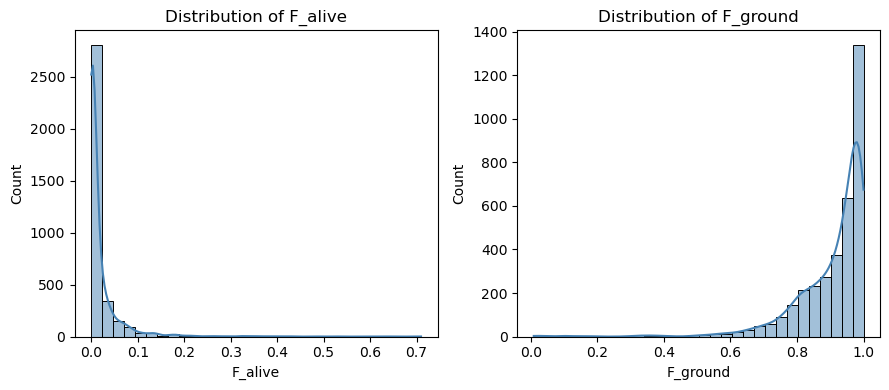

Plot saved to plots/Houbara_Count_Standardized_Morocco_2016-23__histograms_by_habitat.png


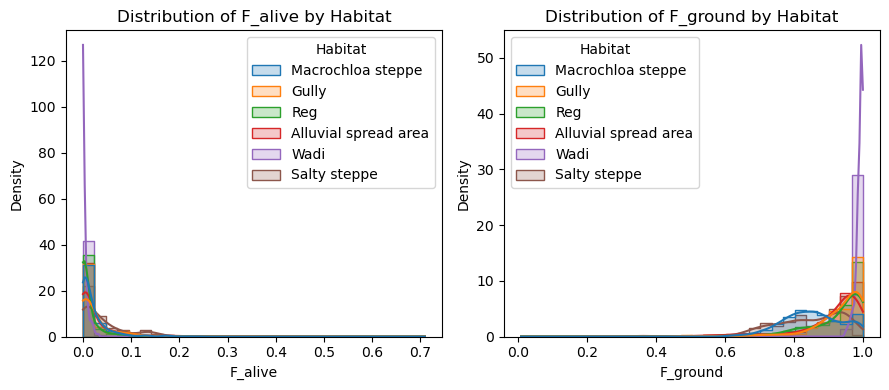

In [204]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load Field Data ---
field_files = [
    'Trophic survey data analysis_all_2016-2023_habitat.csv',  # Vegetation plots
    'Houbara_Count_Standardized_Morocco_2016-23.csv'           # Bustard occurrence
]
save_dir = 'plots'

file_to_plot = field_files[0]
# Load CSV
df = pd.read_csv(file_to_plot)

# Pick columns of interest
cols_to_plot = ["F_alive", "F_ground"]

# --- 1. Simple histograms (optional) ---
plt.figure(figsize=(9,4))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(1, 2, i)
    sns.histplot(df[col], bins=30, kde=True, color="steelblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
plt.tight_layout()
# Save figure
save_path = f"{save_dir}/{dataset_name}__histograms.png"
plt.savefig(save_path, dpi=300)
print(f"Plot saved to {save_path}")
plt.show()

# --- 2. Histograms separated by Habitat ---
plt.figure(figsize=(9,4))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(1, 2, i)
    sns.histplot(data=df, x=col, hue="Habitat", bins=30, kde=True, 
                 element="step", stat="density", common_norm=False)
    plt.title(f"Distribution of {col} by Habitat")
    plt.xlabel(col)
    plt.ylabel("Density")
plt.tight_layout()
# Save figure
save_path = f"{save_dir}/{dataset_name}__histograms_by_habitat.png"
plt.savefig(save_path, dpi=300)
print(f"Plot saved to {save_path}")
plt.show()

# # --- 3. Histograms by Habitat & Season using FacetGrid ---
# for col in cols_to_plot:
#     g = sns.FacetGrid(df, col="Season", hue="Habitat", col_wrap=2, 
#                       sharex=True, sharey=True, height=4)
#     g.map_dataframe(sns.histplot, x=col, bins=30, stat="density", 
#                     common_norm=False, element="step", kde=True)
#     g.add_legend()
#     g.set_axis_labels(col, "Density")
#     g.fig.suptitle(f"Distribution of {col} by Habitat & Season", y=1.05)
#     plt.show()



In [252]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

def plot_veg_seasonal(df: pd.DataFrame, output_dir="plots", save_fig=True):
    """
    Seasonal trends of F_alive by habitat.
    Each point = mean F_alive per season per habitat per year (aggregated across stations).
    Smoothed line shows trend across years.
    """

    # --- Preprocess ---
    df = df.copy()
    df['F_alive'] = pd.to_numeric(df['F_alive'], errors='coerce')
    df = df.dropna(subset=['F_alive', 'Season', 'Habitat', 'Year'])

    # Order seasons
    season_order = ['Winter', 'Spring', 'Summer', 'Fall']
    df['Season'] = pd.Categorical(df['Season'], categories=season_order, ordered=True)

    # Aggregate per year-season-habitat
    df_agg = df.groupby(['Year', 'Season', 'Habitat'], as_index=False)['F_alive'].mean()

    # Summary
    print(f" Aggregated data summary:")
    print(f"  Habitats: {df_agg['Habitat'].nunique()}")
    print(f"  Years: {df_agg['Year'].nunique()}")
    print(f"  Seasons: {df_agg['Season'].nunique()}")
    print(f"  Total records: {len(df_agg)}")

    # Create output directory
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    # --- Plot ---
    plt.figure(figsize=(7, 4))
    ax = plt.gca()

    # Strip plot of yearly-season points
    sns.stripplot(
        data=df_agg,
        x='Season', y='F_alive', hue='Habitat',
        dodge=True, size=3, jitter=0.15, alpha=0.7
    )

    # Smoothed trend lines with error bands
    sns.lineplot(
        data=df_agg,
        x='Season', y='F_alive', hue='Habitat',
        estimator='mean', errorbar='se',
        linewidth=2, marker='o', markersize=5,
        err_style='band', err_kws={'alpha':0.2},
        legend='brief'
    )

    # Aesthetics
    ax.set_title("Seasonal Trend of F_alive by Habitat", fontsize=14, pad=15)
    ax.set_xlabel("Season", fontsize=12)
    ax.set_ylabel("F_alive", fontsize=12)
    ax.set_ylim(0, df_agg['F_alive'].max()*1.05)
    ax.grid(alpha=0.3, linestyle='--')

    # Simplify legend
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), title="Habitat", bbox_to_anchor=(1.05,1), loc='upper left')

    plt.tight_layout()

    # Save figure
    if save_fig:
        filename = output_dir / "F_alive_seasonal_smoothed.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f" Saved journal-ready plot: {filename}")

    plt.show()


In [247]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

def plot_veg_seasonal_by_habitat(df: pd.DataFrame, output_dir="plots", save_fig=True):
    """
    Journal-ready seasonal trends of F_alive, separated by habitat.
    Each point = mean F_alive per season per year (aggregated across stations).
    Smoothed line shows trend across years.
    """

    # --- Preprocess ---
    df = df.copy()
    df['F_alive'] = pd.to_numeric(df['F_alive'], errors='coerce')
    df = df.dropna(subset=['F_alive', 'Season', 'Habitat', 'Year'])

    # Order seasons
    season_order = ['Winter', 'Spring', 'Summer', 'Fall']
    # season_order = ['Spring', 'Summer', 'Fall', 'Winter']
    df['Season'] = pd.Categorical(df['Season'], categories=season_order, ordered=True)

    # Aggregate per year-season-habitat
    df_agg = df.groupby(['Year', 'Season', 'Habitat'], as_index=False)['F_alive'].mean()

    # Summary
    print(f" Aggregated data summary:")
    print(f"  Habitats: {df_agg['Habitat'].nunique()}")
    print(f"  Years: {df_agg['Year'].nunique()}")
    print(f"  Seasons: {df_agg['Season'].nunique()}")
    print(f"  Total aggregated records: {len(df_agg)}")

    # Create output directory
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    # Plot per habitat
    habitats = df_agg['Habitat'].unique()
    for habitat in habitats:
        df_hab = df_agg[df_agg['Habitat'] == habitat]

        plt.figure(figsize=(6, 3))
        ax = plt.gca()

        # Yearly-season points
        sns.stripplot(
            data=df_hab,
            x='Season', y='F_alive',
            size=2, jitter=0.15, alpha=0.7, color='gray'
        )

        # Smoothed seasonal trend
        sns.lineplot(
            data=df_hab,
            x='Season', y='F_alive',
            estimator='mean', errorbar='se',
            linewidth=2, marker='o', markersize=4,
            err_style='band', err_kws={'alpha':0.2},
            color='steelblue'
        )

        # Aesthetics
        ax.set_title(f"Seasonal Trend of F_alive — {habitat}", fontsize=12, pad=10)
        ax.set_xlabel("Season", fontsize=11)
        ax.set_ylabel("F_alive", fontsize=11)
        # ax.set_ylim(0, df_hab['F_alive'].max() * 1.05)
        ax.set_ylim(0, 0.2)
        ax.grid(alpha=0.3, linestyle='--')

        plt.tight_layout()

        # Save figure
        if save_fig:
            filename = output_dir / f"F_alive_seasonal_{habitat.replace(' ','_')}.png"
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f" Saved plot for habitat: {habitat}")

        plt.show()
        plt.close()


In [ ]:
df = pd.read_csv(field_files[0])

 Aggregated data summary:
  Habitats: 6
  Years: 8
  Seasons: 4
  Total records: 192
 Saved journal-ready plot: plots\F_alive_seasonal_smoothed.png


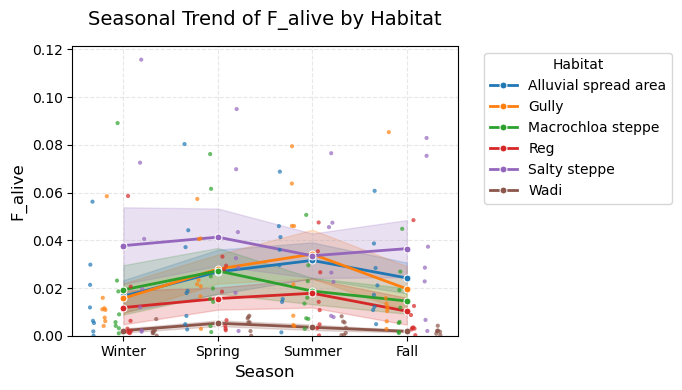

In [253]:
plot_veg_seasonal(df)

 Aggregated data summary:
  Habitats: 6
  Years: 8
  Seasons: 4
  Total records: 192
 Saved journal-ready plot: plots\F_alive_seasonal_smoothed.png


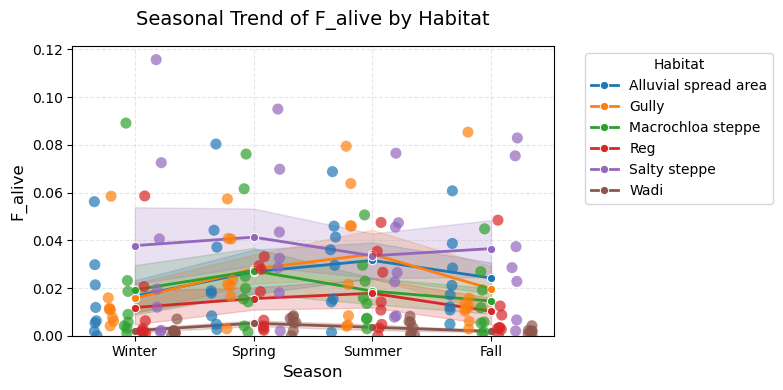

 Aggregated data summary:
  Habitats: 6
  Years: 8
  Seasons: 4
  Total aggregated records: 192
 Saved plot for habitat: Alluvial spread area


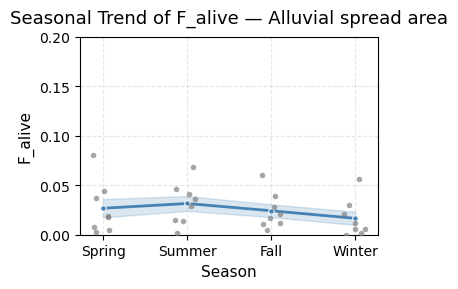

 Saved plot for habitat: Gully


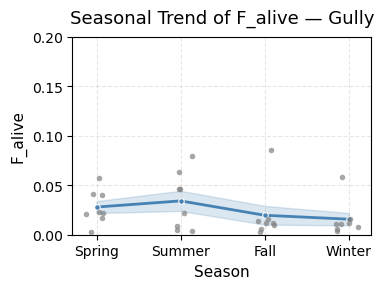

 Saved plot for habitat: Macrochloa steppe


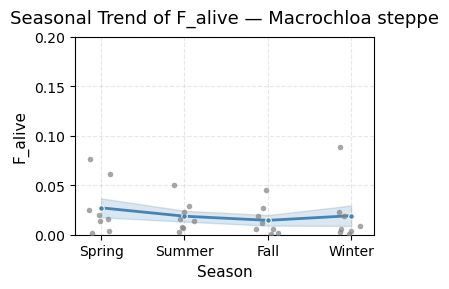

 Saved plot for habitat: Reg


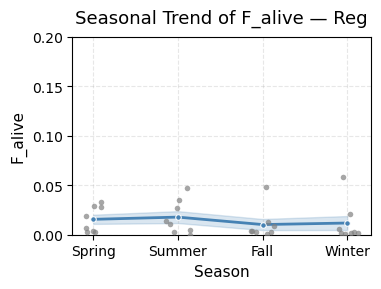

 Saved plot for habitat: Salty steppe


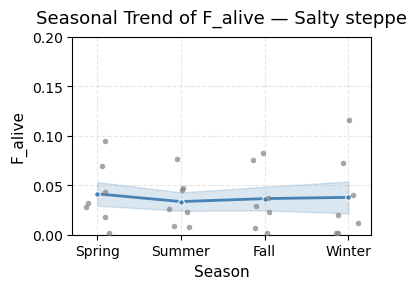

 Saved plot for habitat: Wadi


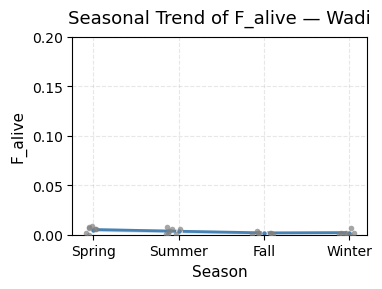

In [235]:
plot_veg_seasonal_by_habitat(df)

 Aggregated data summary:
  Habitats: 6
  Years: 8
  Seasons: 4
  Total aggregated records: 192
 Saved plot for habitat: Alluvial spread area


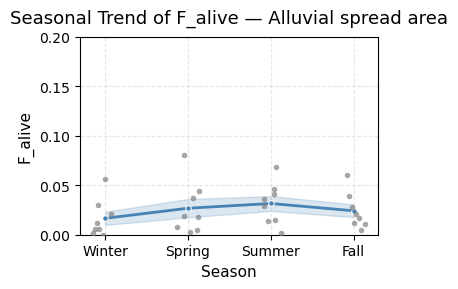

 Saved plot for habitat: Gully


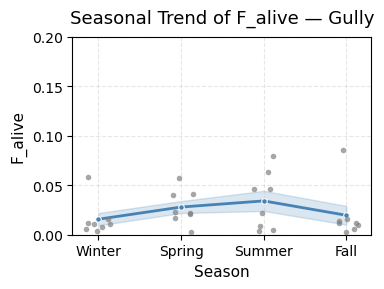

 Saved plot for habitat: Macrochloa steppe


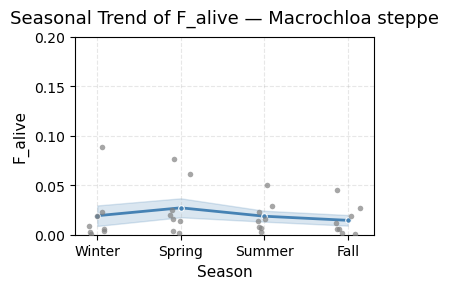

 Saved plot for habitat: Reg


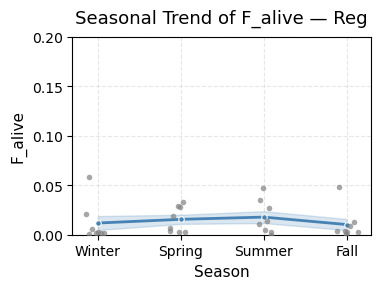

 Saved plot for habitat: Salty steppe


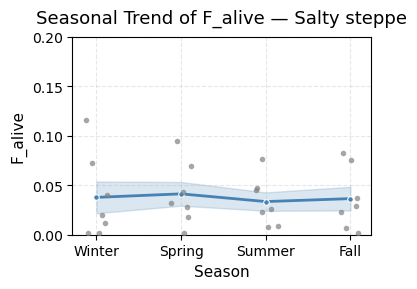

 Saved plot for habitat: Wadi


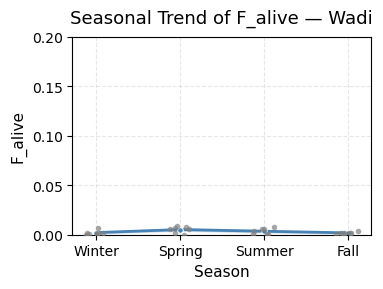

In [237]:
plot_veg_seasonal_by_habitat(df)

## 3.1 Linear Correlation Analysis

In [157]:
# --- Load Field Data ---
field_files = [
    'Trophic survey data analysis_all_2016-2023_habitat.csv',  # Vegetation plots
    'Houbara_Count_Standardized_Morocco_2016-23.csv'           # Bustard occurrence
]

veg_df = pd.read_csv(field_files[0])
occu_df = pd.read_csv(field_files[1])

print(f"Vegetation dataframe: {veg_df.shape} columns: {veg_df.columns.tolist()}")
print(f"Bustard occurrence dataframe: {occu_df.shape} columns: {occu_df.columns.tolist()}")

# --- Load Field-RS Merged files  ---
merged_files = ['Merged_Veg_Landsat.csv',
                'Merged_Veg_Sentinel2.csv',
                'Merged_Veg_Modis.csv',
                'Merged_Houbara_Landsat.csv',
                'Merged_Houbara_Sentinel2.csv',
                'Merged_Houbara_Modis.csv']

# merged_dfs = [pd.read_csv(fp) for fp in merged_files]
landsat_veg_merged = pd.read_csv(merged_files[0])
sentinel2_veg_merged = pd.read_csv(merged_files[1])
modis_veg_merged = pd.read_csv(merged_files[2])

landsat_occu_merged = pd.read_csv(merged_files[3])
sentinel2_occu_merged = pd.read_csv(merged_files[4])
modis_occu_merged = pd.read_csv(merged_files[5])

Vegetation dataframe: (3536, 16) columns: ['Station', 'Lat', 'Lon', 'Year', 'Season', 'Alive', 'Dead', 'Ground', 'Unknown', 'Sum.not.unknown', 'GridSize', 'F_alive', 'F_dead', 'F_veg', 'F_ground', 'Habitat']
Bustard occurrence dataframe: (11183, 13) columns: ['Reference_Observation_Point_Name', 'Reference_Observation_Point_Latitude', 'Reference_Observation_Point_Longitude', 'Real_Observation_Point_Name', 'Real_Observation_Point_Y', 'Real_Observation_Point_M', 'Real_Observation_Point_D', 'Real_Observation_Point_Latitude', 'Real_Observation_Point_Longitude', 'Houbara_Observation_Station_Name', 'Houbara_Observation_Station_Latitude', 'Houbara_Observation_Station_Longitude', 'Houbara_Number']


In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd

def plot_field_vs_rs_merged(merged_df: pd.DataFrame, rs_indices=None, 
                            field_col='F_veg', satellite_name='RS', save_dir='plots'):
    """
    Plot RS indices vs field measurements for a merged dataframe,
    displaying only R² in the plots.

    Parameters
    ----------
    merged_df : pd.DataFrame
        Dataframe already merged (temporal + spatial) with RS indices.
    rs_indices : list of str, optional
        List of RS indices to plot. Defaults to common indices present in merged_df.
    field_col : str
        Field measurement column to plot ('F_veg' or 'Houbara_Number').
    satellite_name : str
        Name of satellite/data source, used in titles and file names.
    save_dir : str
        Directory to save figures.
    
    Returns
    -------
    pd.DataFrame
        The merged dataframe used for plotting.
    """
    if merged_df.empty:
        print(f"No data to plot for {satellite_name}")
        return merged_df
    
    merged_df = merged_df.copy()
    
    # Default RS indices if not provided
    if rs_indices is None:
        rs_indices = [i for i in ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI'] if i in merged_df.columns]
    
    if not rs_indices:
        raise ValueError(f"No valid RS indices found in merged dataframe for {satellite_name}")
    
    # --- Compute correlations (Pearson r) ---
    corr_df = merged_df[[field_col] + rs_indices].corr()[field_col].sort_values(ascending=False)   
    print(f"\n=== {satellite_name} ===")
    print(f"Pearson correlation coefficients with {field_col}:")
    for idx, val in corr_df.items():
        print(f"{idx}: r = {val:.3f}, R² = {val**2:.3f}")
        
    # --- Plotting ---
    n_indices = len(rs_indices)
    n_cols = 3
    n_rows = math.ceil(n_indices / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()
    
    for i, ind in enumerate(rs_indices):
        ax = axes[i]
        sns.scatterplot(data=merged_df, x=ind, y=field_col, ax=ax)
        sns.regplot(data=merged_df, x=ind, y=field_col, scatter=False, color="red", ax=ax)
        r2_val = corr_df[ind] ** 2
        ax.text(0.05, 0.9, f"R² = {r2_val:.2f}", transform=ax.transAxes,
                fontsize=12, color="blue", weight="bold")
        ax.set_title(f"{ind} vs {field_col}")
        ax.set_xlabel(ind)
        ax.set_ylabel(field_col)
    
    # Remove unused axes
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle(f"{satellite_name} - RS indices vs {field_col}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save figure
    save_path = f"{save_dir}/{satellite_name}_RS_vs_{field_col}.png"
    fig.savefig(save_path, dpi=300)
    print(f"Plot saved to {save_path}")
    
    plt.show()
    return merged_df



=== Landsat ===
Pearson correlation coefficients with F_alive:
F_alive: r = 1.000, R² = 1.000
NDVI: r = 0.546, R² = 0.299
EVI: r = 0.529, R² = 0.280
SAVI: r = 0.508, R² = 0.258
MSAVI: r = 0.496, R² = 0.246
NBR: r = 0.372, R² = 0.138
NDMI: r = 0.348, R² = 0.121
NBR2: r = 0.156, R² = 0.024
MNDWI: r = -0.038, R² = 0.001
NDWI: r = -0.335, R² = 0.112
Plot saved to plots/Landsat_RS_vs_F_alive.png


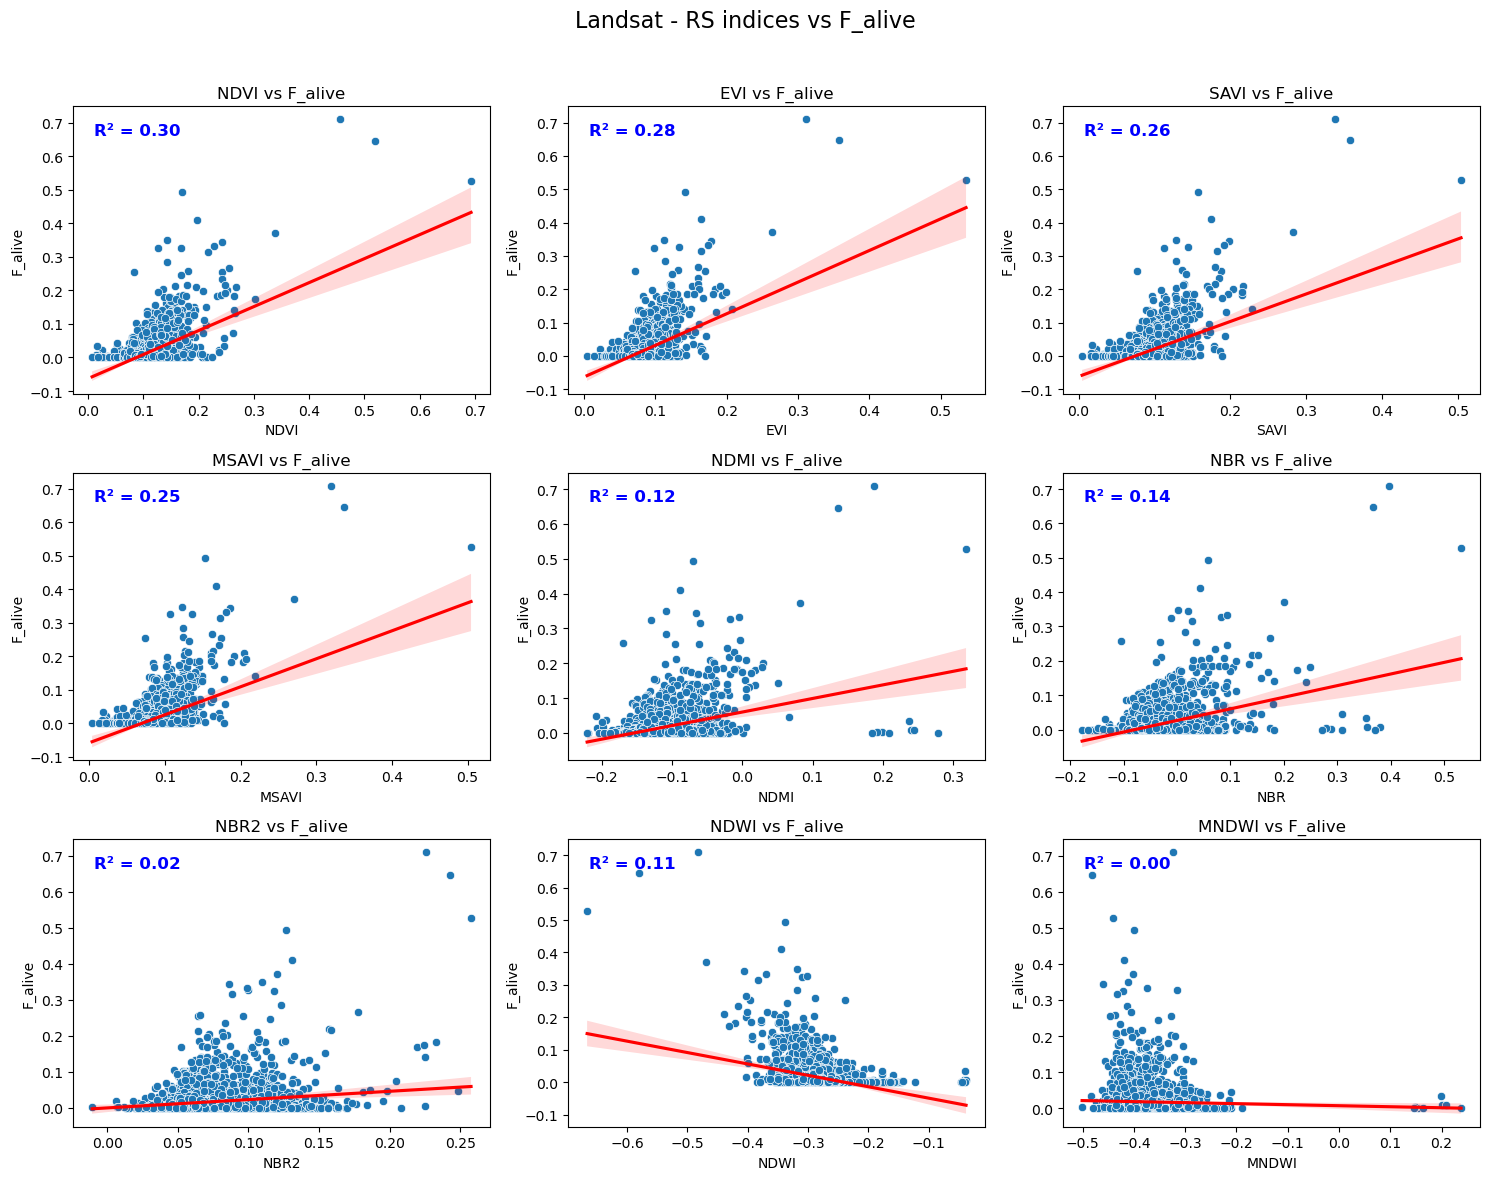


=== Sentinel-2 ===
Pearson correlation coefficients with F_alive:
F_alive: r = 1.000, R² = 1.000
SAVI: r = 0.580, R² = 0.336
NDVI: r = 0.580, R² = 0.336
MSAVI: r = 0.549, R² = 0.301
EVI: r = 0.509, R² = 0.259
NBR: r = 0.300, R² = 0.090
NDMI: r = 0.250, R² = 0.062
NBR2: r = 0.138, R² = 0.019
MNDWI: r = -0.098, R² = 0.010
NDWI: r = -0.322, R² = 0.104
Plot saved to plots/Sentinel-2_RS_vs_F_alive.png


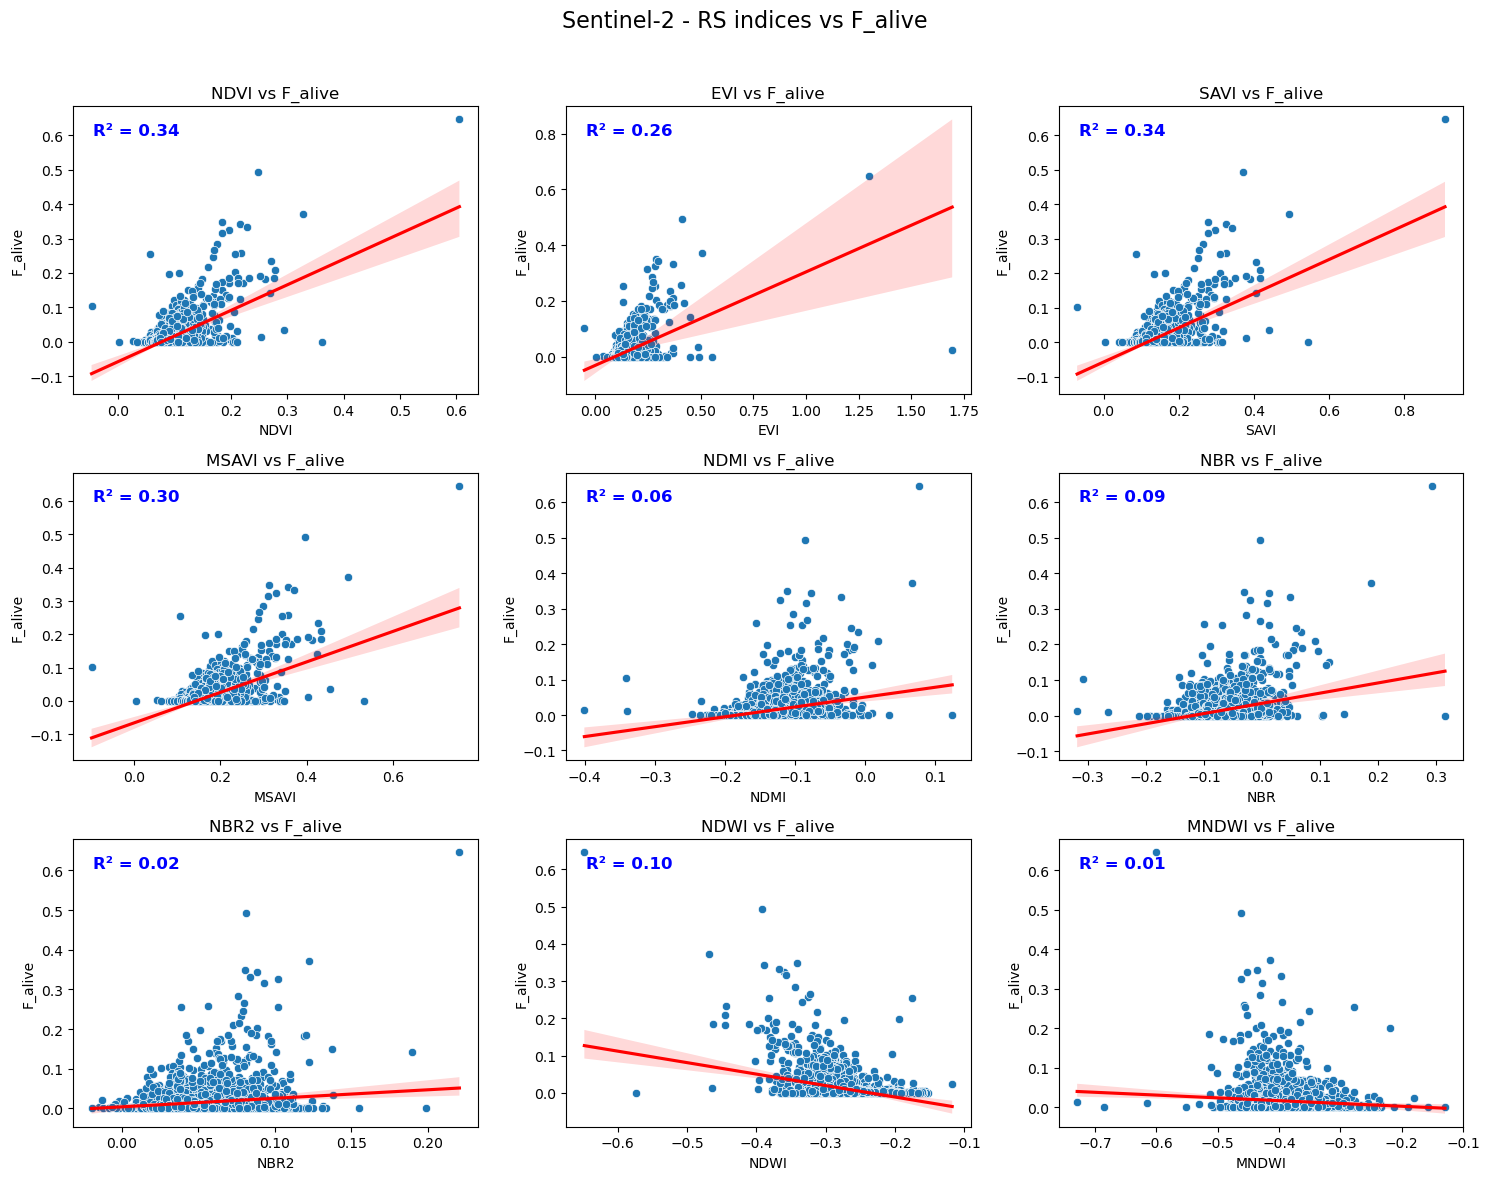


=== MODIS ===
Pearson correlation coefficients with F_alive:
F_alive: r = 1.000, R² = 1.000
EVI: r = 0.377, R² = 0.142
NDVI: r = 0.376, R² = 0.141
SAVI: r = 0.350, R² = 0.123
MSAVI: r = 0.335, R² = 0.113
NBR: r = 0.244, R² = 0.059
NBR2: r = 0.169, R² = 0.028
NDMI: r = 0.045, R² = 0.002
MNDWI: r = -0.118, R² = 0.014
NDWI: r = -0.208, R² = 0.043
Plot saved to plots/MODIS_RS_vs_F_alive.png


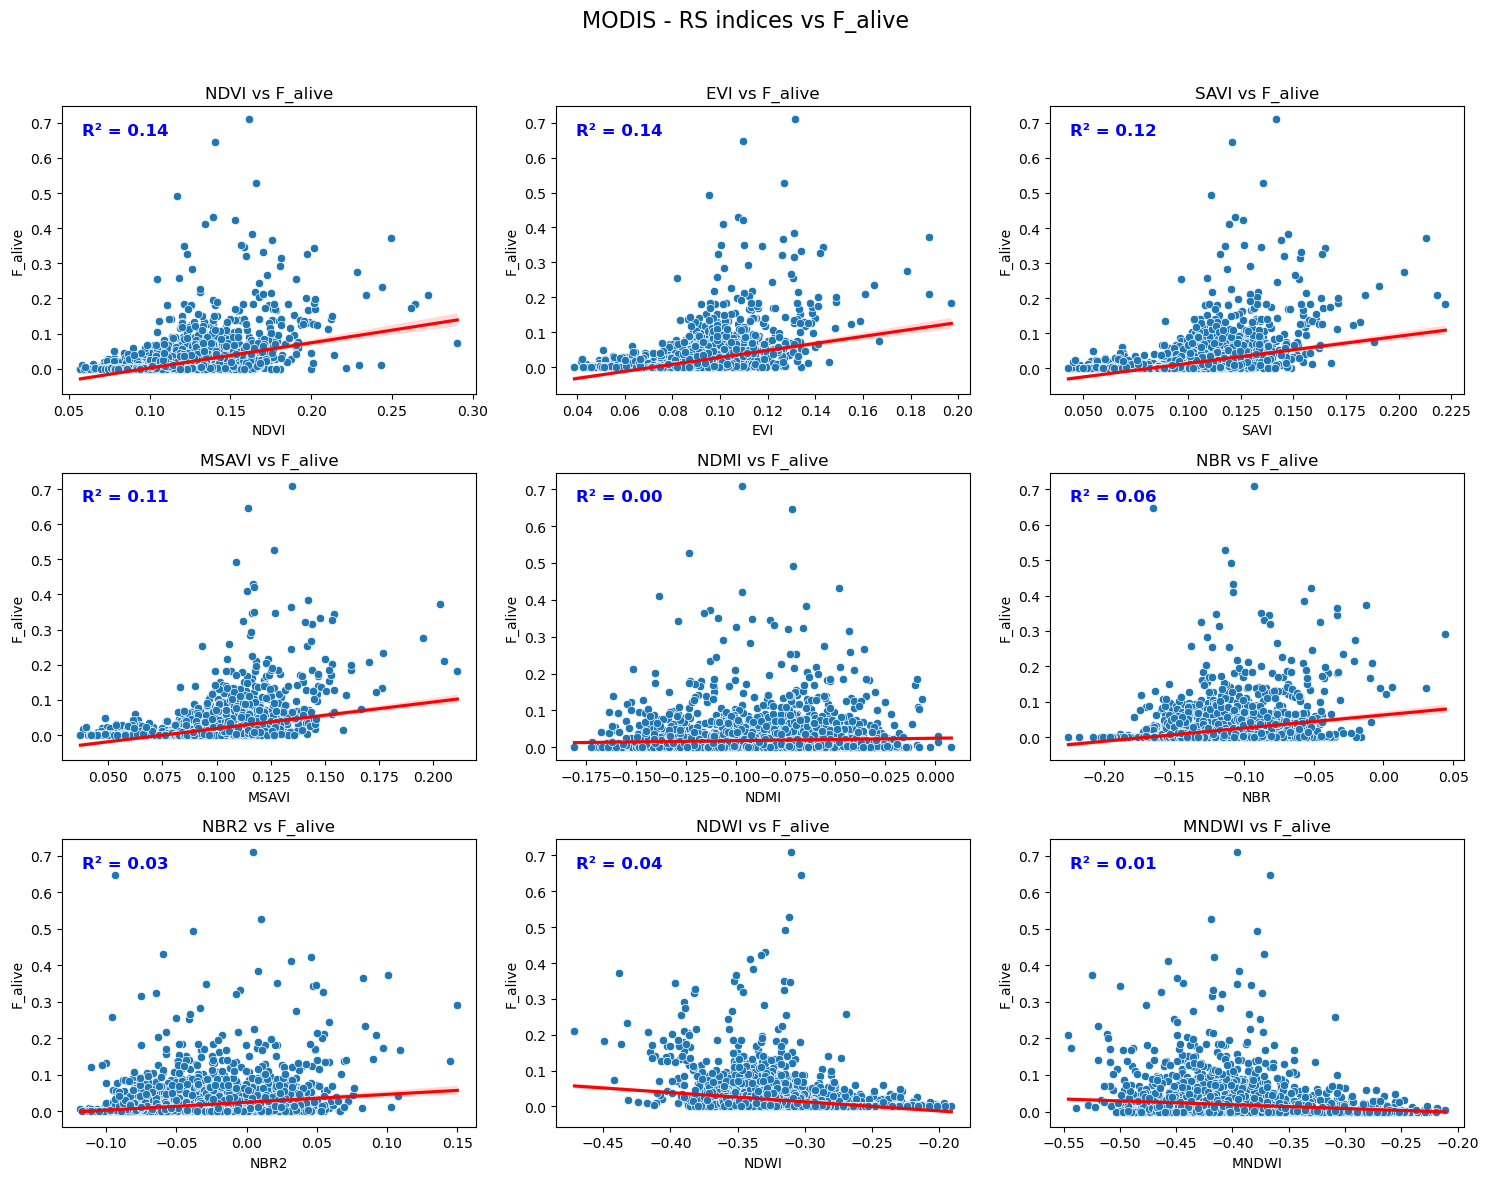

In [25]:
# Vegetation plots
landsat_veg_plot = plot_field_vs_rs_merged(landsat_veg_merged, field_col='F_alive', satellite_name='Landsat')
sentinel2_veg_plot = plot_field_vs_rs_merged(sentinel2_veg_merged, field_col='F_alive', satellite_name='Sentinel-2')
modis_veg_plot = plot_field_vs_rs_merged(modis_veg_merged, field_col='F_alive', satellite_name='MODIS')

## 3.2 Random Forest

### 3.2.1 Vegetation cover plots

In [4]:
# load the anecessery moudels
import os
print(os.getcwd())

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, roc_auc_score, accuracy_score
import seaborn as sns

# --- Load Field Data ---
field_files = [
    'Trophic survey data analysis_all_2016-2023_habitat.csv',  # Vegetation plots
    'Houbara_Count_Standardized_Morocco_2016-23.csv'           # Bustard occurrence
]

veg_df = pd.read_csv(field_files[0])
occu_df = pd.read_csv(field_files[1])

print(f"Vegetation dataframe: {veg_df.shape} columns: {veg_df.columns.tolist()}")
print(f"Bustard occurrence dataframe: {occu_df.shape} columns: {occu_df.columns.tolist()}")

# --- Load Field-RS Merged files  ---
merged_files = ['Merged_Veg_Landsat.csv',
                'Merged_Veg_Sentinel2.csv',
                'Merged_Veg_Modis.csv',
                "Merged_Veg_Combined.csv",
                'Merged_Houbara_Landsat.csv',
                'Merged_Houbara_Sentinel2.csv',
                'Merged_Houbara_Modis.csv']

# merged_dfs = [pd.read_csv(fp) for fp in merged_files]
landsat_veg_merged = pd.read_csv(merged_files[0])
sentinel2_veg_merged = pd.read_csv(merged_files[1])
modis_veg_merged = pd.read_csv(merged_files[2])
combined_veg = pd.read_csv(merged_files[3])

landsat_occu_merged = pd.read_csv(merged_files[4])
sentinel2_occu_merged = pd.read_csv(merged_files[5])
modis_occu_merged = pd.read_csv(merged_files[6])

C:\Users\PangY\Python-GIS
Vegetation dataframe: (3536, 16) columns: ['Station', 'Lat', 'Lon', 'Year', 'Season', 'Alive', 'Dead', 'Ground', 'Unknown', 'Sum.not.unknown', 'GridSize', 'F_alive', 'F_dead', 'F_veg', 'F_ground', 'Habitat']
Bustard occurrence dataframe: (11183, 13) columns: ['Reference_Observation_Point_Name', 'Reference_Observation_Point_Latitude', 'Reference_Observation_Point_Longitude', 'Real_Observation_Point_Name', 'Real_Observation_Point_Y', 'Real_Observation_Point_M', 'Real_Observation_Point_D', 'Real_Observation_Point_Latitude', 'Real_Observation_Point_Longitude', 'Houbara_Observation_Station_Name', 'Houbara_Observation_Station_Latitude', 'Houbara_Observation_Station_Longitude', 'Houbara_Number']


In [3]:
print(combined_veg.columns)

Index(['Station', 'Lat', 'Lon', 'Year', 'Season', 'F_alive', 'F_dead', 'F_veg',
       'F_ground', 'Habitat', 'date_pseudo', 'Satellite', 'Index', 'Value'],
      dtype='object')


In [139]:
print(landsat_veg_merged.columns)
print(landsat_occu_merged.columns)

Index(['Station', 'Lat', 'Lon', 'Year', 'Season', 'Alive', 'Dead', 'Ground',
       'Unknown', 'Sum.not.unknown', 'GridSize', 'F_alive', 'F_dead', 'F_veg',
       'F_ground', 'Habitat', 'date_pseudo', 'NDVI', 'EVI', 'SAVI', 'MSAVI',
       'NDMI', 'NBR', 'NBR2', 'NDWI', 'MNDWI'],
      dtype='object')
Index(['Reference_Observation_Point_Name',
       'Reference_Observation_Point_Latitude',
       'Reference_Observation_Point_Longitude', 'Real_Observation_Point_Name',
       'Real_Observation_Point_Y', 'Real_Observation_Point_M',
       'Real_Observation_Point_D', 'Real_Observation_Point_Latitude',
       'Real_Observation_Point_Longitude', 'Houbara_Observation_Station_Name',
       'Houbara_Observation_Station_Latitude',
       'Houbara_Observation_Station_Longitude', 'Houbara_Number', 'date_real',
       'NDVI', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'NBR', 'NBR2', 'NDWI', 'MNDWI',
       'RS_date'],
      dtype='object')


In [ ]:
# Regression: Fractional vegetation cover
rf_results = rf_model(landsat_veg_merged, field_col='F_alive', satellite_name='Landsat', 
                      task='regression', habitat_col='Habitat')

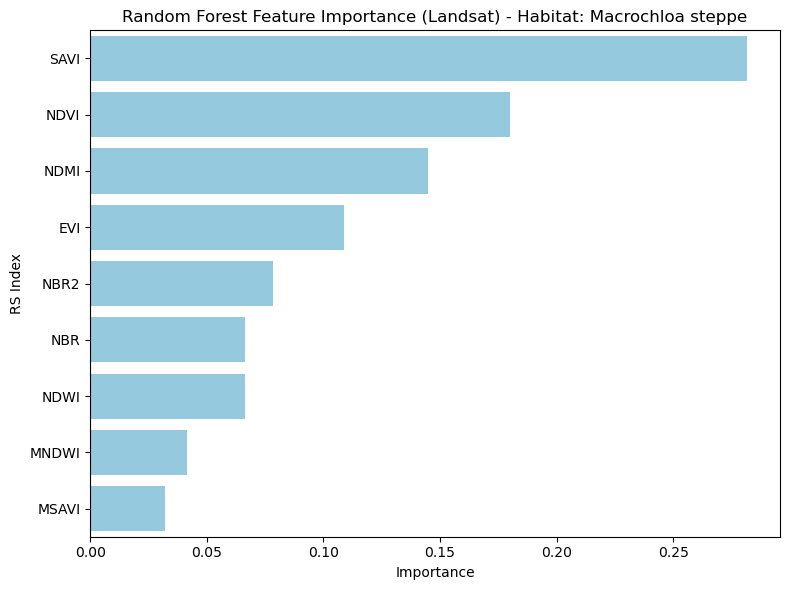


--- Landsat | Habitat: Macrochloa steppe ---
R2_train: 0.934
R2_test: 0.560
RMSE_train: 0.009
RMSE_test: 0.016


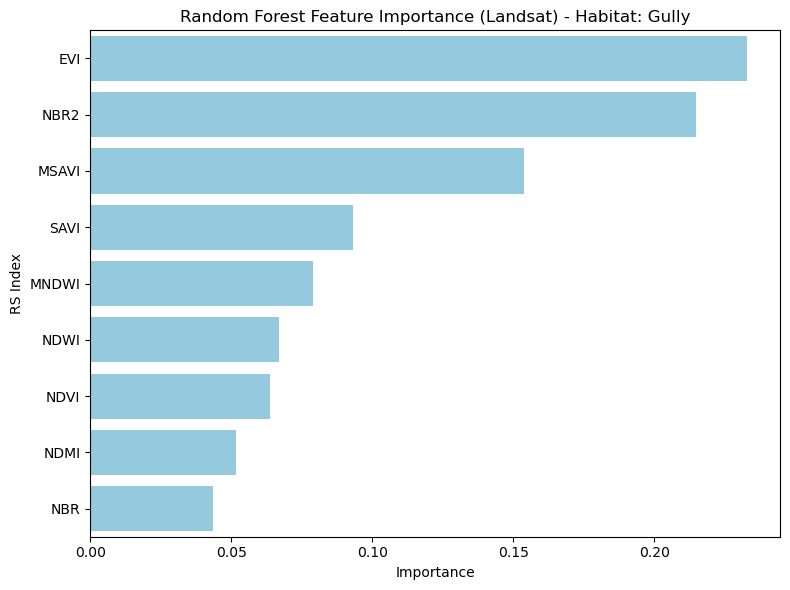


--- Landsat | Habitat: Gully ---
R2_train: 0.895
R2_test: 0.333
RMSE_train: 0.017
RMSE_test: 0.057


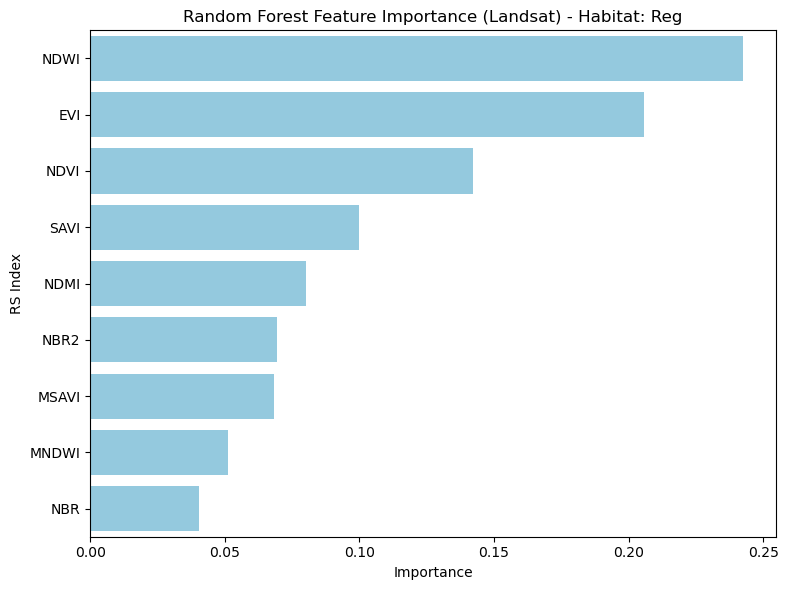


--- Landsat | Habitat: Reg ---
R2_train: 0.941
R2_test: 0.676
RMSE_train: 0.009
RMSE_test: 0.029


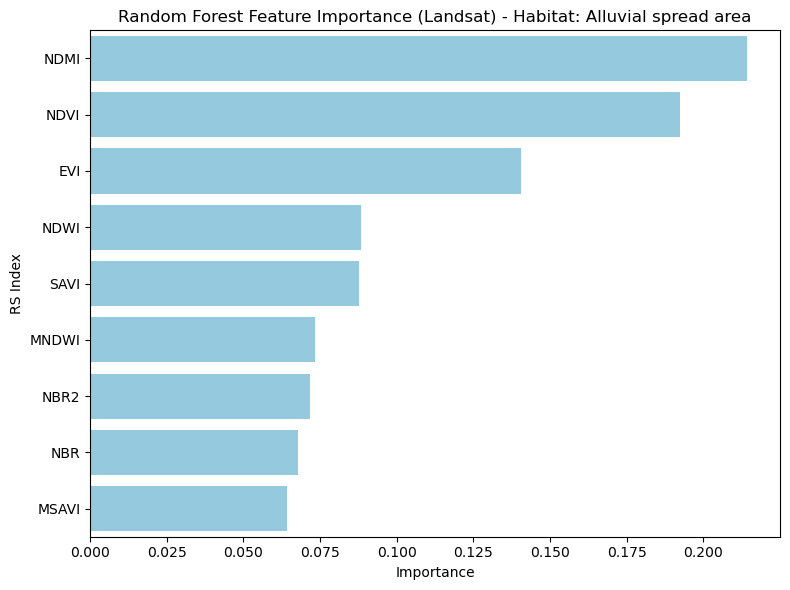


--- Landsat | Habitat: Alluvial spread area ---
R2_train: 0.907
R2_test: 0.399
RMSE_train: 0.012
RMSE_test: 0.031


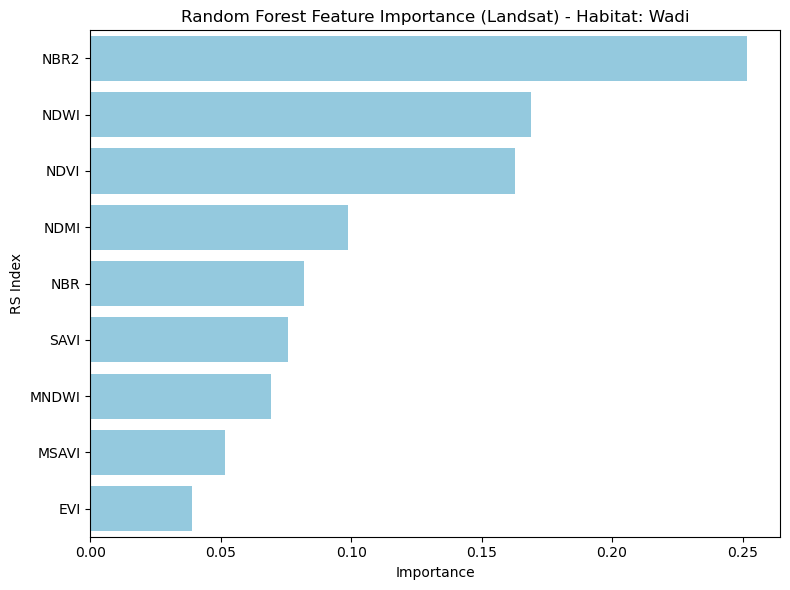


--- Landsat | Habitat: Wadi ---
R2_train: 0.860
R2_test: -0.000
RMSE_train: 0.002
RMSE_test: 0.005


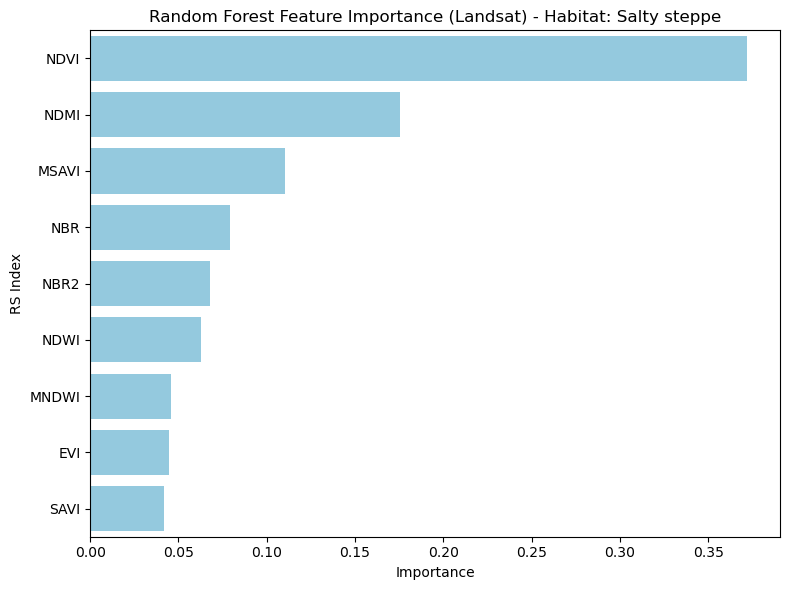


--- Landsat | Habitat: Salty steppe ---
R2_train: 0.912
R2_test: 0.344
RMSE_train: 0.013
RMSE_test: 0.034


In [96]:
# Regression: Fractional vegetation cover
rf_results = rf_model(landsat_veg_merged, field_col='F_alive', satellite_name='Landsat', 
                      task='regression', habitat_col='Habitat')

In [169]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, make_scorer
from sklearn.model_selection import cross_val_score, KFold
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np

def rf_vegetation_analysis(df, target_col='F_alive',habitat_col=None,
                           satellite_name='RS',save_dir='plots',by_habitat=False,
                           n_estimators=500,random_state=42,n_splits=5):
    """
    Compute and plot Random Forest feature importance for vegetation indices.
    Optionally compute habitat-specific importance if habitat_col is provided.
    Automatically detects regression or classification model based on target variable type.
    Includes 5-fold cross-validation for more reliable model performance estimates.
    """

    if df.empty:
        print("Input dataframe is empty.")
        return None

    df = df.copy()
    os.makedirs(save_dir, exist_ok=True)

    # Select vegetation index columns
    feature_cols = [c for c in df.columns if c.upper() in
                    ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']]
    if not feature_cols:
        raise ValueError("No valid vegetation index columns found in dataframe.")

    df = df.dropna(subset=[target_col])
    X = df[feature_cols]
    y = df[target_col]

    # Detect model type automatically
    if y.nunique() <= 10 and y.dtype in ['object', 'category', 'bool', 'int']:
        model_type = 'classification'
        model = RandomForestClassifier(n_estimators=n_estimators,
                                       random_state=random_state, n_jobs=-1)
        scoring = 'accuracy'
    else:
        model_type = 'regression'
        model = RandomForestRegressor(n_estimators=n_estimators,
                                      random_state=random_state, n_jobs=-1)
        scoring = make_scorer(r2_score)

    # =====================
    # Model fitting & score
    # =====================
    model.fit(X, y)
    y_pred = model.predict(X)

    if model_type == 'regression':
        train_score = r2_score(y, y_pred)
    else:
        train_score = accuracy_score(y, y_pred)

    # 5-fold CV
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring=scoring, n_jobs=-1)
    mean_cv_score = np.mean(cv_scores)

    # Print model summary
    print(f"\n {satellite_name} Random Forest ({model_type.capitalize()}) Results:")
    if model_type == 'regression':
        print(f"  - Training R²: {train_score:.3f}")
        print(f"  - Mean 5-fold CV R²: {mean_cv_score:.3f}")
    else:
        print(f"  - Training Accuracy: {train_score:.3f}")
        print(f"  - Mean 5-fold CV Accuracy: {mean_cv_score:.3f}")

    # =====================
    # General Feature Importance
    # =====================
    importance_df = (
        pd.DataFrame({'Index': feature_cols,
                      'Importance': model.feature_importances_})
        .sort_values('Importance', ascending=False)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(x='Importance', y='Index', data=importance_df,  color='skyblue')
    plt.title(f'{satellite_name} - Feature Importance ({model_type.capitalize()})', fontsize=12)
    plt.xlabel('Importance Rate', fontsize=11)
    plt.ylabel('Remote Sensing Index', fontsize=11)
    plt.tight_layout()
    plot_path = f"{save_dir}/{satellite_name}_FeatureImportance_General.png"
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f" General feature importance plot saved to: {plot_path}")

    # ===================================
    # Habitat-specific feature importance
    # ===================================
    if by_habitat and habitat_col and habitat_col in df.columns:
        habitat_importances = []

        for habitat, subset in df.groupby(habitat_col):
            if len(subset) < n_splits * 2:
                continue

            X_h, y_h = subset[feature_cols], subset[target_col]

            if model_type == 'classification':
                rf_h = RandomForestClassifier(n_estimators=n_estimators,
                                              random_state=random_state, n_jobs=-1)
                scoring_h = 'accuracy'
            else:
                rf_h = RandomForestRegressor(n_estimators=n_estimators,
                                             random_state=random_state, n_jobs=-1)
                scoring_h = make_scorer(r2_score)

            rf_h.fit(X_h, y_h)
            y_pred_h = rf_h.predict(X_h)

            if model_type == 'regression':
                train_score_h = r2_score(y_h, y_pred_h)
            else:
                train_score_h = accuracy_score(y_h, y_pred_h)

            cv_scores_h = cross_val_score(rf_h, X_h, y_h, cv=n_splits, scoring=scoring_h)
            mean_cv_score_h = np.mean(cv_scores_h)

            imp_h = pd.DataFrame({
                'Habitat': habitat,
                'Index': feature_cols,
                'Importance': rf_h.feature_importances_,
                'Train_Score': train_score_h,
                'CV_Score': mean_cv_score_h
            })
            habitat_importances.append(imp_h)

        habitat_importance_df = pd.concat(habitat_importances, ignore_index=True)

        # Correct plot: use hue='Habitat' and proper dataframe
        plt.figure(figsize=(8, 6))
        sns.barplot(x='Importance', y='Index', hue='Habitat', data=habitat_importance_df, dodge=True)
        plt.title(f'{satellite_name} - Feature Importance by Habitat ({model_type.capitalize()})', fontsize=12)
        plt.xlabel('Importance Rate', fontsize=11)
        plt.ylabel('Remote Sensing Index', fontsize=11)
        plt.tight_layout()
        habitat_plot_path = f"{save_dir}/{satellite_name}_FeatureImportance_ByHabitat.png"
        plt.savefig(habitat_plot_path, dpi=300)
        plt.show()
        print(f" Habitat-specific feature importance plot saved to: {habitat_plot_path}")

        # return habitat_importance_df
        # ===============================
        # Save habitat importance results
        # ===============================
        csv_path = os.path.join(save_dir, f"{satellite_name}_HabitatImportance.csv")
        habitat_importance_df.to_csv(csv_path, index=False)
        print(f" Habitat-specific feature importance table saved to: {csv_path}\n")

        # Print first few rows as preview
        print(habitat_importance_df.head(10))

        return habitat_importance_df
        
    return importance_df


In [392]:
csv_path = [save_dir + '/RF_Landsat_HabitatImportance.csv',
            save_dir + '/RF_Sentinel2_HabitatImportance.csv',
            save_dir + '/RF_MODIS_HabitatImportance.csv']

rf_veg_landsat.to_csv(csv_path[0], index=False)
print(f" Habitat-specific feature importance table saved to: {csv_path[0]}\n")
rf_veg_sentinel2.to_csv(csv_path[1], index=False)
print(f" Habitat-specific feature importance table saved to: {csv_path[1]}\n")
rf_veg_modis.to_csv(csv_path[2], index=False)
print(f" Habitat-specific feature importance table saved to: {csv_path[2]}\n")

 Habitat-specific feature importance table saved to: plots/RF_Landsat_HabitatImportance.csv

 Habitat-specific feature importance table saved to: plots/RF_Sentinel2_HabitatImportance.csv

 Habitat-specific feature importance table saved to: plots/RF_MODIS_HabitatImportance.csv




 Landsat Random Forest (Regression) Results:
  - Training R²: 0.931
  - Mean 5-fold CV R²: 0.456


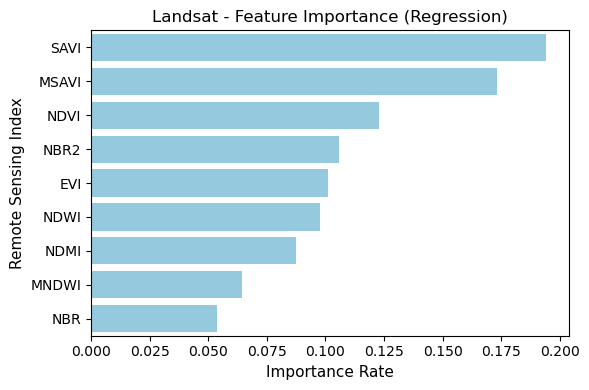

 General feature importance plot saved to: plots/Landsat_FeatureImportance_General.png


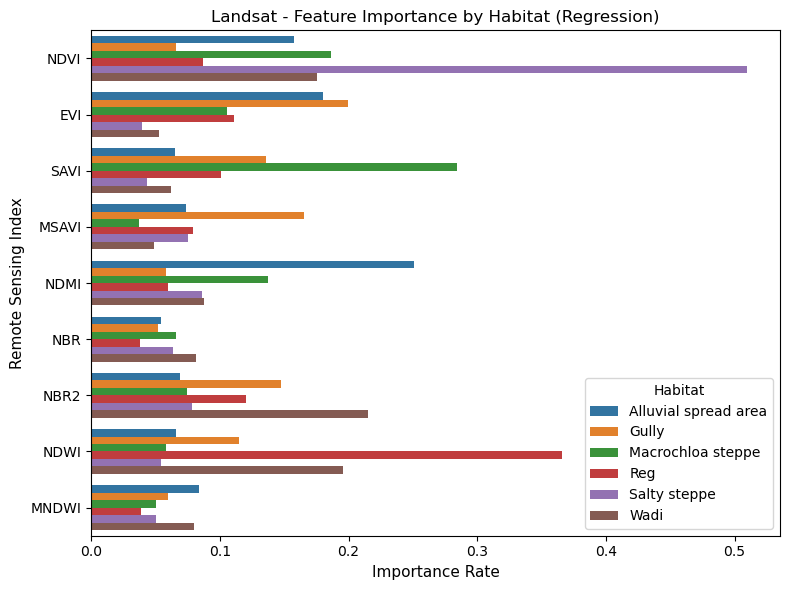

 Habitat-specific feature importance plot saved to: plots/Landsat_FeatureImportance_ByHabitat.png


In [170]:
rf_veg_landsat = rf_vegetation_analysis(landsat_veg_merged, habitat_col='Habitat', by_habitat=True, satellite_name='Landsat')


 Sentinel-2 Random Forest (Regression) Results:
  - Training R²: 0.917
  - Mean 5-fold CV R²: 0.395


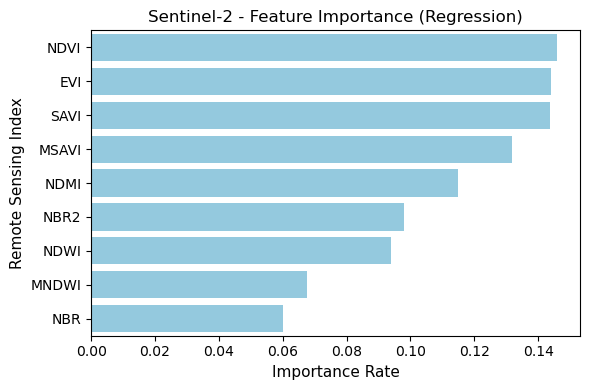

 General feature importance plot saved to: plots/Sentinel-2_FeatureImportance_General.png


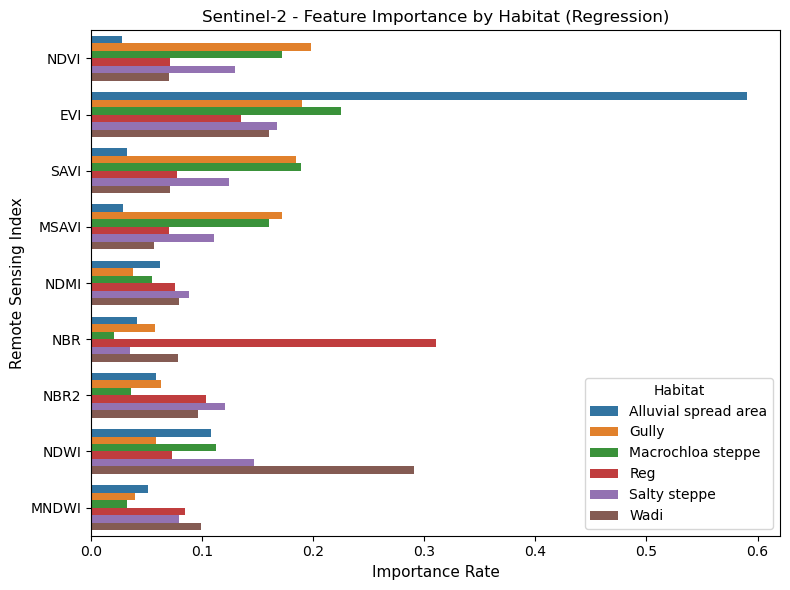

 Habitat-specific feature importance plot saved to: plots/Sentinel-2_FeatureImportance_ByHabitat.png


In [171]:
rf_veg_sentinel2 = rf_vegetation_analysis(sentinel2_veg_merged, habitat_col='Habitat', by_habitat=True, satellite_name='Sentinel-2')


 MODIS Random Forest (Regression) Results:
  - Training R²: 0.909
  - Mean 5-fold CV R²: 0.315


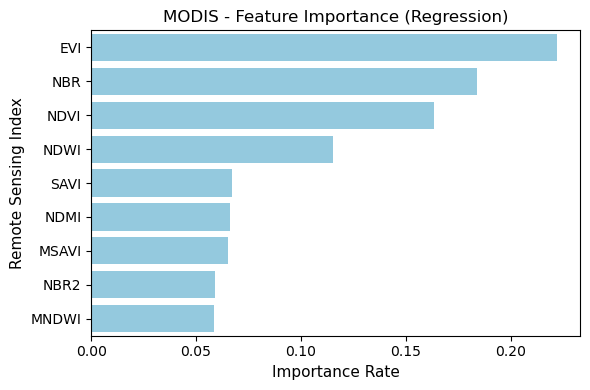

 General feature importance plot saved to: plots/MODIS_FeatureImportance_General.png


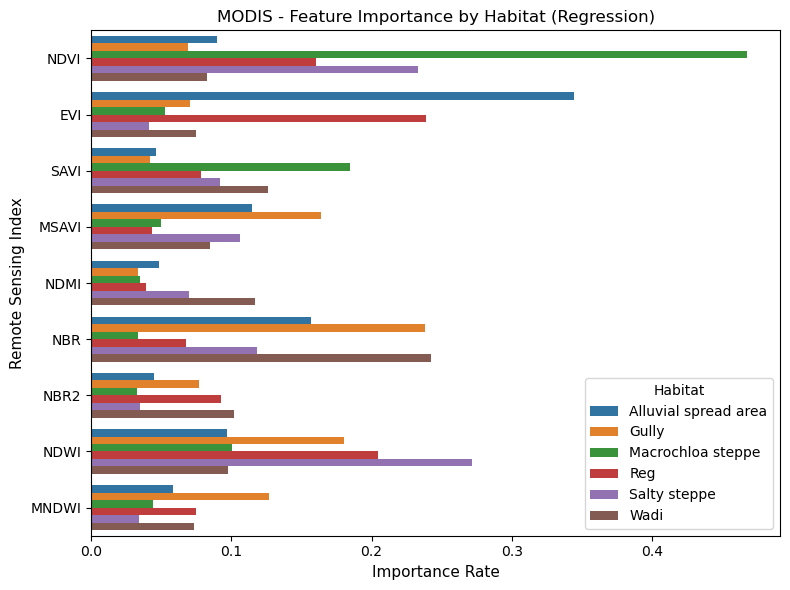

 Habitat-specific feature importance plot saved to: plots/MODIS_FeatureImportance_ByHabitat.png


In [172]:
rf_veg_modis = rf_vegetation_analysis(modis_veg_merged, habitat_col='Habitat', by_habitat=True, satellite_name='MODIS')

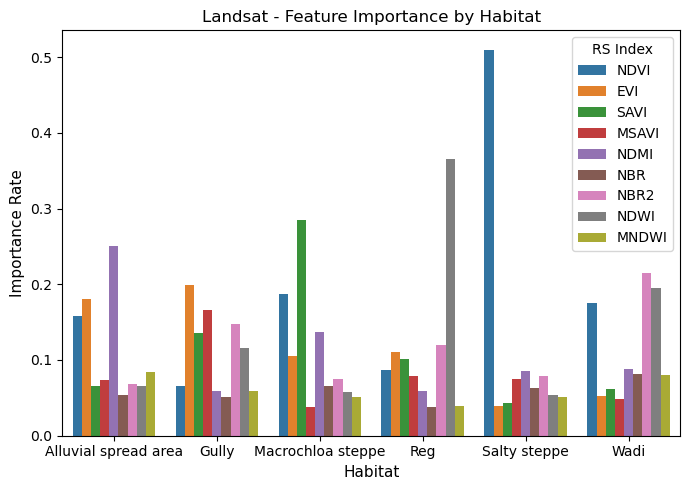

Habitat-specific feature importance plot saved to: plots\Landsat_FeatureImportance_ByHabitat.png


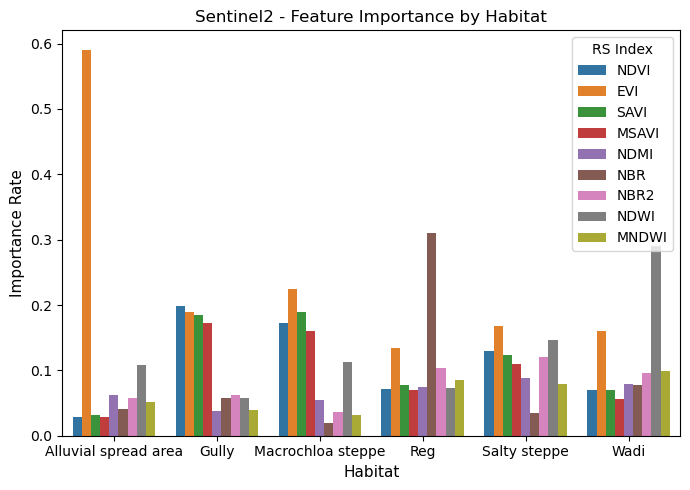

Habitat-specific feature importance plot saved to: plots\Sentinel2_FeatureImportance_ByHabitat.png


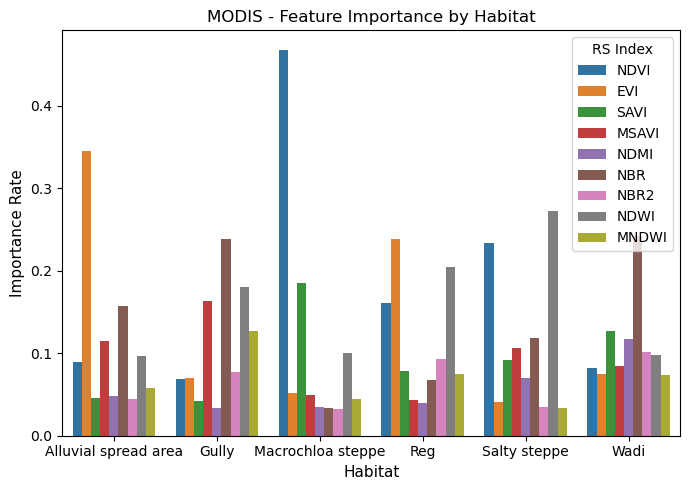

Habitat-specific feature importance plot saved to: plots\MODIS_FeatureImportance_ByHabitat.png


In [4]:
# one update(12/1/2025): Plots Importance Rate (Y-axis) vs Habitat (X-axis) with bars for each RS index
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Settings
# ----------------------------
save_dir = 'plots'
csv_paths = [
    os.path.join(save_dir, 'RF_Landsat_HabitatImportance.csv'),
    os.path.join(save_dir, 'RF_Sentinel2_HabitatImportance.csv'),
    os.path.join(save_dir, 'RF_MODIS_HabitatImportance.csv')]

# Ensure output directory exists
os.makedirs(save_dir, exist_ok=True)

# ----------------------------
# GLOBAL consistent color palette for RS indices
# ----------------------------
all_indices = [
    "NDVI", "EVI", "SAVI", "NDMI", "NDWI", "MNDWI", 
    "MSAVI", "NBR", "NBR2"
]

# Assign bright colors from a seaborn palette
index_palette = dict(zip(
    all_indices,
    sns.color_palette(len(all_indices))))

# ----------------------------
# Plot function
# ----------------------------
def plot_feature_importance_by_habitat(habitat_importance_df, satellite_name, save_dir):
    """
    Plot feature importance per habitat:
    - X-axis: Habitat
    - Y-axis: Importance Rate
    - Bars: RS indices (hue)
    """
    plt.figure(figsize=(7, 5))

    # Bar plot
    sns.barplot(
        x='Habitat',
        y='Importance',
        hue='Index',
        data=habitat_importance_df,
        dodge=True
    )

    plt.title(f'{satellite_name} - Feature Importance by Habitat', fontsize=12)
    plt.xlabel('Habitat', fontsize=11)
    plt.ylabel('Importance Rate', fontsize=11)
    # Put legend outside the plot (top-right corner)
    # plt.legend(title='RS Index', bbox_to_anchor=(1.05, 1), loc='upper left')

    # # Option A — Put legend below the figure
    # plt.legend(title='RS Index',loc='upper center',bbox_to_anchor=(0.5, -0.25),
    # ncol=3,   # put legend in 3 columns
    # frameon=False)
    
    # Option B — Put legend inside the plot (top-right corner)
    plt.legend(title='RS Index', loc='upper right')
    
    # # Option C — Put legend to the left side
    # plt.legend(title='RS Index',bbox_to_anchor=(-0.05, 1),loc='upper right')

    plt.tight_layout()
    # Save plot
    plot_path = os.path.join(save_dir, f'{satellite_name}_FeatureImportance_ByHabitat.png')
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"Habitat-specific feature importance plot saved to: {plot_path}")

# ----------------------------
# Loop over CSV files
# ----------------------------
for csv_path in csv_paths:
    if os.path.exists(csv_path):
        # Extract satellite name from filename
        satellite_name = os.path.basename(csv_path).split('_')[1]  # Landsat, Sentinel2, MODIS
        # Read CSV
        df = pd.read_csv(csv_path)
        # Plot
        plot_feature_importance_by_habitat(df, satellite_name, save_dir)
    else:
        print(f"File not found: {csv_path}")


In [35]:
# ----------------------------
# GLOBAL consistent color palette for RS indices
# ----------------------------
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import os

index_order = ["EVI", "NDVI", "SAVI", "MSAVI", "NBR", "NBR2", "NDMI", "NDWI", "MNDWI"]

# Assign bright colors from seaborn palette
index_palette = dict(zip(
    index_order,
    sns.color_palette("tab10", n_colors=len(index_order))
))

# ----------------------------
# Plot function for individual satellite
# ----------------------------
def plot_feature_importance_by_habitat(habitat_importance_df, satellite_name, save_dir):
    global index_palette,index_order

    plt.figure(figsize=(7, 5))
    sns.barplot(
        x='Habitat',
        y='Importance',
        hue='Index',
        data=habitat_importance_df,
        dodge=True,
        # palette=index_palette
        hue_order=index_order   # enforce order
    )

    plt.title(f'{satellite_name} - Feature Importance by Habitat', fontsize=12)
    plt.xlabel('Habitat', fontsize=11)
    plt.ylabel('Importance Rate', fontsize=11)
    plt.legend(title='RS Index', loc='upper right')
    plt.tight_layout()

    plot_path = os.path.join(save_dir, f'{satellite_name}_FeatureImportance_ByHabitat.png')
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"Habitat-specific feature importance plot saved to: {plot_path}")

# ----------------------------
# Summary plot combining satellites
# ----------------------------
def plot_best_index_summary(summary_csv, save_dir):
    global index_palette

    df = pd.read_csv(summary_csv)
    plt.figure(figsize=(7, 5))
    ax = plt.gca()

    satellite_order = ["Landsat", "Sentinel-2", "MODIS"]
    habitat_order = df["Habitat"].unique()
    bar_width = 0.2

    # Plot bars manually in order
    for i, hab in enumerate(habitat_order):
        df_hab = df[df["Habitat"] == hab]
        for j, sat in enumerate(satellite_order):
            df_row = df_hab[df_hab["Satellite"] == sat].iloc[0]
            x = i + (j - 1) * bar_width  # side-by-side
            ax.bar(
                x,
                df_row["Importance"],
                width=bar_width,
                color=index_palette[df_row["Index"]],
                edgecolor="black"
            )

            # Add satellite name on top of the bar for the first habitat only
            if i == 0:
                ax.text(
                    x,
                    df_row["Importance"],
                    sat,  # show satellite instead of index
                    ha='center',
                    va='bottom',
                    weight='bold',
                    fontsize=11,
                    # rotation=90
                )

    # X-axis labels (no rotation)
    ax.set_xticks(range(len(habitat_order)))
    ax.set_xticklabels(habitat_order, rotation=0, ha='center')
    ax.set_ylabel("Importance Rate", fontsize=11)
    plt.xlabel('Habitat', fontsize=11)
    ax.set_title("Best Index per Habitat Across Satellites", fontsize=12)

    # Legend for index colors only
    # index_handles = [plt.Rectangle((0,0),1,1,color=c) for c in index_palette.values()]
    index_handles = [plt.Rectangle((0,0),1,1,color=index_palette[i]) for i in index_order]
    ax.legend(index_handles, index_palette.keys(), title="RS Index", loc='upper right')

    plt.tight_layout()
    
    save_path = os.path.join(save_dir, "BestIndex_Summary_Bars.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Summary plot saved to: {save_path}")



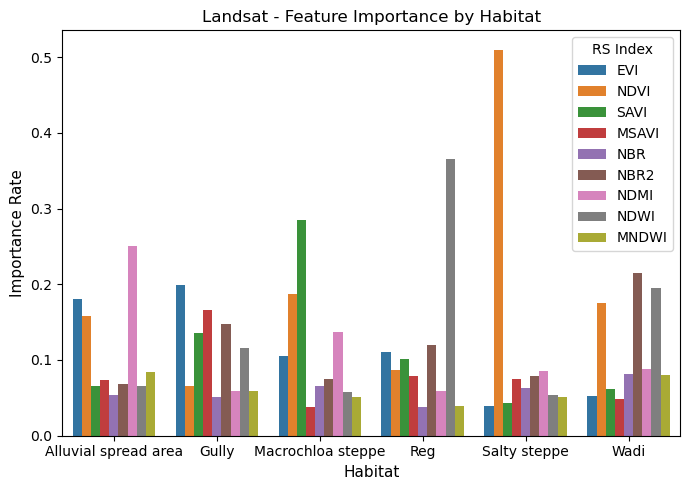

Habitat-specific feature importance plot saved to: plots\Landsat_FeatureImportance_ByHabitat.png


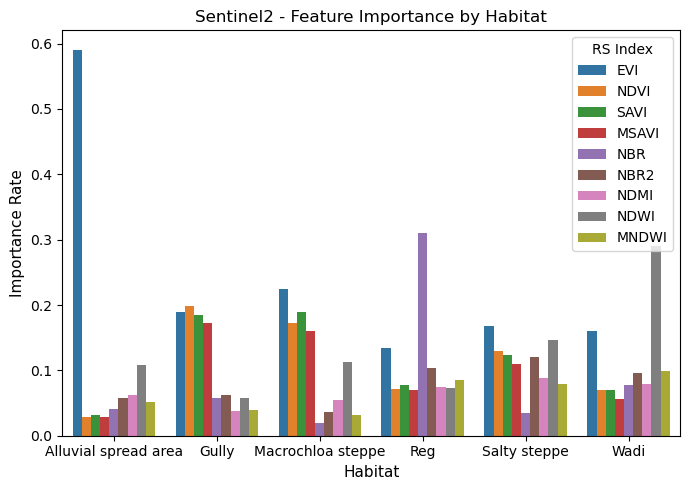

Habitat-specific feature importance plot saved to: plots\Sentinel2_FeatureImportance_ByHabitat.png


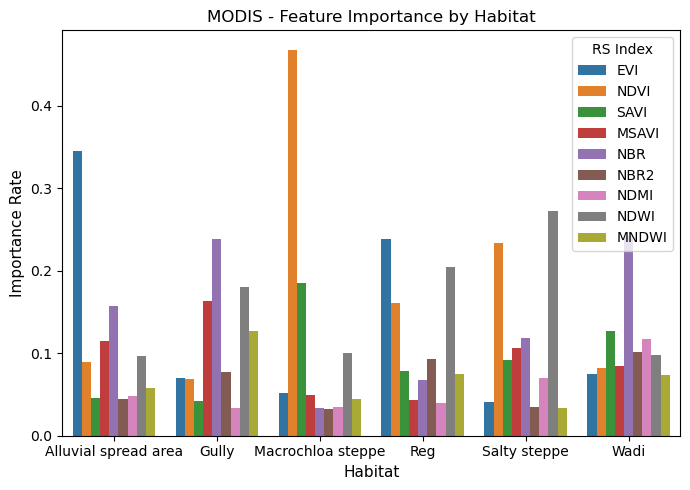

Habitat-specific feature importance plot saved to: plots\MODIS_FeatureImportance_ByHabitat.png


In [29]:
save_dir = 'plots'

# ----------------------------
# Loop over seperated Satellite CSV files
# ----------------------------
csv_paths = [
    os.path.join(save_dir, 'RF_Landsat_HabitatImportance.csv'),
    os.path.join(save_dir, 'RF_Sentinel2_HabitatImportance.csv'),
    os.path.join(save_dir, 'RF_MODIS_HabitatImportance.csv')]

for csv_path in csv_paths:
    if os.path.exists(csv_path):
        # Extract satellite name from filename
        satellite_name = os.path.basename(csv_path).split('_')[1]  # Landsat, Sentinel2, MODIS
        # Read CSV
        df = pd.read_csv(csv_path)
        # Plot
        plot_feature_importance_by_habitat(df, satellite_name, save_dir)
    else:
        print(f"File not found: {csv_path}")


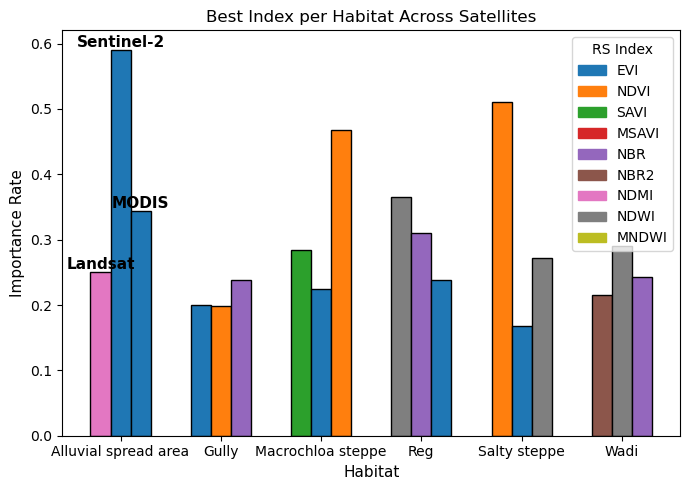

Summary plot saved to: plots\BestIndex_Summary_Bars.png


In [36]:
# ----------------------------
# Summary CSV file
# ----------------------------
summary_csv = os.path.join(save_dir, "RF_HabitatImportance.csv")
plot_best_index_summary(summary_csv, save_dir)

### disacrded

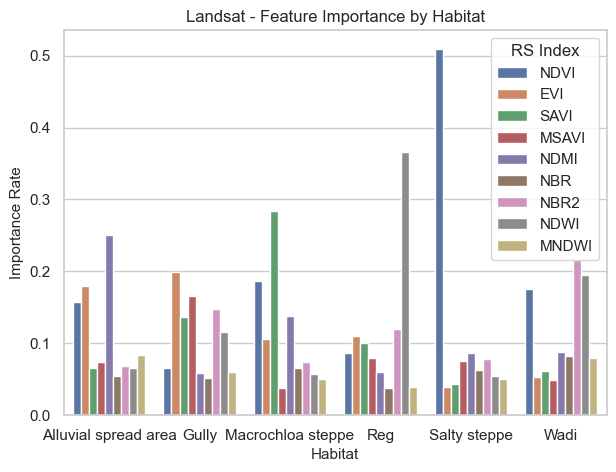

Habitat-specific feature importance plot saved to: plots\Landsat_FeatureImportance_ByHabitat.png


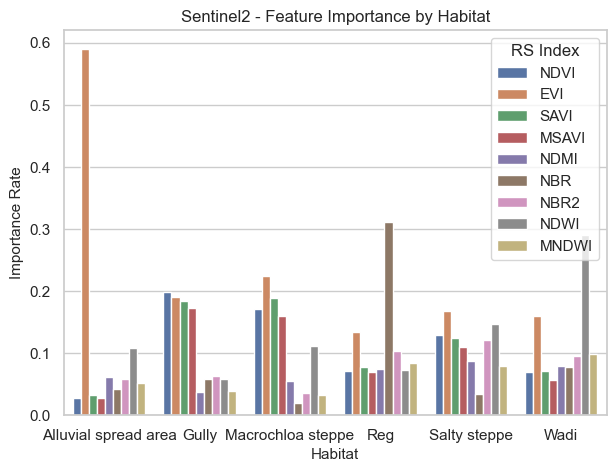

Habitat-specific feature importance plot saved to: plots\Sentinel2_FeatureImportance_ByHabitat.png


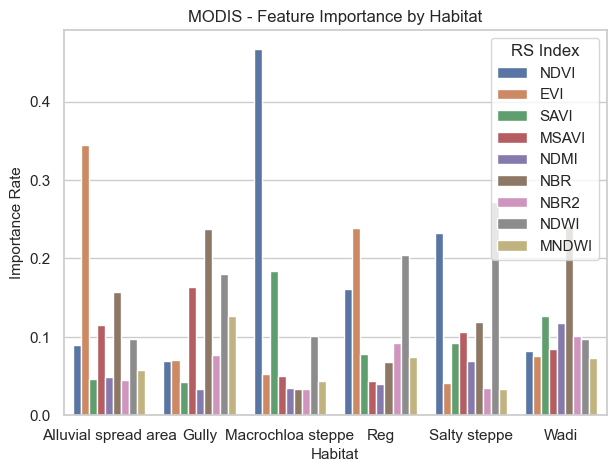

Habitat-specific feature importance plot saved to: plots\MODIS_FeatureImportance_ByHabitat.png


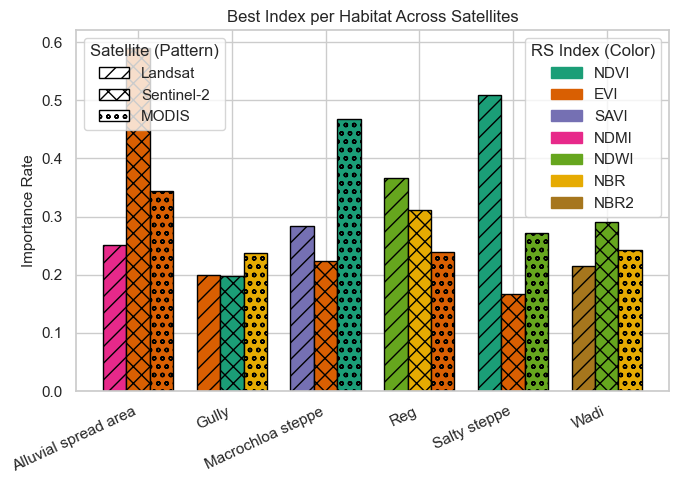

Summary plot saved to: plots\BestIndex_Summary_Hatching.png


In [137]:
# -------------------------------------------------------------------------
# Imports
# -------------------------------------------------------------------------
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Settings
# ----------------------------
save_dir = 'plots'
csv_paths = [
    os.path.join(save_dir, 'RF_Landsat_HabitatImportance.csv'),
    os.path.join(save_dir, 'RF_Sentinel2_HabitatImportance.csv'),
    os.path.join(save_dir, 'RF_MODIS_HabitatImportance.csv')
]

# Ensure output directory exists
os.makedirs(save_dir, exist_ok=True)

# ---------------------------------------------------------
# Shared color palette for RS indices
# ---------------------------------------------------------
index_palette = {
    "NDVI": "#1b9e77",
    "EVI": "#d95f02",
    "SAVI": "#7570b3",
    "NDMI": "#e7298a",
    "NDWI": "#66a61e",
    "MNDWI": "#a6761d",
    "MSAVI": "#1f78b4",
    "NBR": "#e6ab02",
    "NBR2": "#a6761d"
}

# Satellite hatching patterns
satellite_hatch = {
    "Landsat": "//",
    "Sentinel-2": "xx",
    "MODIS": "oo"
}

# ----------------------------
# Prime plot function (individual satellites)
# ----------------------------
# plot_feature_importance_by_habitat(), which was listed in previous box

# ----------------------------
# Summary plot (all satellites)
# ----------------------------
# -------------------------------------------------------------------------
# Summary plot combining satellites with separate legends
# -------------------------------------------------------------------------
def plot_best_index_summary_with_hatching(summary_csv, save_dir, index_palette, satellite_hatch):
    """
    Summary plot:
    - X-axis: Habitat
    - Bars: Importance
    - Bar color: Index (consistent palette)
    - Bar hatch: Satellite (Landsat / Sentinel-2 / MODIS)
    - Separate legend for Index (color) and Satellite (pattern)
    """
    df = pd.read_csv(summary_csv)
    plt.figure(figsize=(7, 5))  # Keep same layout as per-satellite plots
    ax = plt.gca()

    satellite_order = ["Landsat", "Sentinel-2", "MODIS"]
    habitat_order = df["Habitat"].unique()
    bar_width = 0.25

    # Plot bars manually with hatching
    for i, sat in enumerate(satellite_order):
        df_sat = df[df["Satellite"] == sat]
        shift = (i - 1) * bar_width

        for j, row in df_sat.iterrows():
            x = list(habitat_order).index(row["Habitat"]) + shift
            ax.bar(
                x,
                row["Importance"],
                width=bar_width,
                color=index_palette.get(row["Index"], "#333333"),  # fallback color
                hatch=satellite_hatch[sat],
                edgecolor="black"
            )

    # X-axis labels
    ax.set_xticks(range(len(habitat_order)))
    ax.set_xticklabels(habitat_order, rotation=25, ha='right')
    ax.set_ylabel("Importance Rate", fontsize=11)
    ax.set_title("Best Index per Habitat Across Satellites", fontsize=12)

    # Build color legend for RS Index (reusing palette)
    index_handles = [
        plt.Rectangle((0, 0), 1, 1, color=index_palette[idx])
        for idx in sorted(df["Index"].unique(), key=lambda x: list(index_palette.keys()).index(x))
    ]
    index_labels = sorted(df["Index"].unique(), key=lambda x: list(index_palette.keys()).index(x))
    legend1 = ax.legend(index_handles, index_labels, title="RS Index (Color)", loc="upper right")
    ax.add_artist(legend1)

    # Build legend for satellite (hatch patterns)
    satellite_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="white", hatch=satellite_hatch[sat], edgecolor="black")
        for sat in satellite_order
    ]
    ax.legend(satellite_handles, satellite_order, title="Satellite (Pattern)", loc="upper left")

    plt.tight_layout()
    save_path = os.path.join(save_dir, "BestIndex_Summary_Hatching.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Summary plot saved to: {save_path}")

# ----------------------------
# Loop over individual satellite CSVs
# ----------------------------
for csv_path in csv_paths:
    if os.path.exists(csv_path):
        # Extract satellite name from filename
        satellite_name = os.path.basename(csv_path).split('_')[1]  # Landsat, Sentinel2, MODIS
        # Read CSV
        df = pd.read_csv(csv_path)
        # Plot
        plot_feature_importance_by_habitat(df, satellite_name, save_dir)
    else:
        print(f"File not found: {csv_path}")
        
# ----------------------------
# Summary plot for all satellites
# ----------------------------
summary_csv = os.path.join(save_dir, "RF_HabitatImportance.csv")
if os.path.exists(summary_csv):
    plot_best_index_summary_with_hatching(summary_csv, save_dir, index_palette, satellite_hatch)
else:
    print(f"Summary CSV not found: {summary_csv}")


### 3.2.2 Bustard occurance points

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

def rf_occurrence_analysis(df, field_col, satellite_name='Satellite',
                           habitat_col=None, save_dir='plots', smote=True,
                           n_estimators=500, random_state=42, cv_folds=5):
    """
    Random Forest classification linking species occurrence with RS indices
    for a single merged DataFrame, optionally by habitat.
    Converts numeric counts in `field_col` to binary presence/absence.

    Parameters
    ----------
    df : pd.DataFrame
        Merged RS + occurrence data frame.
    field_col : str
        Column indicating species count (0 = absence, >0 = presence).
    satellite_name : str
        Name of the satellite (used for labeling figures and outputs).
    habitat_col : str, optional
        Column name for habitat type. If provided, compute habitat-specific models.
    save_dir : str
        Directory to save plots.
    smote : bool
        Whether to apply SMOTE to handle class imbalance.
    n_estimators : int
        Number of trees in Random Forest.
    random_state : int
        Random seed for reproducibility.
    cv_folds : int
        Number of folds for cross-validation ROC-AUC.

    Returns
    -------
    results_dict : dict
        Stores RF models, metrics, feature importance, and plots
        for each habitat (or overall if no habitat specified).
    """
    if df.empty or field_col not in df.columns:
        print(f"No valid data or missing field column '{field_col}', skipping...")
        return None

    os.makedirs(save_dir, exist_ok=True)
    df = df.copy()

    # Convert counts to binary presence/absence
    df['presence'] = (df[field_col] > 0).astype(int)

    # Detect RS indices in the DataFrame
    rs_indices = [c for c in df.columns if c.upper() in
                  ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']]
    if not rs_indices:
        print(f"No RS indices found in dataframe, skipping...")
        return None

    # Habitat-specific analysis
    habitats = [None]
    if habitat_col and habitat_col in df.columns:
        habitats = df[habitat_col].unique()

    results_dict = {}

    for hab in habitats:
        if hab is not None:
            df_sub = df[df[habitat_col] == hab].copy()
            print(f"\n--- Habitat: {hab} ---")
        else:
            df_sub = df.copy()

        df_sub = df_sub[rs_indices + ['presence']].dropna()
        X = df_sub[rs_indices]
        y = df_sub['presence']

        # Handle class imbalance
        if smote:
            sm = SMOTE(random_state=random_state)
            X, y = sm.fit_resample(X, y)

        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=random_state, stratify=y
        )

        # Random Forest
        rf = RandomForestClassifier(n_estimators=n_estimators,
                                    random_state=random_state, n_jobs=-1)
        rf.fit(X_train, y_train)

        # Predictions & metrics
        y_pred = rf.predict(X_test)
        y_proba = rf.predict_proba(X_test)[:,1]
        cls_report = classification_report(y_test, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_test, y_proba)
        precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
        pr_auc = auc(recall, precision)

        # 5-fold cross-validation ROC-AUC
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
        cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
        cv_mean = cv_scores.mean()

        print("Classification Report:")
        print(cls_report)
        print(f"ROC-AUC: {roc_auc:.3f}, PR-AUC: {pr_auc:.3f}, CV-ROC-AUC: {cv_mean:.3f}")

        # Feature importance
        imp_df = pd.DataFrame({'Index': rs_indices, 'Importance': rf.feature_importances_})
        imp_df = imp_df.sort_values('Importance', ascending=False)
        print("Top Feature Importances:")
        print(imp_df.head(10))

        # PR curve plot
        plt.figure(figsize=(6,5))
        plt.plot(recall, precision, label=f'PR curve (AUC={pr_auc:.2f})')
        plt.xlabel('Recall'); plt.ylabel('Precision')
        title = f'PR Curve - {satellite_name}' + (f' - {hab}' if hab else '')
        plt.title(title)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{save_dir}/{satellite_name}_PRcurve_{hab if hab else 'All'}.png", dpi=300)
        plt.show()

        # Feature importance plot
        plt.figure(figsize=(8,6))
        plt.barh(imp_df['Index'], imp_df['Importance'], color='skyblue')
        plt.gca().invert_yaxis()
        plt.xlabel("Importance")
        plt.title(f"RF Feature Importance - {satellite_name}" + (f' - {hab}' if hab else ''))
        plt.tight_layout()
        plt.savefig(f"{save_dir}/{satellite_name}_FI_{hab if hab else 'All'}.png", dpi=300)
        plt.show()

        # Suggested threshold
        optimal_idx = np.argmax(recall - (1 - precision))
        optimal_threshold = thresholds[optimal_idx]
        print(f"Suggested threshold for presence detection: {optimal_threshold:.3f}")

        results_dict[hab if hab else 'All'] = {
            'rf_model': rf,
            'metrics': {'classification_report': cls_report,
                        'roc_auc': roc_auc,
                        'pr_auc': pr_auc,
                        'cv_roc_auc': cv_mean},
            'feature_importance': imp_df,
            'precision_recall_curve': (precision, recall, thresholds),
            'optimal_threshold': optimal_threshold
        }

    return results_dict


### Updates:1/7/2025

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      2266
           1       0.81      0.87      0.84      2266

    accuracy                           0.84      4532
   macro avg       0.84      0.84      0.84      4532
weighted avg       0.84      0.84      0.84      4532

ROC-AUC: 0.915, PR-AUC: 0.914, CV-ROC-AUC: 0.928
Top Feature Importances:
   Index  Importance
7   NDWI    0.122403
6   NBR2    0.119040
3  MSAVI    0.119020
8  MNDWI    0.114448
4   NDMI    0.110835
5    NBR    0.107913
0   NDVI    0.104318
2   SAVI    0.101330
1    EVI    0.100693


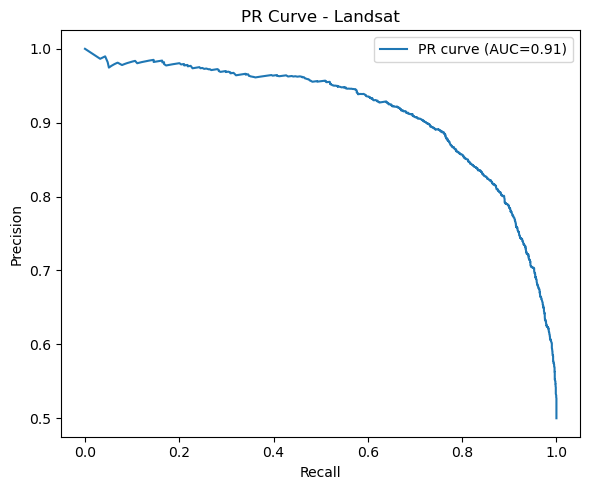

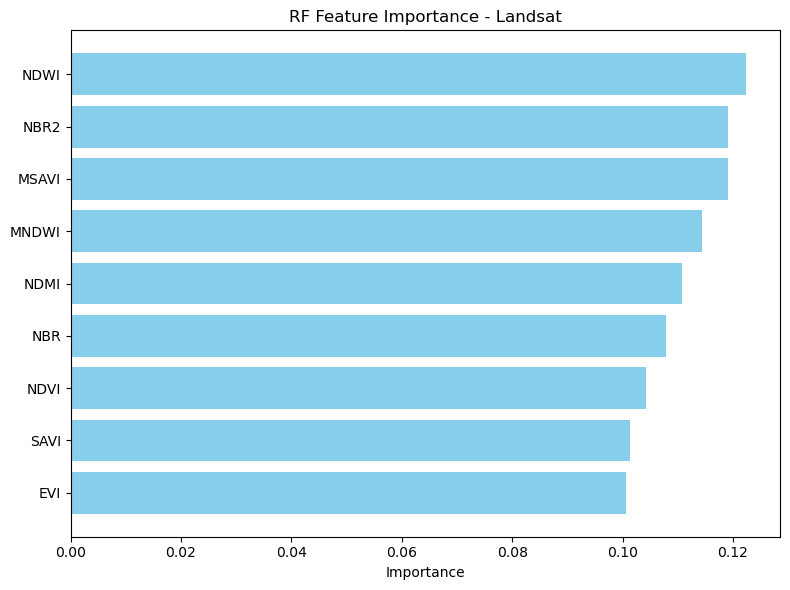

Suggested threshold for presence detection: 0.480


In [16]:
rf_occ_landsat = rf_occurrence_analysis(landsat_occu_merged1, field_col='Houbara_Number', satellite_name="Landsat")

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1589
           1       0.81      0.87      0.84      1588

    accuracy                           0.83      3177
   macro avg       0.83      0.83      0.83      3177
weighted avg       0.83      0.83      0.83      3177

ROC-AUC: 0.914, PR-AUC: 0.911, CV-ROC-AUC: 0.933
Top Feature Importances:
   Index  Importance
8  MNDWI    0.140029
6   NBR2    0.132211
7   NDWI    0.129280
5    NBR    0.122437
4   NDMI    0.122220
1    EVI    0.109162
2   SAVI    0.082097
0   NDVI    0.081591
3  MSAVI    0.080973


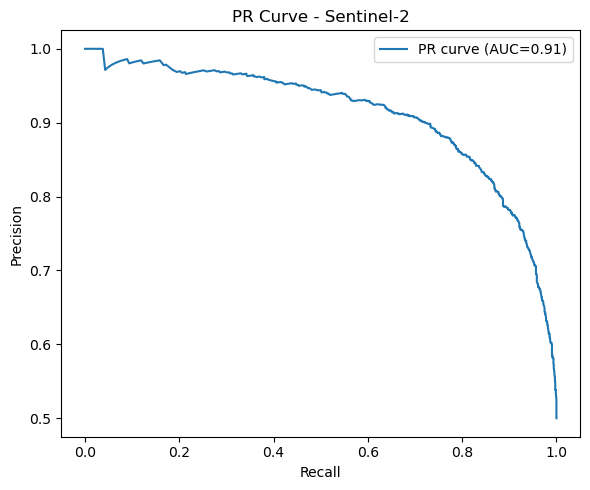

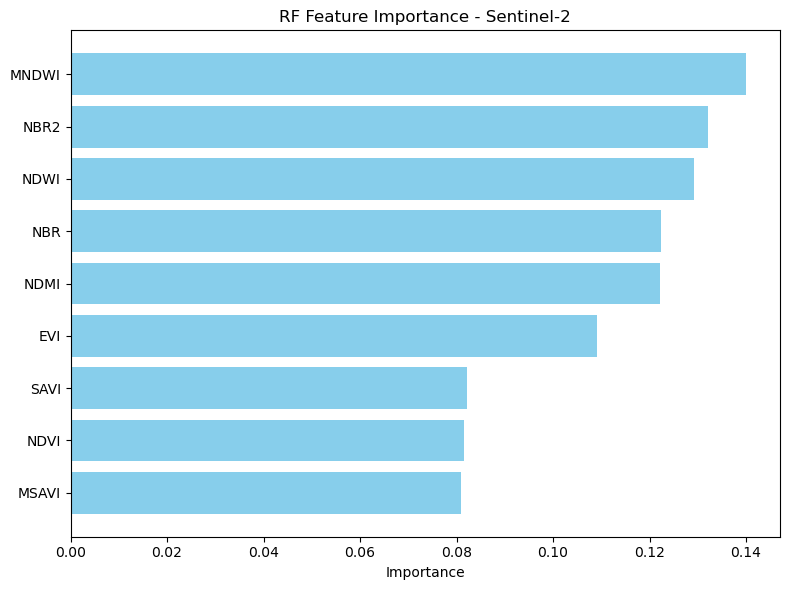

Suggested threshold for presence detection: 0.434


In [17]:
rf_occ_sentinel2 = rf_occurrence_analysis(sentinel2_occu_merged1, field_col='Houbara_Number', satellite_name="Sentinel-2")

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      2397
           1       0.81      0.89      0.85      2397

    accuracy                           0.84      4794
   macro avg       0.85      0.84      0.84      4794
weighted avg       0.85      0.84      0.84      4794

ROC-AUC: 0.924, PR-AUC: 0.923, CV-ROC-AUC: 0.934
Top Feature Importances:
   Index  Importance
3  MSAVI    0.124909
7   NDWI    0.117412
8  MNDWI    0.110999
2   SAVI    0.110537
5    NBR    0.110506
6   NBR2    0.108637
0   NDVI    0.107476
1    EVI    0.107216
4   NDMI    0.102307


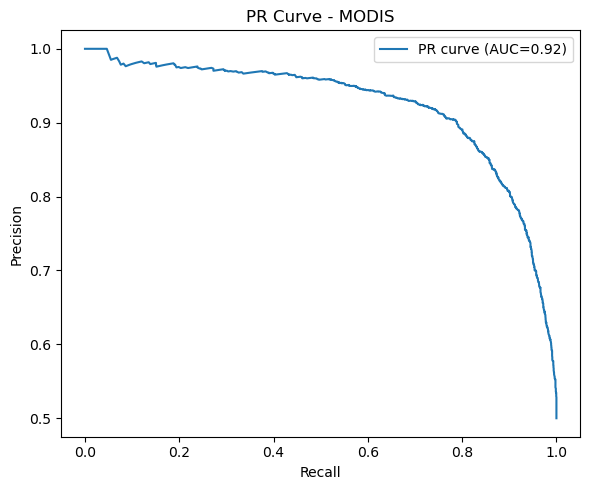

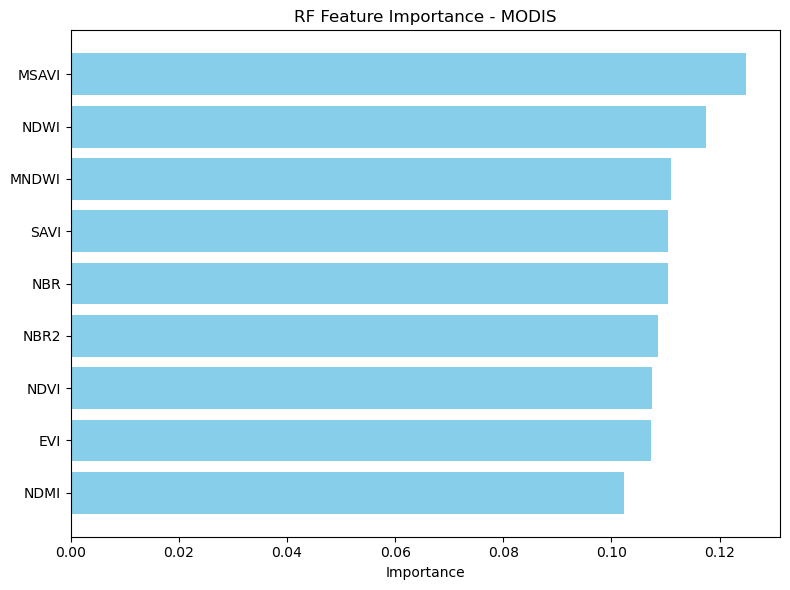

Suggested threshold for presence detection: 0.545


In [18]:
rf_occ_modis = rf_occurrence_analysis(modis_occu_merged1, field_col='Houbara_Number', satellite_name="MODIS")

### Old version

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1423
           1       0.83      0.87      0.85      1423

    accuracy                           0.85      2846
   macro avg       0.85      0.85      0.85      2846
weighted avg       0.85      0.85      0.85      2846

ROC-AUC: 0.922, PR-AUC: 0.919, CV-ROC-AUC: 0.929
Top Feature Importances:
   Index  Importance
3  MSAVI    0.121522
8  MNDWI    0.118312
7   NDWI    0.117704
6   NBR2    0.116566
4   NDMI    0.111062
5    NBR    0.105721
0   NDVI    0.103523
1    EVI    0.103236
2   SAVI    0.102355


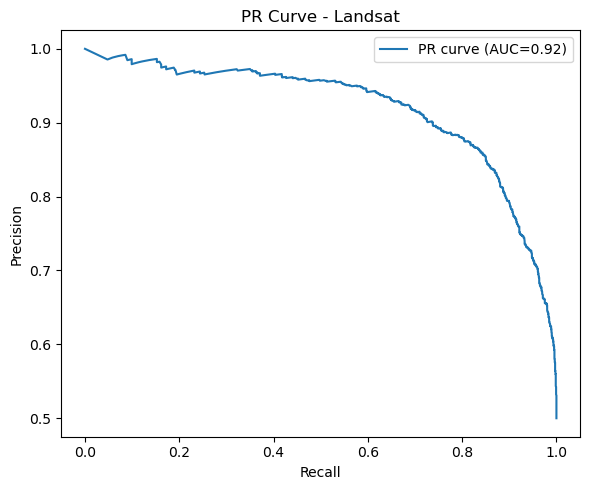

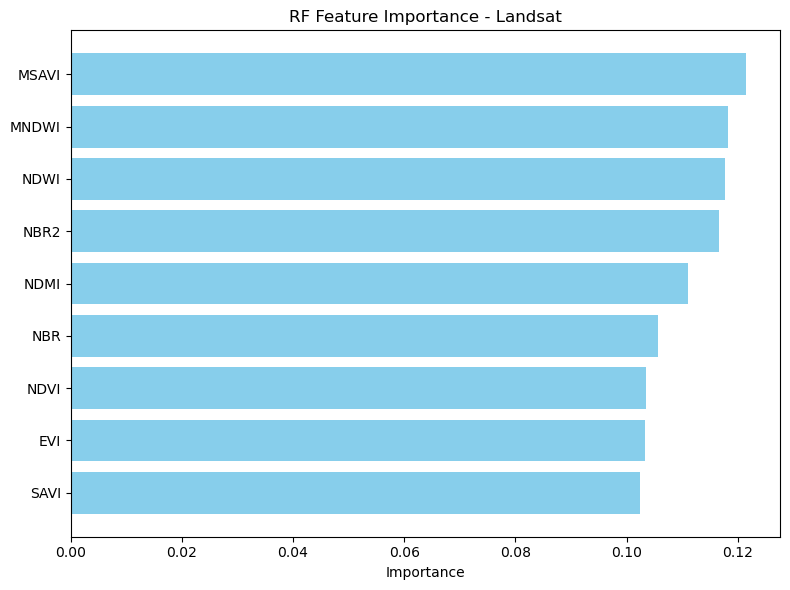

Suggested threshold for presence detection: 0.498


In [38]:
rf_occ_landsat = rf_occurrence_analysis(landsat_occu_merged, field_col='Houbara_Number', satellite_name="Landsat")

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.84       945
           1       0.82      0.87      0.85       944

    accuracy                           0.84      1889
   macro avg       0.84      0.84      0.84      1889
weighted avg       0.84      0.84      0.84      1889

ROC-AUC: 0.922, PR-AUC: 0.923, CV-ROC-AUC: 0.925
Top Feature Importances:
   Index  Importance
8  MNDWI    0.139447
6   NBR2    0.135651
4   NDMI    0.133643
7   NDWI    0.122799
5    NBR    0.114944
1    EVI    0.108600
0   NDVI    0.081884
2   SAVI    0.081590
3  MSAVI    0.081443


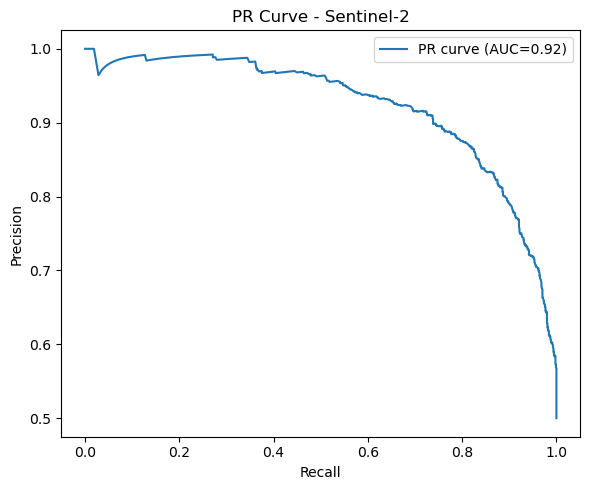

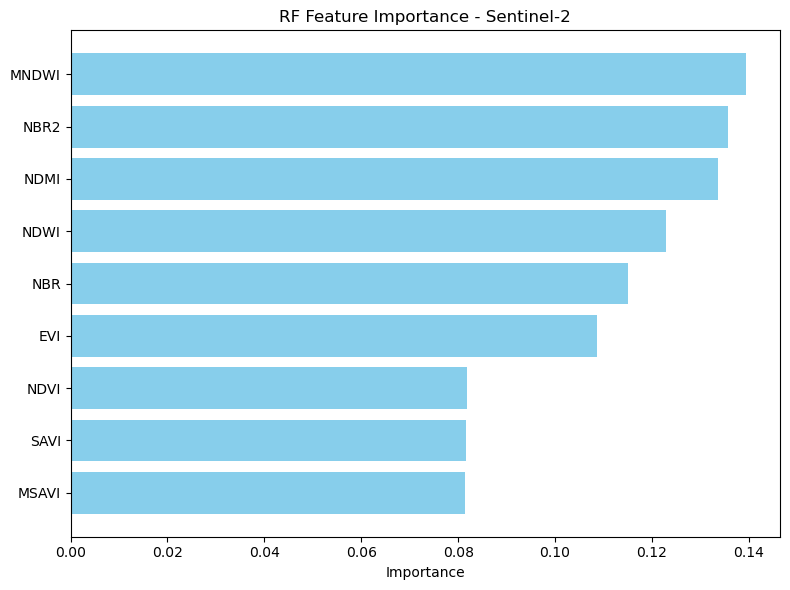

Suggested threshold for presence detection: 0.511


In [39]:
rf_occ_sentinel2 = rf_occurrence_analysis(sentinel2_occu_merged, field_col='Houbara_Number', satellite_name="Sentinel-2")

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1503
           1       0.81      0.88      0.84      1502

    accuracy                           0.84      3005
   macro avg       0.84      0.84      0.84      3005
weighted avg       0.84      0.84      0.84      3005

ROC-AUC: 0.918, PR-AUC: 0.918, CV-ROC-AUC: 0.929
Top Feature Importances:
   Index  Importance
3  MSAVI    0.131022
2   SAVI    0.117748
7   NDWI    0.113425
1    EVI    0.109630
8  MNDWI    0.109544
5    NBR    0.109057
0   NDVI    0.108312
6   NBR2    0.102174
4   NDMI    0.099088


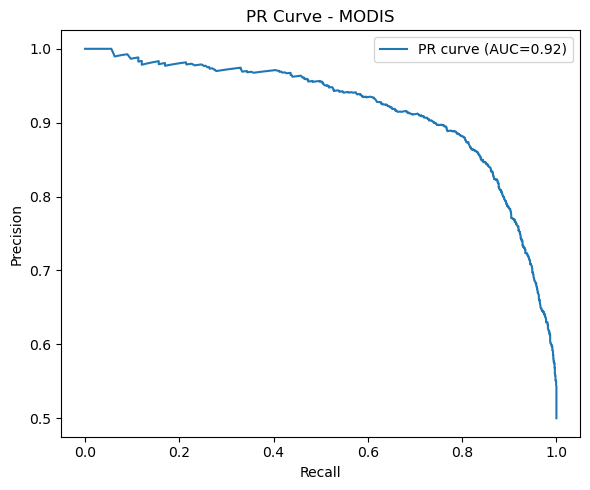

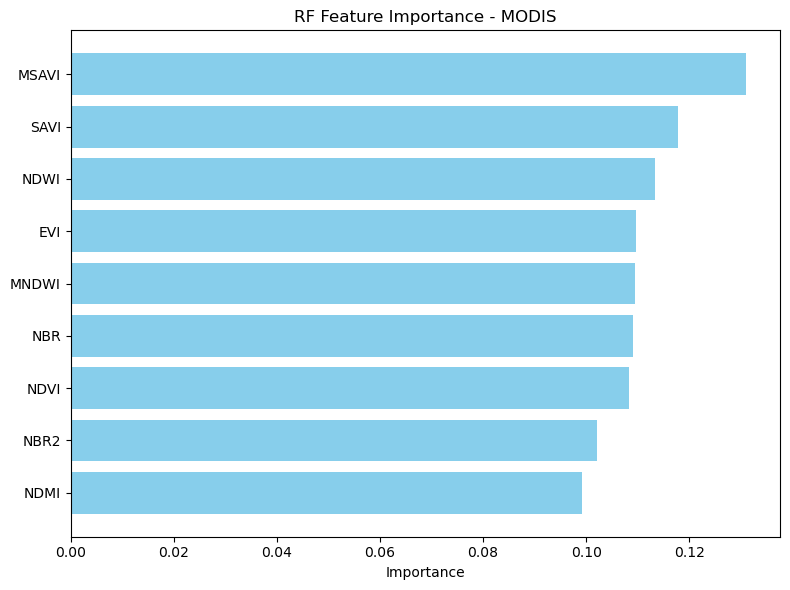

Suggested threshold for presence detection: 0.530


In [138]:
rf_occ_modis = rf_occurrence_analysis(modis_occu_merged, field_col='Houbara_Number', satellite_name="MODIS")

## 3.3 Temporal Patterns

### 3.3.1 RS-Field Intergrated pattern

In [4]:
# --- Load the Data if Needed ---
field_files = [
    'Trophic survey data analysis_all_2016-2023_habitat.csv',  # Vegetation plots
    'Houbara_Count_Standardized_Morocco_2016-23.csv'           # Bustard occurrence
]

veg_df = pd.read_csv(field_files[0])
occu_df = pd.read_csv(field_files[1])

# --- Load Field-RS Merged files  ---
merged_files = ['Merged_Veg_Landsat.csv',
                'Merged_Veg_Sentinel2.csv',
                'Merged_Veg_Modis.csv',
                "Merged_Veg_Combined.csv", # best index csv
                'Merged_Houbara_Landsat.csv',
                'Merged_Houbara_Sentinel2.csv',
                'Merged_Houbara_Modis.csv']

# merged_dfs = [pd.read_csv(fp) for fp in merged_files]
landsat_veg_merged = pd.read_csv(merged_files[0])
sentinel2_veg_merged = pd.read_csv(merged_files[1])
modis_veg_merged = pd.read_csv(merged_files[2])
best_veg = pd.read_csv(merged_files[3])

landsat_occu_merged = pd.read_csv(merged_files[4])
sentinel2_occu_merged = pd.read_csv(merged_files[5])
modis_occu_merged = pd.read_csv(merged_files[6])

In [92]:
best_veg.head()

,Station,Lat,Lon,Year,Season,F_alive,F_dead,F_veg,F_ground,Habitat,date_pseudo,Satellite,Index,Value
0,ALBSEP1,33.14973,-3.94129,2016,Spring,0.00,0.07,0.07,0.93,Alluvial spread area,4/20/2016,Landsat,NDMI,-0.05
1,ALBSEP1,33.14973,-3.94129,2016,Winter,0.00,0.04,0.04,0.96,Alluvial spread area,12/10/2016,Landsat,NDMI,-0.03
2,ALBSEP1,33.14973,-3.94129,2017,Summer,0.01,0.00,0.02,0.98,Alluvial spread area,6/20/2017,Landsat,NDMI,-0.08
3,ALBSEP1,33.14973,-3.94129,2017,Fall,0.00,0.01,0.01,0.99,Alluvial spread area,10/20/2017,Landsat,NDMI,-0.08
4,ALBSEP1,33.14973,-3.94129,2018,Spring,0.00,0.04,0.04,0.96,Alluvial spread area,4/20/2018,Landsat,NDMI,-0.09


In [95]:
print(best_veg["Season"].unique())

['Spring' 'Winter' 'Summer' 'Fall']


In [54]:
best_veg.columns

Index(['Station', 'Lat', 'Lon', 'Year', 'Season', 'F_alive', 'F_dead', 'F_veg',
       'F_ground', 'Habitat', 'date_pseudo', 'Satellite', 'Index', 'Value'],
      dtype='object')

In [93]:
# Keep only the best index per Habitat × Satellite
best_veg_filtered = best_veg.groupby(["Habitat", "Satellite", "Index"], as_index=False).first()
best_veg_filtered.shape #(18, 14)

(18, 14)

### 3.3.1 Updated on 12/2/2025: The seasonal and annual patterns were plotted only using the best indices
- **plot_all_habitats_combined_tight(best_veg) this version was adopted!!**

In [5]:
best_veg.groupby(["Habitat","Satellite","Year","Season"]).size()
# there were missing values for certain habitats or Satellite

Habitat               Satellite   Year  Season
Alluvial spread area  Landsat     2016  Fall      11
                                        Spring    18
                                        Summer    11
                                        Winter    17
                                  2017  Fall      19
                                                  ..
Wadi                  Sentinel-2  2022  Summer     5
                                  2023  Fall       5
                                        Spring     5
                                        Summer     5
                                        Winter     5
Length: 516, dtype: int64

In [6]:
print(best_veg.dtypes)          # ensure Value and F_alive are float64
print(best_veg.columns)         # ensure there are no duplicate column names
print(best_veg.shape)           # check total rows

Station         object
Lat            float64
Lon            float64
Year             int64
Season          object
F_alive        float64
F_dead         float64
F_veg          float64
F_ground       float64
Habitat         object
date_pseudo     object
Satellite       object
Index           object
Value          float64
dtype: object
Index(['Station', 'Lat', 'Lon', 'Year', 'Season', 'F_alive', 'F_dead', 'F_veg',
       'F_ground', 'Habitat', 'date_pseudo', 'Satellite', 'Index', 'Value'],
      dtype='object')
(9147, 14)


In [7]:
# 1. Reset the index of the original DataFrame
best_veg_clean = best_veg.reset_index(drop=True) 

# 2. Perform the aggregation on the clean DataFrame
avg_table = best_veg_clean.groupby(
    ["Habitat", "Satellite", "Year", "Season", "Index"],
    as_index=False
).agg({
    "Value": "mean",
    "F_alive": "mean"
})

# 3. Look at result
print(avg_table.head())
print(avg_table.shape) #(516, 7)

                Habitat Satellite  Year  Season Index     Value   F_alive
0  Alluvial spread area   Landsat  2016    Fall  NDMI -0.078182  0.007273
1  Alluvial spread area   Landsat  2016  Spring  NDMI -0.068889  0.004444
2  Alluvial spread area   Landsat  2016  Summer  NDMI -0.078182  0.002727
3  Alluvial spread area   Landsat  2016  Winter  NDMI -0.089412  0.000000
4  Alluvial spread area   Landsat  2017    Fall  NDMI -0.085789  0.024211
(516, 7)


#### Adopted version!!

In [34]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_all_habitats_combined_tight(
    df,
    field_col="F_alive",
    output_dir="plots_combined",
    figsize=(8, 4),
    dpi=300,
    max_xticks=10  # max number of x-axis labels to show
):
    """
    Dual-axis plot (tight):
    - Left axis: F_alive (global range)
    - Right axis: RS Index (dynamic per habitat)
    - Tighter figure, adjusted fonts, reduced x-label clutter
    """

    os.makedirs(output_dir, exist_ok=True)

    # --- Configure seasons ---
    season_order = ["Spring", "Summer", "Fall", "Winter"]
    df["Season"] = pd.Categorical(df["Season"], categories=season_order, ordered=True)
    habitats = sorted(df["Habitat"].str.strip().unique().tolist())

    # --- F_alive global y-limits ---
    f_vals = df[field_col].dropna().values
    if len(f_vals) == 0:
        raise ValueError(f"No valid values found for {field_col}.")
    
    f_low, f_high = np.nanpercentile(f_vals, [2, 98])
    if f_low == f_high:
        f_low, f_high = np.nanmin(f_vals), np.nanmax(f_vals)
    f_range = f_high - f_low
    if f_range == 0:
        f_range = 1
    f_ylim = (f_low - 0.1*f_range, f_high + 0.1*f_range)

    # --- Satellite colors ---
    satellites = sorted(df["Satellite"].dropna().unique().tolist())
    color_palette = sns.color_palette("tab10", n_colors=max(10, len(satellites)))
    satellite_colors = {sat: color_palette[i % len(color_palette)] for i, sat in enumerate(satellites)}

    for habitat in habitats:
        df_sel = df[df["Habitat"].str.strip() == habitat].copy()
        if df_sel.empty:
            print(f"No data for habitat '{habitat}', skipping.")
            continue

        df_sel = df_sel.sort_values(["Year", "Season"])
        df_sel["Season_Year"] = df_sel["Year"].astype(str) + "-" + df_sel["Season"].astype(str)
        x_axis = df_sel["Season_Year"].unique().tolist()

        # --- F_alive values ---
        df_field = df_sel.groupby("Season_Year")[field_col].mean().reindex(x_axis)

        # --- Satellite-Index combinations ---
        combos = sorted(df_sel[["Satellite", "Index"]].drop_duplicates().values.tolist())

        # # --- RS axis limits ---
        # rs_vals_habitat = df_sel["Value"].dropna().values
        # if len(rs_vals_habitat) > 0:
        #     rs_low, rs_high = np.nanpercentile(rs_vals_habitat, [2, 100])
        #     if rs_low == rs_high:
        #         rs_low -= 0.01 * abs(rs_low) if rs_low != 0 else 0.01
        #         rs_high += 0.01 * abs(rs_high) if rs_high != 0 else 0.01
        #     rs_range = rs_high - rs_low
        #     rs_ylim = (rs_low - 0.01*rs_range, rs_high + 0.01*rs_range)
        # else:
        #     rs_ylim = (0, 1)

        # --- Figure ---
        fig, ax1 = plt.subplots(figsize=figsize)

        # LEFT AXIS: F_alive
        ax1.plot(x_axis, df_field.values, marker="o", color="black", linewidth=1.5, label=field_col)
        ax1.set_ylabel(field_col, color="black", fontsize=10)
        ax1.tick_params(axis="y", labelcolor="black", labelsize=9)
        ax1.set_ylim(f_ylim)

        # --- x-axis: reduce clutter ---
        # ax1.tick_params(axis="x", rotation=45, labelsize=8)
        n_labels = len(x_axis)
        # if n_labels > max_xticks:
        #     step = max(1, n_labels // max_xticks)
        #     ax1.set_xticks(range(0, n_labels, step))
        #     ax1.set_xticklabels([x_axis[i] for i in range(0, n_labels, step)], rotation=45, ha="right")
        # else:
        #     ax1.set_xticks(range(n_labels))
        #     ax1.set_xticklabels(x_axis, rotation=45, ha="right")

        # ax1.grid(axis="x", linestyle="--", alpha=0.3)

        if n_labels > max_xticks:
            step = max(1, n_labels // max_xticks)
        else:
            step = 1

        tick_positions = np.arange(0, n_labels, step)
        tick_labels = [x_axis[i] for i in tick_positions]

        ax1.set_xticks(tick_positions)
        ax1.set_xticklabels(tick_labels, rotation=30, ha="right", fontsize=8)
        ax1.grid(axis="x", linestyle="--", alpha=0.3)
        
        
        # RIGHT AXIS: RS index
        ax2 = ax1.twinx()
        ax2.set_ylabel("RS Index Value", fontsize=10)
        ax2.tick_params(axis="y", labelsize=9)
        # ax2.set_ylim(rs_ylim)

        for sat, idx in combos:
            df_rs = df_sel[(df_sel["Satellite"] == sat) & (df_sel["Index"] == idx)]
            if df_rs.empty or df_rs["Value"].dropna().empty:
                continue
            df_rs_plot = df_rs.groupby("Season_Year")["Value"].mean().reindex(x_axis)
            ax2.plot(x_axis, df_rs_plot.values, marker="o", linewidth=1.2,
                     color=satellite_colors.get(sat, "grey"), label=f"{sat}-{idx}")

        # Legends
        ax1.legend(loc="upper left", fontsize=8)
        ax2.legend(loc="upper right", fontsize=8)

        plt.title(habitat, fontsize=12)
        plt.tight_layout()

        # SAVE
        fname = f"{habitat.replace(' ', '_')}_combined_tight.png"
        fpath = os.path.join(output_dir, fname)
        plt.savefig(fpath, dpi=dpi, bbox_inches="tight")
        plt.close()
        print(f"Saved: {fpath}")


In [35]:
plot_all_habitats_combined_tight(best_veg)

Saved: plots_combined\Alluvial_spread_area_combined_tight.png
Saved: plots_combined\Gully_combined_tight.png
Saved: plots_combined\Macrochloa_steppe_combined_tight.png
Saved: plots_combined\Reg_combined_tight.png
Saved: plots_combined\Salty_steppe_combined_tight.png
Saved: plots_combined\Wadi_combined_tight.png


#### Discarded!

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_avg_table_seasonal(
    avg_table,
    field_col="F_alive",
    value_col="Value",
    output_dir="plots_combined",
    figsize=(12, 5),
    dpi=300
):
    """
    Plot seasonal dynamics of F_alive and RS indices per habitat using pre-averaged data.

    Parameters
    ----------
    avg_table : pd.DataFrame
        DataFrame with columns: Habitat, Satellite, Index, Year, Season, field_col, value_col
    field_col : str
        Column name for averaged F_alive
    value_col : str
        Column name for averaged RS index
    output_dir : str
        Directory to save plots
    figsize : tuple
        Figure size
    dpi : int
        Figure resolution
    """

    os.makedirs(output_dir, exist_ok=True)

    # --- Configure seasons ---
    season_order = ["Spring", "Summer", "Fall", "Winter"]
    avg_table["Season"] = pd.Categorical(avg_table["Season"], categories=season_order, ordered=True)

    # --- Habitats and satellites ---
    habitats = sorted(avg_table["Habitat"].str.strip().unique())
    satellites = sorted(avg_table["Satellite"].dropna().unique())
    color_palette = sns.color_palette("tab10", n_colors=max(10, len(satellites)))
    satellite_colors = {sat: color_palette[i % len(color_palette)] for i, sat in enumerate(satellites)}

    # --- F_alive global y-limits ---
    f_vals = avg_table[field_col].dropna().values
    if len(f_vals) == 0:
        raise ValueError(f"No valid values found for {field_col}.")
    
    f_low, f_high = np.nanpercentile(f_vals, [2, 100])
    if f_low == f_high:
        f_low, f_high = np.nanmin(f_vals), np.nanmax(f_vals)
    f_range = f_high - f_low
    if f_range == 0:
        f_range = 1
    f_ylim = (f_low - 0.1*f_range, f_high + 0.1*f_range)

    # --- Plot per habitat ---
    for habitat in habitats:
        df_sel = avg_table[avg_table["Habitat"].str.strip() == habitat].copy()
        if df_sel.empty:
            print(f"No data for habitat '{habitat}', skipping.")
            continue

        # --- Season-Year for x-axis ---
        df_sel = df_sel.sort_values(["Year", "Season"])
        df_sel["Season_Year"] = df_sel["Year"].astype(str) + "-" + df_sel["Season"].astype(str)
        x_axis = sorted(df_sel["Season_Year"].unique(), key=lambda x: (int(x.split("-")[0]), season_order.index(x.split("-")[1])))

        # --- F_alive values ---
        df_field = df_sel.groupby("Season_Year")[field_col].mean().reindex(x_axis)

        # --- Satellite-Index combinations ---
        combos = sorted(df_sel[["Satellite", "Index"]].drop_duplicates().values.tolist())

        # --- RS axis limits per habitat ---
        rs_vals_habitat = df_sel[value_col].dropna().values
        if len(rs_vals_habitat) > 0:
            rs_low, rs_high = np.nanpercentile(rs_vals_habitat, [2, 99.5])
            if rs_low == rs_high:
                rs_low -= 0.01 * abs(rs_low) if rs_low != 0 else 0.01
                rs_high += 0.01 * abs(rs_high) if rs_high != 0 else 0.01
            rs_range = rs_high - rs_low
            rs_ylim = (rs_low - 0.01*rs_range, rs_high + 0.01*rs_range)
        else:
            rs_ylim = (0, 1)

        # --- Figure ---
        fig, ax1 = plt.subplots(figsize=figsize)

        # LEFT AXIS: F_alive
        ax1.plot(x_axis, df_field.values, marker="o", color="black", linewidth=1.5, label=field_col)
        ax1.set_ylabel(field_col, color="black")
        ax1.tick_params(axis="y", labelcolor="black")
        ax1.set_ylim(f_ylim)
        ax1.tick_params(axis="x", rotation=45)
        ax1.set_xticks(range(len(x_axis)))
        ax1.set_xticklabels(x_axis, rotation=45, ha="right")
        ax1.grid(axis="x", linestyle="--", alpha=0.3)

        # RIGHT AXIS: RS index
        ax2 = ax1.twinx()
        ax2.set_ylabel("RS Index Value")
        ax2.set_ylim(rs_ylim)

        for sat, idx in combos:
            df_rs = df_sel[(df_sel["Satellite"] == sat) & (df_sel["Index"] == idx)]
            if df_rs.empty or df_rs[value_col].dropna().empty:
                continue
            df_rs_plot = df_rs.groupby("Season_Year")[value_col].mean().reindex(x_axis)
            ax2.plot(x_axis, df_rs_plot.values, marker="o", linewidth=1.2,
                     color=satellite_colors.get(sat, "grey"), label=f"{sat}-{idx}")

        # Legends
        ax1.legend(loc="upper left", fontsize=8)
        ax2.legend(loc="upper right", fontsize=8)

        plt.title(habitat)
        plt.tight_layout()

        # SAVE
        fname = f"{habitat.replace(' ', '_')}_avg_combined.png"
        fpath = os.path.join(output_dir, fname)
        plt.savefig(fpath, dpi=dpi, bbox_inches="tight")
        plt.close()
        print(f"Saved: {fpath}")


In [9]:
plot_avg_table_seasonal(avg_table)

Saved: plots_combined\Alluvial_spread_area_avg_combined.png
Saved: plots_combined\Gully_avg_combined.png
Saved: plots_combined\Macrochloa_steppe_avg_combined.png
Saved: plots_combined\Reg_avg_combined.png
Saved: plots_combined\Salty_steppe_avg_combined.png
Saved: plots_combined\Wadi_avg_combined.png


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt


def plot_combined_satellite_index(
    df,
    habitat,
    field_col="F_alive",
    output_dir="plots_combined",
    figsize=(12, 5),
    dpi=300
):
    """
    One figure per habitat:
    - Left y-axis: F_alive
    - Right y-axis: all satellite × RS index (Value)
    - Shared x-axis: full ordered Season-Year timeline
    """

    os.makedirs(output_dir, exist_ok=True)

    # ------------------------------
    # Filter habitat
    # ------------------------------
    df_sel = df[df["Habitat"].str.strip() == habitat.strip()].copy()
    if df_sel.empty:
        print(f"No data for habitat '{habitat}'.")
        return

    # Season ordering
    season_order = ["Spring", "Summer", "Autumn", "Fall", "Winter"]
    df_sel["Season"] = pd.Categorical(df_sel["Season"], categories=season_order, ordered=True)

    # ---------------------------------------------------------------------
    # Build a complete ordered x-axis (Season-Year string) for consistency
    # ---------------------------------------------------------------------
    df_sel = df_sel.sort_values(["Year", "Season"])
    df_sel["Season_Year"] = df_sel["Year"].astype(str) + "-" + df_sel["Season"].astype(str)

    # Complete unique x-axis
    x_axis = df_sel["Season_Year"].unique().tolist()

    # ---------------------------------------------------------------------
    # FIELD aggregated values
    # ---------------------------------------------------------------------
    df_field = (
        df_sel.groupby(["Season_Year"])[field_col]
              .mean()
              .reindex(x_axis)
    )

    # ---------------------------------------------------------------------
    # Unique Satellite–Index combinations
    # ---------------------------------------------------------------------
    combos = sorted(df_sel[["Satellite", "Index"]].drop_duplicates().values.tolist())

    # ---------------------------------------------------------------------
    # PLOT
    # ---------------------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=figsize)

    # FIELD
    ax1.plot(x_axis, df_field.values, marker='o', color="forestgreen", label=field_col)
    ax1.set_ylabel(field_col, color="forestgreen")
    ax1.tick_params(axis="y", labelcolor="forestgreen")
    ax1.tick_params(axis="x", rotation=45)

    # ---------------------------------------------------------------------
    # RS indices (second y-axis)
    # ---------------------------------------------------------------------
    ax2 = ax1.twinx()
    rs_labels = []

    for sat, idx in combos:
        df_rs = (
            df_sel[(df_sel["Satellite"] == sat) & (df_sel["Index"] == idx)]
            .groupby("Season_Year")["Value"]
            .mean()
            .reindex(x_axis)
        )

        label = f"{sat}-{idx}"
        rs_labels.append(label)

        ax2.plot(x_axis, df_rs.values, marker='o', label=label)

    ax2.set_ylabel("RS Index Value")
    
    # Combined legend: field on left, RS on right
    ax1.legend(loc="upper left", fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)

    # ------------------------------
    # Title & Layout
    # ------------------------------
    plt.title(f"{habitat}: F_alive vs Satellite RS Indices")
    plt.tight_layout()

    # ------------------------------
    # Export figure
    # ------------------------------
    fname = f"{habitat.replace(' ', '_')}_combined.png"
    fpath = os.path.join(output_dir, fname)
    plt.savefig(fpath, dpi=dpi, bbox_inches="tight")
    plt.close()

    print(f"Saved: {fpath}")


In [112]:
plot_combined_satellite_index(best_veg, habitat="Alluvial spread area")

Saved: plots_combined\Alluvial_spread_area_combined1.png


In [45]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def plot_combined_satellite_index(
    df,
    habitat,
    field_col="F_alive",
    output_dir="plots_combined",
    figsize=(10, 5),
    dpi=300
):
    """
    Improved:
    - F_alive line in black
    - Dual-axis scaling adjusted so RS values fall in a visually comparable zone
    """

    os.makedirs(output_dir, exist_ok=True)

    # ------------------------------
    # Filter habitat
    # ------------------------------
    df_sel = df[df["Habitat"].str.strip() == habitat.strip()].copy()
    if df_sel.empty:
        print(f"No data for habitat '{habitat}'.")
        return

    # Season ordering
    season_order = ["Spring", "Summer", "Autumn", "Fall", "Winter"]
    df_sel["Season"] = pd.Categorical(df_sel["Season"], categories=season_order, ordered=True)

    # ---------------------------------------------------------------------
    # Build a complete ordered x-axis (Season-Year string)
    # ---------------------------------------------------------------------
    df_sel = df_sel.sort_values(["Year", "Season"])
    df_sel["Season_Year"] = df_sel["Year"].astype(str) + "-" + df_sel["Season"].astype(str)
    x_axis = df_sel["Season_Year"].unique().tolist()

    # ---------------------------------------------------------------------
    # FIELD aggregated values
    # ---------------------------------------------------------------------
    df_field = (
        df_sel.groupby(["Season_Year"])[field_col]
              .mean()
              .reindex(x_axis)
    )

    # ---------------------------------------------------------------------
    # Satellite–Index combinations
    # ---------------------------------------------------------------------
    combos = sorted(df_sel[["Satellite", "Index"]].drop_duplicates().values.tolist())

    # ---------------------------------------------------------------------
    # Compute global RS min/max for scaling
    # ---------------------------------------------------------------------
    rs_all = df_sel.groupby(["Season_Year"])["Value"].mean().reindex(x_axis)
    rs_min, rs_max = np.nanmin(rs_all.values), np.nanmax(rs_all.values)

    f_min, f_max = np.nanmin(df_field.values), np.nanmax(df_field.values)

    # We map RS range into roughly the same scale of F_alive for comparable plotting
    # scale_factor brings their value ranges closer
    if rs_max != rs_min:
        scale_factor = (f_max - f_min) / (rs_max - rs_min) * 0.6  
        # 0.7 factor to avoid overlapping too strongly
    else:
        scale_factor = 1.0

    # ---------------------------------------------------------------------
    # PLOT
    # ---------------------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=figsize)

    # FIELD (Left axis) — now black
    ax1.plot(x_axis, df_field.values, marker='o', color="black", label=field_col)
    ax1.set_ylabel(field_col, color="black")
    ax1.tick_params(axis="y", labelcolor="black")
    ax1.tick_params(axis="x", rotation=45)

    # ---------------------------------------------------------------------
    # RS indices (Right axis) with scaled values
    # ---------------------------------------------------------------------
    ax2 = ax1.twinx()
    rs_labels = []

    for sat, idx in combos:
        df_rs = (
            df_sel[(df_sel["Satellite"] == sat) & (df_sel["Index"] == idx)]
            .groupby("Season_Year")["Value"]
            .mean()
            .reindex(x_axis)
        )

        # Apply scaling for visual comparability
        df_rs_scaled = (df_rs - rs_min) * scale_factor + f_min

        label = f"{sat}-{idx}"
        rs_labels.append(label)

        ax2.plot(x_axis, df_rs_scaled.values, marker='o', label=label)

    ax2.set_ylabel("RS Index Value")

    # Combined legend
    ax1.legend(loc="upper left", fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)

    # ------------------------------
    # Title & Layout
    # ------------------------------
    plt.title(f"{habitat} ")
    plt.tight_layout()

    # ------------------------------
    # Export
    # ------------------------------
    fname = f"{habitat.replace(' ', '_')}_combined1.png"
    fpath = os.path.join(output_dir, fname)
    plt.savefig(fpath, dpi=dpi, bbox_inches="tight")
    plt.close()

    print(f"Saved: {fpath}")


In [46]:
plot_combined_satellite_index(best_veg, habitat="Alluvial spread area")

Saved: plots_combined\Alluvial_spread_area_combined1.png


In [116]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_all_habitats_combined(
    df,
    field_col="F_alive",
    output_dir="plots_combined",
    figsize=(8, 4),
    dpi=300
):
    """
    Dual-axis plot:
    - F_alive axis: fixed global range across all habitats
    - RS Index axis: dynamic per habitat using 2%-98% quantiles with padding
    """

    os.makedirs(output_dir, exist_ok=True)

    # Configure seasons
    season_order = ["Spring", "Summer", "Autumn", "Fall", "Winter"]
    df["Season"] = pd.Categorical(df["Season"], categories=season_order, ordered=True)
    habitats = sorted(df["Habitat"].str.strip().unique().tolist())

    # F_alive global y-limits (left axis)
    f_vals = df[field_col].dropna().values
    if len(f_vals) == 0:
        raise ValueError(f"No valid values found for {field_col}.")
    
    f_low, f_high = np.nanpercentile(f_vals, [2, 98])
    if f_low == f_high:
        f_low, f_high = np.nanmin(f_vals), np.nanmax(f_vals)
    f_range = f_high - f_low
    if f_range == 0:
        f_range = 1  # avoid zero-range
    f_ylim = (f_low - 0.1*f_range, f_high + 0.1*f_range)

    # Satellite color consistency
    satellites = sorted(df["Satellite"].dropna().unique().tolist())
    color_palette = sns.color_palette("tab10", n_colors=max(10, len(satellites)))
    satellite_colors = {sat: color_palette[i % len(color_palette)] for i, sat in enumerate(satellites)}

    for habitat in habitats:
        df_sel = df[df["Habitat"].str.strip() == habitat].copy()
        if df_sel.empty:
            print(f"No data for habitat '{habitat}', skipping.")
            continue

        df_sel = df_sel.sort_values(["Year", "Season"])
        df_sel["Season_Year"] = df_sel["Year"].astype(str) + "-" + df_sel["Season"].astype(str)
        x_axis = df_sel["Season_Year"].unique().tolist()

        # F_alive aggregated
        df_field = df_sel.groupby("Season_Year")[field_col].mean().reindex(x_axis)

        # Satellite-Index combinations
        combos = sorted(df_sel[["Satellite", "Index"]].drop_duplicates().values.tolist())

        # RS axis based on 2%-98% quantiles per habitat
        rs_vals_habitat = df_sel["Value"].dropna().values
        if len(rs_vals_habitat) > 0:
            rs_low, rs_high = np.nanpercentile(rs_vals_habitat, [2, 99.5])
            if rs_low == rs_high:
                # constant values: expand slightly
                rs_low -= 0.01 * abs(rs_low) if rs_low != 0 else 0.01
                rs_high += 0.01 * abs(rs_high) if rs_high != 0 else 0.01
            rs_range = rs_high - rs_low
            rs_ylim = (rs_low - 0.01*rs_range, rs_high + 0.01*rs_range)
        else:
            rs_ylim = (0, 1)  # fallback

        # Plot
        fig, ax1 = plt.subplots(figsize=figsize)

        # LEFT AXIS — F_alive
        ax1.plot(x_axis, df_field.values, marker="o", color="black", linewidth=1.5, label=field_col)
        ax1.set_ylabel(field_col, color="black")
        ax1.tick_params(axis="y", labelcolor="black")
        ax1.set_ylim(f_ylim)
        ax1.tick_params(axis="x", rotation=45)
        ax1.set_xticks(range(len(x_axis)))
        ax1.set_xticklabels(x_axis, rotation=45, ha="right")
        ax1.grid(axis="x", linestyle="--", alpha=0.3)

        # RIGHT AXIS — RS Index
        ax2 = ax1.twinx()
        ax2.set_ylabel("RS Index Value")
        ax2.set_ylim(rs_ylim)

        for sat, idx in combos:
            df_rs = df_sel[(df_sel["Satellite"] == sat) & (df_sel["Index"] == idx)]
            if df_rs.empty or df_rs["Value"].dropna().empty:
                continue
            df_rs_plot = df_rs.groupby("Season_Year")["Value"].mean().reindex(x_axis)
            ax2.plot(x_axis, df_rs_plot.values, marker="o", linewidth=1.2,
                     color=satellite_colors.get(sat, "grey"), label=f"{sat}-{idx}")

        # Legends
        ax1.legend(loc="upper left", fontsize=8)
        ax2.legend(loc="upper right", fontsize=8)

        plt.title(habitat)
        plt.tight_layout()

        # SAVE
        fname = f"{habitat.replace(' ', '_')}_combined2.png"
        fpath = os.path.join(output_dir, fname)
        plt.savefig(fpath, dpi=dpi, bbox_inches="tight")
        plt.close()
        print(f"Saved: {fpath}")


In [117]:
plot_all_habitats_combined(best_veg)

Saved: plots_combined\Alluvial_spread_area_combined2.png
Saved: plots_combined\Gully_combined2.png
Saved: plots_combined\Macrochloa_steppe_combined2.png
Saved: plots_combined\Reg_combined2.png
Saved: plots_combined\Salty_steppe_combined2.png
Saved: plots_combined\Wadi_combined2.png


### old-discarded parts

In [353]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import os

# def plot_seasonal_avg_dual_axis(merged_df, field_col='F_alive', satellite_name='RS', outdir='plots'):
#     """
#     Plot seasonal averages per year for RS indices vs field measurements, with dual y-axis.
#     Habitats are ignored if 'Habitat' not present.
#     """
#     os.makedirs(outdir, exist_ok=True)

#     # List of possible RS indices, filter only available
#     rs_indices = ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']
#     rs_indices = [col for col in rs_indices if col in merged_df.columns]

#     if len(rs_indices) == 0:
#         print(f"No RS indices found in {satellite_name}, skipping.")
#         return

#     n_indices = len(rs_indices)
#     ncols = 2
#     nrows = int(np.ceil(n_indices / ncols))
#     fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5*nrows), squeeze=False)

#     # Habitat groups
#     use_habitat = 'Habitat' in merged_df.columns
#     groups = merged_df['Habitat'].unique() if use_habitat else [None]

#     # Ensure season order if exists
#     season_order = ['Spring','Summer','Fall','Winter']
#     if 'Season' in merged_df.columns:
#         merged_df['Season'] = pd.Categorical(merged_df['Season'], categories=season_order, ordered=True)

#     for i, ind in enumerate(rs_indices):
#         row, col = divmod(i, ncols)
#         ax1 = axes[row, col]
#         ax2 = ax1.twinx()

#         for grp in groups:
#             df_group = merged_df.copy() if grp is None else merged_df[merged_df['Habitat']==grp].copy()
#             label = 'All' if grp is None else str(grp)

#             # Aggregate by Year / Season
#             agg_cols = [field_col, ind]
#             if 'Season' in df_group.columns:
#                 df_avg = df_group.groupby(['Year','Season'])[agg_cols].mean().reset_index()
#             else:
#                 df_avg = df_group.groupby(['Year'])[agg_cols].mean().reset_index()

#             # Build datetime
#             if 'Season' in df_avg.columns:
#                 season_middays = {'Spring':'05-05','Summer':'07-15','Fall':'10-15','Winter':'12-15'}
#                 df_avg['datetime'] = pd.to_datetime(
#                     df_avg['Year'].astype(str) + '-' + df_avg['Season'].astype(str).map(season_middays)
#                 )
#             else:
#                 df_avg['datetime'] = pd.to_datetime(df_avg['Year'].astype(str) + '-06-15')

#             # Plot field
#             ax1.plot(df_avg['datetime'], df_avg[field_col], marker='o', linestyle='-', alpha=0.6, label=f'{label} Field')
#             # Plot RS
#             ax2.plot(df_avg['datetime'], df_avg[ind], marker='x', linestyle='--', alpha=0.6, label=f'{label} {satellite_name}')

#         ax1.set_ylabel(field_col, color='green')
#         ax2.set_ylabel(ind, color='orange')
#         ax1.tick_params(axis='y', labelcolor='green')
#         ax2.tick_params(axis='y', labelcolor='orange')
#         ax1.set_xlabel('Date')
#         ax1.set_title(f'{ind} vs {field_col}', fontsize=14)
#         ax1.grid(lw=0.2)

#         # Combine legends
#         lines1, labels1 = ax1.get_legend_handles_labels()
#         lines2, labels2 = ax2.get_legend_handles_labels()
#         ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='best')

#     # Remove unused axes
#     total_subplots = nrows*ncols
#     if total_subplots > n_indices:
#         for j in range(n_indices, total_subplots):
#             fig.delaxes(axes.flatten()[j])

#     plt.suptitle(f'Seasonal Averages - {satellite_name}', fontsize=16)
#     plt.tight_layout(rect=[0,0,1,0.97])
#     outfile = os.path.join(outdir, f"{satellite_name}_seasonal_dual_axis.png")
#     plt.savefig(outfile, dpi=300, bbox_inches='tight')
#     plt.close(fig)
#     print(f"Saved figure to {outfile}")


In [354]:
# plot_seasonal_avg_dual_axis(landsat_veg_merged, field_col='F_alive', satellite_name='Landsat')

Saved figure to plots\Landsat_seasonal_dual_axis.png


In [285]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy import optimize
# import seaborn as sns
# import os

# # Seasonal sine function
# def seasonal_func(t, y0, amp, tau, phi):
#     return y0 + amp * np.sin(2 * np.pi * t / tau + phi)

# def plot_seasonal_avg_dual_axis_with_fit(merged_df, field_col='F_alive',
#                                          rs_indices=None,
#                                          satellite_name='RS',
#                                          outdir='plots'):
#     """
#     Plot seasonal averages per year for all habitats in one figure, with dual y-axes.
#     Fits a seasonal sine curve for field and RS data.
#     """
#     if 'Habitat' not in merged_df.columns:
#         raise ValueError("merged_df must contain 'Habitat' column")

#     os.makedirs(outdir, exist_ok=True)

#     # Default RS indices if not provided
#     if rs_indices is None:
#         rs_indices = [col for col in merged_df.columns if col in
#                       ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']]

#     if len(rs_indices) == 0:
#         print(f"No RS indices found in {satellite_name}, skipping.")
#         return

#     # Season order
#     season_order = ['Spring','Summer','Fall','Winter']
#     merged_df['Season'] = pd.Categorical(merged_df['Season'], categories=season_order, ordered=True)

#     habitats = merged_df['Habitat'].unique()
#     season_middays = {'Spring':'05-05','Summer':'07-15','Fall':'10-15','Winter':'12-15'}

#     # Colors for habitats
#     palette = sns.color_palette("tab20", len(habitats))
#     habitat_colors = dict(zip(habitats, palette))

#     # Plot setup
#     n_indices = len(rs_indices)
#     ncols = 2
#     nrows = int(np.ceil(n_indices / ncols))
#     fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5*nrows), squeeze=False)

#     for i, ind in enumerate(rs_indices):
#         row, col = divmod(i, ncols)
#         ax1 = axes[row, col]
#         ax2 = ax1.twinx()

#         for hab in habitats:
#             df_hab = merged_df[merged_df['Habitat'] == hab].copy()
#             df_avg = df_hab.groupby(['Year','Season'])[[field_col, ind]].mean().reset_index()

#             # Build datetime
#             df_avg['datetime'] = pd.to_datetime(
#                 df_avg['Year'].astype(str) + '-' + df_avg['Season'].astype(str).map(season_middays)
#             )
#             x_data = (df_avg['datetime'] - df_avg['datetime'].min()).dt.total_seconds() / (24*3600)

#             # ===== Field data + sine fit =====
#             y_field = df_avg[field_col].values.astype(float)
#             mask_field = np.isfinite(x_data) & np.isfinite(y_field)
#             x_fit, y_fit = x_data[mask_field], y_field[mask_field]
#             params_field = [np.nan]*4
#             if len(x_fit) >= 4:
#                 p0_field = [np.nanmean(y_fit), (np.nanmax(y_fit)-np.nanmin(y_fit))/2, 365, 0]
#                 try:
#                     params_field, _ = optimize.curve_fit(seasonal_func, x_fit, y_fit, p0=p0_field)
#                 except RuntimeError:
#                     print(f"Curve fitting failed for Field in {hab}-{ind}")

#             ax1.scatter(df_avg['datetime'], y_field, color=habitat_colors[hab], s=4, alpha=0.4, marker='o')
#             if np.all(np.isfinite(params_field)):
#                 ax1.plot(df_avg['datetime'], seasonal_func(x_data, *params_field),
#                          color=habitat_colors[hab], lw=1.5, linestyle='-',
#                          label=f'{hab} Field')

#             # ===== RS data + sine fit =====
#             y_rs = df_avg[ind].values.astype(float)
#             mask_rs = np.isfinite(x_data) & np.isfinite(y_rs)
#             x_fit_rs, y_fit_rs = x_data[mask_rs], y_rs[mask_rs]
#             params_rs = [np.nan]*4
#             if len(x_fit_rs) >= 4:
#                 p0_rs = [np.nanmean(y_fit_rs), (np.nanmax(y_fit_rs)-np.nanmin(y_fit_rs))/2, 365, 0]
#                 try:
#                     params_rs, _ = optimize.curve_fit(seasonal_func, x_fit_rs, y_fit_rs, p0=p0_rs)
#                 except RuntimeError:
#                     print(f"Curve fitting failed for RS in {hab}-{ind}")

#             ax2.scatter(df_avg['datetime'], y_rs, color=habitat_colors[hab], s=4, alpha=0.4, marker='x')
#             if np.all(np.isfinite(params_rs)):
#                 ax2.plot(df_avg['datetime'], seasonal_func(x_data, *params_rs),
#                          color=habitat_colors[hab], lw=1.5, linestyle='--',
#                          label=f'{hab} {satellite_name}')

#         # Axis formatting
#         ax1.set_ylabel(field_col, color='green')
#         ax2.set_ylabel(ind, color='orange')
#         ax1.tick_params(axis='y', labelcolor='green')
#         ax2.tick_params(axis='y', labelcolor='orange')
#         ax1.set_xlabel('Date')
#         ax1.set_title(f'{ind} vs {field_col}', fontsize=12)
#         ax1.grid(lw=0.2)

#         # Legends
#         lines1, labels1 = ax1.get_legend_handles_labels()
#         lines2, labels2 = ax2.get_legend_handles_labels()
#         ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='best')

#     # Remove unused axes
#     total_subplots = nrows*ncols
#     if total_subplots > n_indices:
#         for j in range(n_indices, total_subplots):
#             fig.delaxes(axes.flatten()[j])

#     plt.suptitle(f'Seasonal Averages per Habitat - {satellite_name}', fontsize=16)
#     plt.tight_layout(rect=[0, 0, 1, 0.97])

#     # Save figure
#     outfile = os.path.join(outdir, f"{satellite_name}_all_habitats_dual_axis.png")
#     plt.savefig(outfile, dpi=300, bbox_inches='tight')
#     plt.close(fig)
#     print(f"Saved figure to {outfile}")


In [356]:
# plot_seasonal_avg_dual_axis_with_fit(landsat_veg_merged, field_col='F_alive', satellite_name='Landsat')

Saved figure to plots\Landsat_all_habitats_dual_axis.png


In [384]:
def seasonal_func(t, y0, amp, tau, phi):
    """Sinusoidal seasonal function."""
    return y0 + amp * np.sin(2 * np.pi * t / tau + phi)
    
def plot_seasonal_avg_per_year_dual_axis(merged_df, field_col='F_alive', rs_indices=None, satellite_name='RS',outdir='plots'):
    """
    Plot seasonal averages per year for field vs RS indices with dual y-axis.
    """
    if rs_indices is None:
        rs_indices = [col for col in merged_df.columns if col.endswith('_corrected')]
    
    # Compute seasonal mean per year
    season_order = ['Spring','Summer','Fall','Winter']
    merged_df['Season'] = pd.Categorical(merged_df['Season'], categories=season_order, ordered=True)
    df_avg = merged_df.groupby(['Year','Season'])[[field_col]+rs_indices].mean().reset_index()
    
    # Convert season-year to approximate datetime
    season_middays = {'Spring':'05-05','Summer':'06-20','Fall':'10-20','Winter':'12-10'}
    df_avg['datetime'] = pd.to_datetime(df_avg['Year'].astype(str) + '-' + df_avg['Season'].astype(str).map(season_middays))
    # df_avg['datetime'] = pd.to_datetime(df_avg['Year'].astype(str)+'-'+df_avg['Season'].map(season_middays))
    x_data = (df_avg['datetime'] - df_avg['datetime'].min()).dt.total_seconds() / (24*3600)
    y_field = df_avg[field_col].values
    
    n_indices = len(rs_indices)
    ncols = 2
    nrows = int(np.ceil(n_indices/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5*nrows), squeeze=False)
    
    # Fit field seasonal curve
    p0_field = [np.mean(y_field), (np.max(y_field)-np.min(y_field))/2, 365, 0]
    params_field, _ = optimize.curve_fit(seasonal_func, x_data, y_field, p0=p0_field)
    
    for i, ind in enumerate(rs_indices):
        row, col = divmod(i, ncols)
        ax1 = axes[row, col]
        y_rs = df_avg[ind].values
        p0_rs = [np.mean(y_rs), (np.max(y_rs)-np.min(y_rs))/2, 365, 0]
        try:
            params_rs, _ = optimize.curve_fit(seasonal_func, x_data, y_rs, p0=p0_rs)
        except:
            params_rs = [np.nan]*4
        
        # Left axis: field
        ax1.scatter(df_avg['datetime'], y_field, c='green', s=4, alpha=0.5, label=f'Field ({field_col})')
        ax1.plot(df_avg['datetime'], seasonal_func(x_data, *params_field), c='green', lw=1.5, label='Field fit')
        ax1.set_ylabel(field_col, color='green')
        ax1.tick_params(axis='y', labelcolor='green', labelsize=12)
        ax1.grid(lw=0.2)
        
        # Right axis: RS index
        ax2 = ax1.twinx()
        ax2.scatter(df_avg['datetime'], y_rs, c='orange', s=4, alpha=0.5, label=f'{satellite_name} ({ind})')
        ax2.plot(df_avg['datetime'], seasonal_func(x_data, *params_rs), c='orange', lw=1.5, label='RS fit')
        ax2.set_ylabel(ind, color='orange')
        ax2.tick_params(axis='y', labelcolor='orange', labelsize=11)
        
        # Correlation
        corr = np.corrcoef(y_field, y_rs)[0,1]
        ax1.set_title(f'{ind} vs {field_col} (corr={corr:.2f})', fontsize=13)
        
        # Legends
        ax1.legend(loc='upper left', fontsize=12)
        ax2.legend(loc='upper right', fontsize=12)
        ax1.set_xlabel('Date', fontsize=14)
        ax1.tick_params(axis='x', labelsize=12)  # adjust tick label size
    
    # Remove empty subplots
    total_subplots = nrows*ncols
    if total_subplots > n_indices:
        for j in range(n_indices, total_subplots):
            fig.delaxes(axes.flatten()[j])
    plt.tight_layout()
    # plt.show()
    
    # Save figure
    outfile = os.path.join(outdir, f"{satellite_name}_overall_dual_axis.png")
    plt.savefig(outfile, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved figure to {outfile}")
    

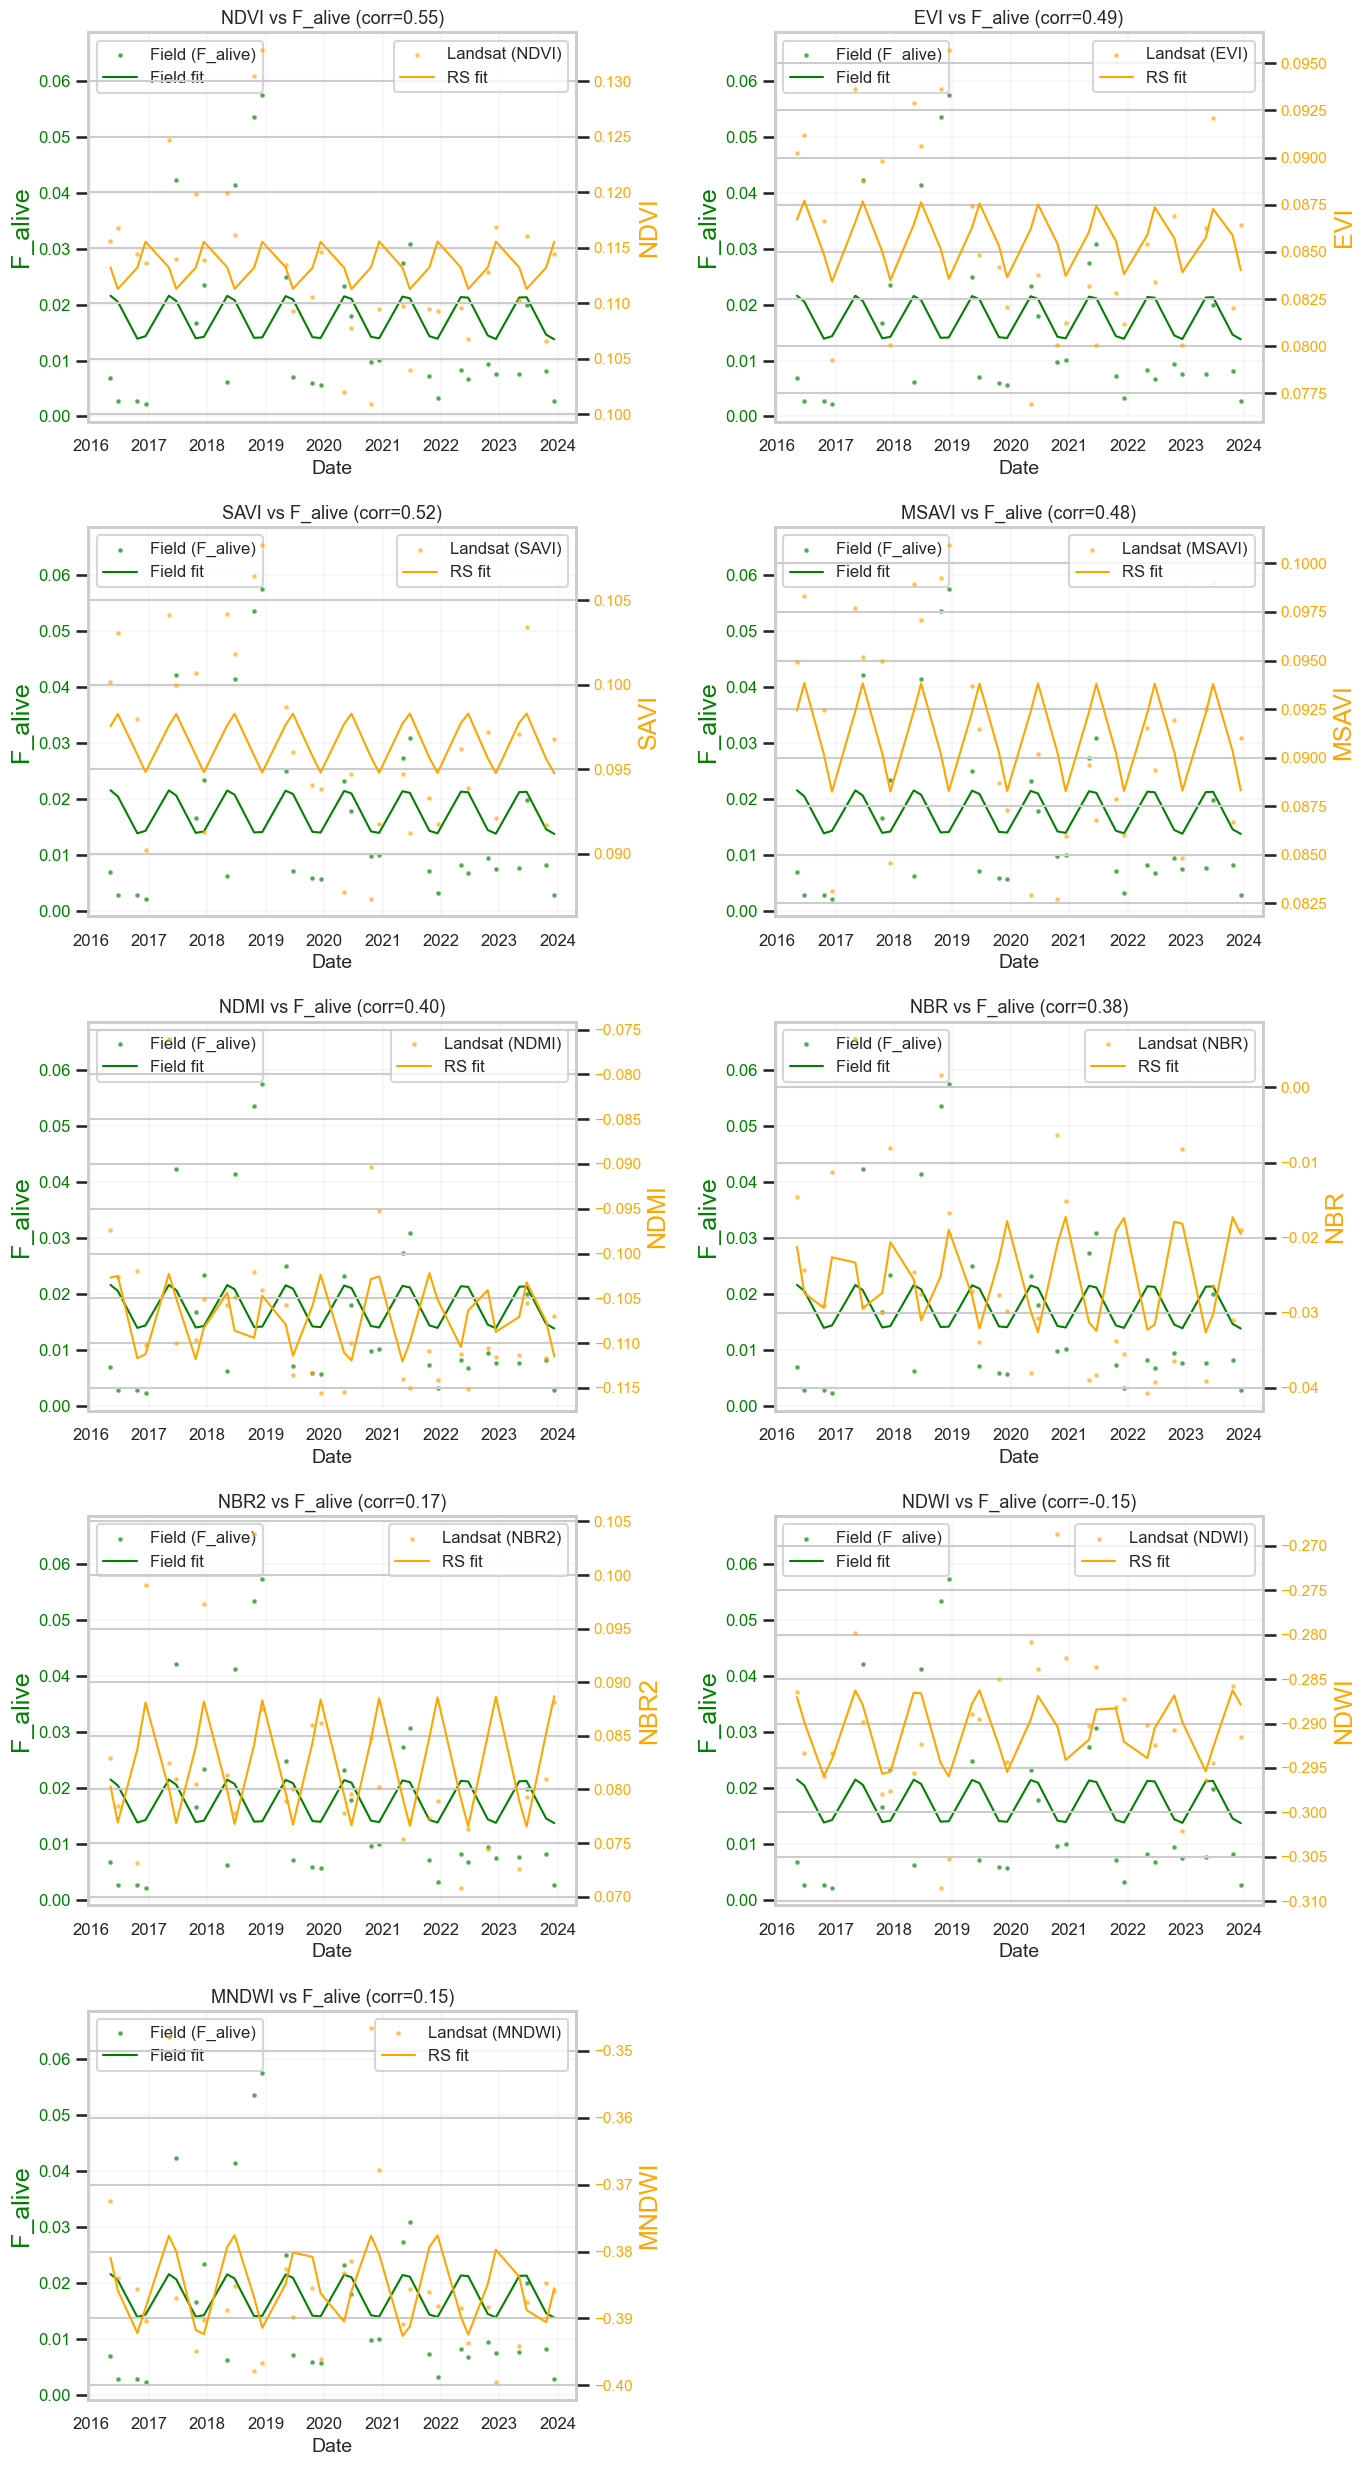

In [375]:
plot_seasonal_avg_per_year_dual_axis(merged_dfs[0], rs_indices=rs_index_list,satellite_name='Landsat')

In [494]:
# import os
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# def plot_seasonal_avg_per_habitat_dual_axis(
#     merged_df, field_col='F_alive',
#     rs_indices=None, satellite_name='RS',
#     output_dir='plots'):
#     """
#     Plot seasonal trends per habitat:
#     - One subplot per RS index
#     - Left y-axis: F_alive
#     - Right y-axis: RS index
#     - Scatter = yearly-seasonal averages
#     - Lines connecting seasonal-average points
#     - Export figure per habitat
#     - Export line data (seasonal averages) per habitat
#     - Y-axis auto-scaled
#     """

#     os.makedirs(output_dir, exist_ok=True)

#     # Determine RS indices
#     if rs_indices is None:
#         rs_indices = [c for c in merged_df.columns if c.upper() in
#                       ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']]

#     season_order = ['Spring', 'Summer', 'Fall', 'Winter']
#     season_numeric = {s:i for i,s in enumerate(season_order)}

#     habitats = merged_df['Habitat'].unique()
#     line_data_list = []

#     # Aggregate by Year-Season-Habitat
#     grouped = merged_df.groupby(['Year','Season','Habitat']).agg(
#         field_mean=(field_col,'mean'),
#         **{ind:(ind,'mean') for ind in rs_indices}
#     ).reset_index()
#     grouped['season_num'] = grouped['Season'].map(season_numeric)

#     for hab in habitats:
#         df_hab = grouped[grouped['Habitat']==hab].copy()
#         n_indices = len(rs_indices)
#         ncols = 2
#         nrows = int(np.ceil(n_indices/ncols))

#         fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.5*nrows), squeeze=False)

#         for i, ind in enumerate(rs_indices):
#             r, c = divmod(i, ncols)
#             ax1 = axes[r, c]

#             # Aggregate per season across years
#             df_season = df_hab.groupby('Season').agg(
#                 field_mean=('field_mean','mean'),
#                 rs_mean=(ind,'mean')
#             ).reindex(season_order).reset_index()

#             # --- Plot F_alive ---
#             ax1.scatter(df_season['Season'], df_season['field_mean'], color='green', s=50, alpha=0.6, label='Field')
#             ax1.plot(df_season['Season'], df_season['field_mean'], color='green', lw=2)
#             ax1.set_ylabel(field_col, color='green')
#             ax1.tick_params(axis='y', labelcolor='green')

#             # --- Plot RS index ---
#             ax2 = ax1.twinx()
#             ax2.scatter(df_season['Season'], df_season['rs_mean'], color='orange', s=30, alpha=0.6, label=f'{satellite_name} ({ind})')
#             ax2.plot(df_season['Season'], df_season['rs_mean'], color='orange', lw=2)
#             ax2.set_ylabel(ind, color='orange')
#             ax2.tick_params(axis='y', labelcolor='orange')

#             ax1.set_title(ind, fontsize=12)
#             ax1.legend(loc='upper left', fontsize=9)
#             ax2.legend(loc='upper right', fontsize=9)

#             # Save line data for export
#             df_line = pd.DataFrame({
#                 'Habitat': hab,
#                 'Season': df_season['Season'],
#                 'F_alive': df_season['field_mean'],
#                 ind+'_RS': df_season['rs_mean']
#             })
#             line_data_list.append(df_line)

#         # Remove empty subplots if n_indices < nrows*ncols
#         for j in range(n_indices, nrows*ncols):
#             fig.delaxes(axes.flatten()[j])

#         plt.suptitle(f'Seasonal trends for habitat: {hab}', fontsize=14)
#         plt.tight_layout(rect=[0, 0, 1, 0.96])
#         fig_path = os.path.join(output_dir, f'{satellite_name}_{hab}_seasonal_trends.png')
#         plt.savefig(fig_path, dpi=300)
#         plt.close(fig)
#         print(f"Saved plot for habitat '{hab}': {fig_path}")

#     # df_lines = pd.concat(line_data_list, axis=0).reset_index(drop=True)
#     # return df_lines


In [496]:
plot_seasonal_avg_per_habitat_dual_axis(merged_dfs[0], rs_indices=rs_index_list,satellite_name='Landsat')

Saved plot for habitat 'Macrochloa steppe': plots\Landsat_Macrochloa steppe_seasonal_trends.png
Saved plot for habitat 'Gully': plots\Landsat_Gully_seasonal_trends.png
Saved plot for habitat 'Reg': plots\Landsat_Reg_seasonal_trends.png
Saved plot for habitat 'Alluvial spread area': plots\Landsat_Alluvial spread area_seasonal_trends.png
Saved plot for habitat 'Wadi': plots\Landsat_Wadi_seasonal_trends.png
Saved plot for habitat 'Salty steppe': plots\Landsat_Salty steppe_seasonal_trends.png


In [497]:
# # Assuming merged_landsat is already created from previous step
# rs_index_list = ['NDVI', 'EVI', 'SAVI','MSAVI', 'NDMI', 'NBR','NBR2', 'NDWI', 'MNDWI']
# sat_names = ['Landsat','Sentinel-2', 'MODIS']
# merged_dfs = [landsat_veg_merged,sentinel2_veg_merged,modis_veg_merged]

# for df, sat in zip(merged_dfs, sat_names):
#     # plot_seasonal_avg_per_year_dual_axis(df, field_col='F_alive', rs_indices=rs_index_list,satellite_name=sat)
#     plot_seasonal_avg_per_habitat_dual_axis(df, field_col='F_alive', rs_indices=rs_index_list,satellite_name=sat)

Saved plot for habitat 'Macrochloa steppe': plots\Landsat_Macrochloa steppe_seasonal_trends.png
Saved plot for habitat 'Gully': plots\Landsat_Gully_seasonal_trends.png
Saved plot for habitat 'Reg': plots\Landsat_Reg_seasonal_trends.png
Saved plot for habitat 'Alluvial spread area': plots\Landsat_Alluvial spread area_seasonal_trends.png
Saved plot for habitat 'Wadi': plots\Landsat_Wadi_seasonal_trends.png
Saved plot for habitat 'Salty steppe': plots\Landsat_Salty steppe_seasonal_trends.png
Saved plot for habitat 'Macrochloa steppe': plots\Sentinel-2_Macrochloa steppe_seasonal_trends.png
Saved plot for habitat 'Gully': plots\Sentinel-2_Gully_seasonal_trends.png
Saved plot for habitat 'Reg': plots\Sentinel-2_Reg_seasonal_trends.png
Saved plot for habitat 'Alluvial spread area': plots\Sentinel-2_Alluvial spread area_seasonal_trends.png
Saved plot for habitat 'Wadi': plots\Sentinel-2_Wadi_seasonal_trends.png
Saved plot for habitat 'Salty steppe': plots\Sentinel-2_Salty steppe_seasonal_trend

In [397]:
# def plot_seasonal_avg_per_habitat_dual_axis(merged_df,field_col='F_alive',rs_indices=None,satellite_name='RS',output_dir='plots'):
#     """
#     Plot seasonal averages per habitat for field vs multiple RS indices with dual y-axis.
#     Export one figure per habitat combining all RS indices in subplots.
#     """
#     import os
#     os.makedirs(output_dir, exist_ok=True)
    
#     if 'Habitat' not in merged_df.columns:
#         raise ValueError("merged_df must contain a 'Habitat' column for this plot")
    
#     season_order = ['Spring','Summer','Fall','Winter']
#     merged_df['Season'] = pd.Categorical(merged_df['Season'], categories=season_order, ordered=True)
#     habitats = merged_df['Habitat'].unique()
    
#     for hab in habitats:
#         df_hab = merged_df[merged_df['Habitat']==hab].copy()
#         df_avg = df_hab.groupby(['Year','Season'])[[field_col]+rs_indices].mean().reset_index()
#         season_middays = {'Spring':'04-05','Summer':'06-20','Fall':'10-20','Winter':'12-10'}
#         df_avg['datetime'] = pd.to_datetime(df_avg['Year'].astype(str) + '-' + df_avg['Season'].astype(str).map(season_middays))
#         # df_avg['datetime'] = pd.to_datetime(df_avg['Year'].astype(str) + '-' + df_avg['Season'].map(season_middays))
#         x_data = (df_avg['datetime'] - df_avg['datetime'].min()).dt.total_seconds() / (24*3600)
#         y_field = df_avg[field_col].values
        
#         # Fit field seasonal curve
#         try:
#             p0_field = [np.mean(y_field), (np.max(y_field)-np.min(y_field))/2, 365, 0]
#             params_field, _ = optimize.curve_fit(seasonal_func, x_data, y_field, p0=p0_field)
#         except:
#             params_field = [np.nan]*4
        
#         n_indices = len(rs_indices)
#         ncols = 2
#         nrows = int(np.ceil(n_indices / ncols))
#         fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5*nrows), squeeze=False)
        
#         for i, ind in enumerate(rs_indices):
#             row, col = divmod(i, ncols)
#             ax1 = axes[row, col]
#             y_rs = df_avg[ind].values
#             try:
#                 p0_rs = [np.mean(y_rs), (np.max(y_rs)-np.min(y_rs))/2, 365, 0]
#                 params_rs, _ = optimize.curve_fit(seasonal_func, x_data, y_rs, p0=p0_rs)
#             except:
#                 params_rs = [np.nan]*4
            
#             # Left axis: field
#             ax1.scatter(df_avg['datetime'], y_field, c='green', s=3, alpha=0.5, label=f'Field ({field_col})')
#             if not np.isnan(params_field).any():
#                 ax1.plot(df_avg['datetime'], seasonal_func(x_data, *params_field),
#                          c='green', lw=1.5, label='Field fit')
#             ax1.set_ylabel(field_col, color='green')
#             ax1.tick_params(axis='y', labelcolor='green', labelsize=12)
#             ax1.grid(lw=0.2)
            
#             # Right axis: RS index
#             ax2 = ax1.twinx()
#             ax2.scatter(df_avg['datetime'], y_rs, c='orange', s=3, alpha=0.5, label=f'{satellite_name} ({ind})')
#             if not np.isnan(params_rs).any():
#                 ax2.plot(df_avg['datetime'], seasonal_func(x_data, *params_rs),
#                          c='orange', lw=1.5, label='RS fit')
#             ax2.set_ylabel(ind, color='orange')
#             ax2.tick_params(axis='y', labelcolor='orange')
            
#             # # Correlation
#             # corr = np.corrcoef(y_field, y_rs)[0,1]
#             # ax1.set_title(f'{ind} vs {field_col} (corr={corr:.2f})', fontsize=13)
            
#             # Legends
#             ax1.legend(loc='upper left', fontsize=12)
#             ax2.legend(loc='upper right', fontsize=12)
#             ax1.set_xlabel('Date', fontsize=14)
#             ax1.tick_params(axis='x', labelsize=12)  # adjust tick label size
        
#         # Remove empty subplots
#         total_subplots = nrows * ncols
#         if total_subplots > n_indices:
#             for j in range(n_indices, total_subplots):
#                 fig.delaxes(axes.flatten()[j])
        
#         plt.suptitle(f'Habitat: {hab}', fontsize=13)
#         plt.tight_layout()
        
#         # Save figure per habitat
#         fig_file = os.path.join(output_dir, f'{satellite_name}_{hab}_seasonal_plot.png')
#         plt.savefig(fig_file, dpi=300)
#         plt.close(fig)
#         print(f"Saved plot for habitat '{satellite_name}_{hab}': {fig_file}")


In [421]:
merged_dfs[0].head(1)

,Station,Lat,Lon,Year,Season,Alive,Dead,Ground,Unknown,Sum.not.unknown,...,NDVI,EVI,SAVI,MSAVI,NDMI,NBR,NBR2,NDWI,MNDWI,datetime
0,ALBALF1,33.20027,-4.03529,2016,Spring,1,5,354,0,360,...,0.092081,0.082315,0.083599,0.080362,-0.046598,0.058516,0.104828,-0.235998,-0.279522,2016-04-15
1,ALBALF1,33.20027,-4.03529,2016,Winter,0,6,354,0,360,...,0.131855,0.099820,0.112061,0.105467,-0.111116,0.011733,0.122690,-0.311645,-0.408611,2016-12-15
2,ALBALF1,33.20027,-4.03529,2017,Summer,6,21,689,4,716,...,0.133231,0.108386,0.123470,0.119918,-0.111572,0.001323,0.112878,-0.321687,-0.418247,2017-07-15
3,ALBALF1,33.20027,-4.03529,2017,Fall,0,2,665,53,667,...,0.133698,0.103866,0.119321,0.114294,-0.120941,-0.011394,0.109698,-0.323130,-0.427369,2017-10-15
4,ALBALF1,33.20027,-4.03529,2017,Winter,6,28,684,2,718,...,0.117619,0.088198,0.102989,0.097843,-0.136168,-0.011448,0.124915,-0.303203,-0.421950,2017-12-15


In [399]:
# Assuming merged_landsat is already created from previous step
rs_index_list = ['NDVI', 'EVI', 'SAVI','MSAVI', 'NDMI', 'NBR','NBR2', 'NDWI', 'MNDWI']
sat_names = ['Landsat','Sentinel-2', 'MODIS']
merged_dfs = [landsat_veg_merged,sentinel2_veg_merged,modis_veg_merged]

for df, sat in zip(merged_dfs, sat_names):
    plot_seasonal_avg_per_year_dual_axis(df, field_col='F_alive', rs_indices=rs_index_list,satellite_name=sat)
    plot_seasonal_avg_per_habitat_dual_axis(df, field_col='F_alive', rs_indices=rs_index_list,satellite_name=sat)

Saved figure to plots\Landsat_overall_dual_axis.png
Saved plot for habitat 'Landsat_Macrochloa steppe': plots\Landsat_Macrochloa steppe_seasonal_plot.png
Saved plot for habitat 'Landsat_Gully': plots\Landsat_Gully_seasonal_plot.png
Saved plot for habitat 'Landsat_Reg': plots\Landsat_Reg_seasonal_plot.png
Saved plot for habitat 'Landsat_Alluvial spread area': plots\Landsat_Alluvial spread area_seasonal_plot.png
Saved plot for habitat 'Landsat_Wadi': plots\Landsat_Wadi_seasonal_plot.png
Saved plot for habitat 'Landsat_Salty steppe': plots\Landsat_Salty steppe_seasonal_plot.png
Saved figure to plots\Sentinel-2_overall_dual_axis.png
Saved plot for habitat 'Sentinel-2_Macrochloa steppe': plots\Sentinel-2_Macrochloa steppe_seasonal_plot.png
Saved plot for habitat 'Sentinel-2_Gully': plots\Sentinel-2_Gully_seasonal_plot.png
Saved plot for habitat 'Sentinel-2_Reg': plots\Sentinel-2_Reg_seasonal_plot.png
Saved plot for habitat 'Sentinel-2_Alluvial spread area': plots\Sentinel-2_Alluvial spread 

In [535]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_field_rs_dualaxis(
    df,
    habitat,
    rs_index,
    field_col='F_alive',
    output_dir='plots',
    satellite_name='Landsat',
    smooth=True
):
    """
    Plot F_alive vs selected RS index for one habitat and satellite.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame for a single satellite (e.g., Landsat, Sentinel-2, or MODIS).
    habitat : str
        Habitat name (must match values in df['Station']).
    rs_index : str
        RS index column name (e.g., 'NDVI', 'EVI', 'NDWI').
    field_col : str
        Column name for field-measured vegetation fraction.
    output_dir : str
        Folder to save output plot.
    satellite_name : str
        Name of satellite (for title and file naming).
    smooth : bool
        Whether to connect points with smooth curves (LOESS-like interpolation).

    Returns
    -------
    df_avg : pd.DataFrame
        Aggregated (Year–Seasonal) averages used in the plot.
    """

    import os
    os.makedirs(output_dir, exist_ok=True)

    # Filter to habitat
    df_sel = df[df['Habitat'].str.strip() == habitat.strip()].copy()
    if df_sel.empty:
        print(f"No data for habitat = '{habitat}' in {satellite_name}")
        return None

    if rs_index not in df_sel.columns:
        print(f"RS index '{rs_index}' not found in {satellite_name} dataset.")
        return None

    # Aggregate by Year-Season
    df_avg = (
        df_sel.groupby(['Year','Season'])[[field_col, rs_index]]
        .mean()
        .reset_index()
    )

    # Sort Seasons (custom order if not numeric)
    season_order = ['Spring','Summer','Autumn','Fall','Winter']
    df_avg['Season'] = pd.Categorical(df_avg['Season'], categories=season_order, ordered=True)
    df_avg = df_avg.sort_values(['Year','Season'])

    # Create numeric x-axis (Year+Season encoded)
    df_avg['Season_Year'] = df_avg['Year'].astype(str) + '-' + df_avg['Season'].astype(str)

    # --- Plot ---
    fig, ax1 = plt.subplots(figsize=(7,4))
    color_field = 'forestgreen'
    color_rs = 'darkorange'

    # Field data
    ax1.scatter(df_avg['Season_Year'], df_avg[field_col], color=color_field, s=30, alpha=0.8, label='Field')
    ax1.plot(df_avg['Season_Year'], df_avg[field_col], color=color_field, lw=1.5)
    ax1.set_ylabel(field_col, color=color_field,fontsize=9)
    ax1.tick_params(axis='y', labelcolor=color_field,labelsize=8)
    ax1.tick_params(axis='x', rotation=45,labelsize=8)

    # x-label
    ax1.set_xticks(df_avg['Season_Year'].values[::2])
    ax1.set_xticklabels(df_avg['Season_Year'].values[::2], rotation=45, ha='right', fontsize=8)
    for label in ax1.get_xticklabels():
        label.set_horizontalalignment('right')
    plt.tight_layout(pad=0.5)

    # RS index
    ax2 = ax1.twinx()
    ax2.scatter(df_avg['Season_Year'], df_avg[rs_index], color=color_rs, s=25, alpha=0.8, label=rs_index)
    ax2.plot(df_avg['Season_Year'], df_avg[rs_index], color=color_rs, lw=1.5)
    ax2.set_ylabel(rs_index, color=color_rs,fontsize=9)
    ax2.tick_params(axis='y', labelcolor=color_rs,labelsize=8)

    # # Auto-scale with +20% headroom
    # ax1.set_ylim(0, df_avg[field_col].max() * 1.2)
    # ax2.set_ylim(df_avg[rs_index].min() * 1.2, df_avg[rs_index].max() * 1.2)

    # Title and legend
    plt.title(f"{habitat} — {satellite_name} ({rs_index})", fontsize=11)
    ax1.legend(loc='upper left',fontsize=8)
    ax2.legend(loc='upper right',fontsize=8)
    plt.tight_layout()

    # Save
    fname = f"{habitat.replace(' ','_')}_{satellite_name}_{rs_index}_seasonal.png"
    plt.savefig(os.path.join(output_dir, fname), dpi=300)
    plt.close(fig)

    print(f"Saved: {fname}")
    # return df_avg


In [521]:
# merged_files = [
#     'Merged_Veg_Landsat.csv',
#     'Merged_Veg_Sentinel2.csv',
#     'Merged_Veg_Modis.csv'
# ]

# for f in merged_files:
#     df = pd.read_csv(f)
#     print(df.head(1))
#     print(f"\nFile: {f}")
#     print(df['Habitat'].unique())   # or 'Habitat' if your column is named that

In [536]:
# --- Files and dictionary setup ---
satellite_map = {
    'Landsat': pd.read_csv('Merged_Veg_Landsat.csv'),
    'Sentinel-2': pd.read_csv('Merged_Veg_Sentinel2.csv'),
    'MODIS': pd.read_csv('Merged_Veg_Modis.csv')
}

selected_indices_dict = {
    'Alluvial spread area': {'Landsat':'NDMI', 'Sentinel-2':'EVI', 'MODIS':'EVI'},
    'Gully': {'Landsat':'EVI', 'Sentinel-2':'NDVI', 'MODIS':'NBR'},
    'Macrochloa steppe': {'Landsat':'SAVI', 'Sentinel-2':'EVI', 'MODIS':'NDVI'},
    'Reg': {'Landsat':'NDWI', 'Sentinel-2':'NBR', 'MODIS':'EVI'},
    'Salty steppe': {'Landsat':'NDVI', 'Sentinel-2':'EVI', 'MODIS':'NDVI'},
    'Wadi': {'Landsat':'NBR2', 'Sentinel-2':'NDWI', 'MODIS':'NBR'}
}

# --- Output directory ---
output_dir = 'plots_final'

# --- Loop through all habitats and satellites ---
for habitat, sat_dict in selected_indices_dict.items():
    for sat_name, rs_index in sat_dict.items():
        # Pick correct dataframe
        df_sat = satellite_map[sat_name]
        # Plot and save
        print(f" Plotting {habitat} | {sat_name} | {rs_index} ...")
        plot_field_rs_dualaxis(
            df=df_sat,
            habitat=habitat,
            rs_index=rs_index,
            field_col='F_alive',
            output_dir=output_dir,
            satellite_name=sat_name,
            smooth=False                # or True if you want a smoothed version
        )

 Plotting Alluvial spread area | Landsat | NDMI ...
Saved: Alluvial_spread_area_Landsat_NDMI_seasonal.png
 Plotting Alluvial spread area | Sentinel-2 | EVI ...
Saved: Alluvial_spread_area_Sentinel-2_EVI_seasonal.png
 Plotting Alluvial spread area | MODIS | EVI ...
Saved: Alluvial_spread_area_MODIS_EVI_seasonal.png
 Plotting Gully | Landsat | EVI ...
Saved: Gully_Landsat_EVI_seasonal.png
 Plotting Gully | Sentinel-2 | NDVI ...
Saved: Gully_Sentinel-2_NDVI_seasonal.png
 Plotting Gully | MODIS | NBR ...
Saved: Gully_MODIS_NBR_seasonal.png
 Plotting Macrochloa steppe | Landsat | SAVI ...
Saved: Macrochloa_steppe_Landsat_SAVI_seasonal.png
 Plotting Macrochloa steppe | Sentinel-2 | EVI ...
Saved: Macrochloa_steppe_Sentinel-2_EVI_seasonal.png
 Plotting Macrochloa steppe | MODIS | NDVI ...
Saved: Macrochloa_steppe_MODIS_NDVI_seasonal.png
 Plotting Reg | Landsat | NDWI ...
Saved: Reg_Landsat_NDWI_seasonal.png
 Plotting Reg | Sentinel-2 | NBR ...
Saved: Reg_Sentinel-2_NBR_seasonal.png
 Plotting 

In [537]:
# ============================================================
# NEW WRAPPER FUNCTION — runs all habitats × RS indices × satellites
# ============================================================

def plot_all_indices_by_habitat(
    df,
    habitats,
    rs_indices,
    satellites=['Landsat'],
    field_col='F_alive',
    base_output='plots_all'
):
    """
    Loop over habitats, satellites, and indices to produce all plots.
    """
    os.makedirs(base_output, exist_ok=True)

    for sat in satellites:
        sat_output = os.path.join(base_output, sat)
        os.makedirs(sat_output, exist_ok=True)
        print(f"\n--- Processing satellite: {sat} ---")

        for hab in habitats:
            print(f"  Habitat: {hab}")
            for rs in rs_indices:
                plot_field_rs_dualaxis(
                    df=df,
                    habitat=hab,
                    rs_index=rs,
                    field_col=field_col,
                    output_dir=sat_output,
                    satellite_name=sat
                )


# Example usage:
habitats = df['Habitat'].unique()
rs_indices = ['NDVI', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'NBR', 'NDWI']
satellites = ['Landsat', 'Sentinel-2', 'MODIS'] 
plot_all_indices_by_habitat(df, habitats, rs_indices, satellites)


--- Processing satellite: Landsat ---
  Habitat: Macrochloa steppe
Saved: Macrochloa_steppe_Landsat_NDVI_seasonal.png
Saved: Macrochloa_steppe_Landsat_EVI_seasonal.png
Saved: Macrochloa_steppe_Landsat_SAVI_seasonal.png
Saved: Macrochloa_steppe_Landsat_MSAVI_seasonal.png
Saved: Macrochloa_steppe_Landsat_NDMI_seasonal.png
Saved: Macrochloa_steppe_Landsat_NBR_seasonal.png
Saved: Macrochloa_steppe_Landsat_NDWI_seasonal.png
  Habitat: Gully
Saved: Gully_Landsat_NDVI_seasonal.png
Saved: Gully_Landsat_EVI_seasonal.png
Saved: Gully_Landsat_SAVI_seasonal.png
Saved: Gully_Landsat_MSAVI_seasonal.png
Saved: Gully_Landsat_NDMI_seasonal.png
Saved: Gully_Landsat_NBR_seasonal.png
Saved: Gully_Landsat_NDWI_seasonal.png
  Habitat: Reg
Saved: Reg_Landsat_NDVI_seasonal.png
Saved: Reg_Landsat_EVI_seasonal.png
Saved: Reg_Landsat_SAVI_seasonal.png
Saved: Reg_Landsat_MSAVI_seasonal.png
Saved: Reg_Landsat_NDMI_seasonal.png
Saved: Reg_Landsat_NBR_seasonal.png
Saved: Reg_Landsat_NDWI_seasonal.png
  Habitat: All

In [543]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_all_habitats_indices(
    df,
    rs_indices=['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI'],
    field_col='F_alive',
    output_dir='plots_combined',
    satellite_name='Landsat'
):
    """
    Plot all RS indices for each habitat in one figure per habitat.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'Habitat', 'Year', 'Season', field_col, RS indices.
    rs_indices : list of str
        List of RS index column names to include.
    field_col : str
        Field-measured variable name.
    output_dir : str
        Directory for saving figures.
    satellite_name : str
        Name of satellite (for title & file naming).
    """

    os.makedirs(output_dir, exist_ok=True)

    habitats = df['Habitat'].unique()
    season_order = ['Spring','Summer','Autumn','Fall','Winter']

    for habitat in habitats:
        df_sel = df[df['Habitat'] == habitat].copy()
        if df_sel.empty:
            print(f" No data for habitat = '{habitat}' in {satellite_name}")
            continue

        # Aggregate by Year-Season
        df_avg = df_sel.groupby(['Year','Season'])[[field_col] + rs_indices].mean().reset_index()
        df_avg['Season'] = pd.Categorical(df_avg['Season'], categories=season_order, ordered=True)
        df_avg = df_avg.sort_values(['Year','Season'])
        df_avg['Season_Year'] = df_avg['Year'].astype(str) + '-' + df_avg['Season'].astype(str)

        # Subplot grid
        n_idx = len(rs_indices)
        n_cols = 3
        n_rows = (n_idx + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5*n_rows))
        axes = axes.flatten()
        color_field = 'forestgreen'
        color_rs = 'darkorange'

        for i, rs_index in enumerate(rs_indices):
            ax1 = axes[i]
            ax2 = ax1.twinx()

            # Field
            ax1.scatter(df_avg['Season_Year'], df_avg[field_col], color=color_field, s=20, alpha=0.8)
            ax1.plot(df_avg['Season_Year'], df_avg[field_col], color=color_field, lw=1)
            ax1.set_ylabel(field_col, color=color_field, fontsize=8)
            ax1.tick_params(axis='y', labelcolor=color_field, labelsize=7)

            # RS index
            ax2.scatter(df_avg['Season_Year'], df_avg[rs_index], color=color_rs, s=20, alpha=0.8)
            ax2.plot(df_avg['Season_Year'], df_avg[rs_index], color=color_rs, lw=1)
            ax2.set_ylabel(rs_index, color=color_rs, fontsize=8)
            ax2.tick_params(axis='y', labelcolor=color_rs, labelsize=7)

            # X-axis labels
            step = max(1, len(df_avg)//6)
            ax1.set_xticks(df_avg['Season_Year'].values[::step])
            ax1.set_xticklabels(df_avg['Season_Year'].values[::step], rotation=45, ha='right', fontsize=7)
            ax1.set_title(rs_index, fontsize=9, pad=3)

        # Hide unused subplots
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(f"{habitat} — {satellite_name}", fontsize=13, y=0.98)
        fig.tight_layout(rect=[0,0,1,0.96])

        fname = f"{habitat.replace(' ','_')}_{satellite_name}_all_indices.png"
        plt.savefig(os.path.join(output_dir, fname), dpi=300)
        plt.close(fig)
        print(f" Saved: {fname}")


In [541]:
# merged_dfs[0]
# merged_dfs

In [544]:
# # Read satellite CSVs
# landsat_df = pd.read_csv('Merged_Veg_Landsat.csv')
# sentinel_df = pd.read_csv('Merged_Veg_Sentinel2.csv')
# modis_df   = pd.read_csv('Merged_Veg_Modis.csv')

# merged_dfs

# Output folder
output_dir = 'plots_final'

# Plot all habitats per satellite
plot_all_habitats_indices(merged_dfs[0], output_dir=output_dir, satellite_name='Landsat')
plot_all_habitats_indices(merged_dfs[1], output_dir=output_dir, satellite_name='Sentinel-2')
plot_all_habitats_indices(merged_dfs[2], output_dir=output_dir, satellite_name='MODIS')


 Saved: Macrochloa_steppe_Landsat_all_indices.png
 Saved: Gully_Landsat_all_indices.png
 Saved: Reg_Landsat_all_indices.png
 Saved: Alluvial_spread_area_Landsat_all_indices.png
 Saved: Wadi_Landsat_all_indices.png
 Saved: Salty_steppe_Landsat_all_indices.png
 Saved: Macrochloa_steppe_Sentinel-2_all_indices.png
 Saved: Gully_Sentinel-2_all_indices.png
 Saved: Reg_Sentinel-2_all_indices.png
 Saved: Alluvial_spread_area_Sentinel-2_all_indices.png
 Saved: Wadi_Sentinel-2_all_indices.png
 Saved: Salty_steppe_Sentinel-2_all_indices.png
 Saved: Macrochloa_steppe_MODIS_all_indices.png
 Saved: Gully_MODIS_all_indices.png
 Saved: Reg_MODIS_all_indices.png
 Saved: Alluvial_spread_area_MODIS_all_indices.png
 Saved: Wadi_MODIS_all_indices.png
 Saved: Salty_steppe_MODIS_all_indices.png


### 3.3.2 Plot all avaible RS indices datasets for the temporal trends

#### Update on 12/2/2025. the long-term trends (comfirmed)
- **Data preparation**

In [142]:
import pandas as pd
import os

# --- Load your vegetation data ---
veg_df = pd.read_csv("Trophic survey data analysis_all_2016-2023_habitat.csv") 

# --- List of RS files (first three) ---
rs_files = [
    'Landsat_FieldStations_TR.csv',
    'Sentinel2_FieldStations_TR.csv',
    'MODIS_FieldStations_TR.csv'
]

# --- Function to assign Habitat and filter by year ---
def assign_habitat_and_filter_rs(
    veg_df: pd.DataFrame,
    rs_df: pd.DataFrame,
    satellite_name: str,
    start_year: int = 2017,
    end_year: int = 2025
) -> pd.DataFrame:
    """
    Assign 'Habitat' from veg_df to rs_df based on 'Station',
    filter by Year >= start_year and <= end_year, export CSV.
    """
    rs_df = rs_df.copy()
    
    # Convert 'date' to datetime
    rs_df['date'] = pd.to_datetime(rs_df['date'], errors='coerce')
    
    # Assign Habitat
    station_to_habitat = veg_df.set_index('Station')['Habitat'].to_dict()
    rs_df['Habitat'] = rs_df['Station'].map(station_to_habitat)
    
    missing = rs_df['Habitat'].isna().sum()
    if missing > 0:
        print(f"Warning: {missing} RS records have no matching Habitat in veg_df.")
    
    # Filter by year
    rs_df['Year'] = rs_df['date'].dt.year
    rs_filtered = rs_df[(rs_df['Year'] >= start_year) & (rs_df['Year'] <= end_year)]
    
    # Export CSV
    outfile = os.path.join(f"{satellite_name}_Habitat_{start_year}-{end_year}.csv")
    rs_filtered.to_csv(outfile, index=False)
    print(f"Exported filtered RS data to {outfile}")
    
    return rs_filtered

# --- Loop through first three RS files ---
for rs_file in rs_files:
    rs_df = pd.read_csv(rs_file)
    sat_name = os.path.basename(rs_file).split('_')[0]  # Extract satellite name from filename
    assign_habitat_and_filter_rs(veg_df, rs_df, satellite_name=sat_name, start_year=2017, end_year=2025)


Exported filtered RS data to Landsat_Habitat_2017-2025.csv
Exported filtered RS data to Sentinel2_Habitat_2017-2025.csv
Exported filtered RS data to MODIS_Habitat_2017-2025.csv


In [144]:
# File paths
rs_files = [
    "Landsat_Habitat_2017-2025.csv",
    "Sentinel2_Habitat_2017-2025.csv",
    "MODIS_Habitat_2017-2025.csv"
]

# Read files into DataFrames and print shapes
rs_dfs = []
for f in rs_files:
    df = pd.read_csv(f)
    rs_dfs.append(df)
    print(f"{f} shape: {df.shape}")
    print(f"{f} columns: {df.columns}")


Landsat_Habitat_2017-2025.csv shape: (40705, 15)
Landsat_Habitat_2017-2025.csv columns: Index(['EVI', 'Lat', 'Lon', 'MNDWI', 'MSAVI', 'NBR', 'NBR2', 'NDMI', 'NDVI',
       'NDWI', 'SAVI', 'Station', 'date', 'Habitat', 'Year'],
      dtype='object')
Sentinel2_Habitat_2017-2025.csv shape: (42771, 15)
Sentinel2_Habitat_2017-2025.csv columns: Index(['EVI', 'Lat', 'Lon', 'MNDWI', 'MSAVI', 'NBR', 'NBR2', 'NDMI', 'NDVI',
       'NDWI', 'SAVI', 'Station', 'date', 'Habitat', 'Year'],
      dtype='object')
MODIS_Habitat_2017-2025.csv shape: (37779, 15)
MODIS_Habitat_2017-2025.csv columns: Index(['EVI', 'Lat', 'Lon', 'MNDWI', 'MSAVI', 'NBR', 'NBR2', 'NDMI', 'NDVI',
       'NDWI', 'SAVI', 'Station', 'date', 'Habitat', 'Year'],
      dtype='object')


#### Adopted version

In [155]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from pymannkendall import original_test as mk_test

def plot_selected_rs_trends(
    satellite_map,
    selected_indices_dict,
    smooth_windows=[16,5,8],  # rolling windows for Landsat, Sentinel-2, MODIS
    frac=0.1,
    outdir='plots_trends'
):
    """
    Plot temporal patterns for habitats using the selected RS index per satellite.
    Applies LOWESS smoothing, rolling mean, Mann-Kendall test, slope, and pseudo-R².

    Args:
        satellite_map (dict): {'Landsat': df1, 'Sentinel-2': df2, 'MODIS': df3}
        selected_indices_dict (dict): {'Habitat': {'Landsat':'NDMI', ...}, ...}
        smooth_windows (list): rolling window days for [Landsat, Sentinel-2, MODIS]
        frac (float): LOWESS fraction
        outdir (str): directory to save plots
    """
    os.makedirs(outdir, exist_ok=True)
    
    sat_names = list(satellite_map.keys())
    sat_window_map = dict(zip(sat_names, smooth_windows))
    
    for habitat, sat_index_dict in selected_indices_dict.items():
        print(f"\nProcessing habitat: {habitat}")
        for sat, idx in sat_index_dict.items():
            if sat not in satellite_map:
                print(f"Satellite {sat} data not found, skipping.")
                continue

            rs_df = satellite_map[sat].copy()
            rs_df['date'] = pd.to_datetime(rs_df['date'], errors='coerce')
            rs_df = rs_df.dropna(subset=['date'])
            
            df_sel = rs_df[rs_df['Habitat'] == habitat]
            if df_sel.empty or idx not in df_sel.columns:
                print(f"No data for {sat}-{idx} in {habitat}, skipping.")
                continue

            # --- Aggregate by date ---
            df_avg = df_sel.groupby('date')[idx].mean().reset_index()
            df_avg = df_avg.replace([np.inf, -np.inf], np.nan).dropna(subset=[idx])
            if df_avg.empty or df_avg[idx].nunique() < 4:
                print(f"Insufficient valid data for {sat}-{idx} in {habitat}, skipping.")
                continue

            # --- Outlier removal ---
            Q1, Q3 = df_avg[idx].quantile([0.25, 0.75])
            IQR = Q3 - Q1
            lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
            df_clean = df_avg[(df_avg[idx] >= lower) & (df_avg[idx] <= upper)]
            if df_clean.empty:
                print(f"All values removed as outliers for {sat}-{idx} in {habitat}")
                continue

            df_clean = df_clean.sort_values('date')

            # --- Rolling mean ---
            smooth_window = sat_window_map.get(sat, 8)
            df_clean['smoothed'] = df_clean[idx].rolling(window=smooth_window, min_periods=1, center=True).mean()

            # --- LOWESS trend ---
            x_days = (df_clean['date'] - df_clean['date'].min()).dt.days.values
            df_clean['lowess_trend'] = lowess(df_clean[idx], x_days, frac=frac, return_sorted=False)

            # --- Metrics ---
            slope = (df_clean['lowess_trend'].iloc[-1] - df_clean['lowess_trend'].iloc[0]) / (x_days[-1] - x_days[0]) * 365
            pseudo_r2 = np.corrcoef(df_clean[idx], df_clean['lowess_trend'])[0, 1] ** 2
            mk_result = mk_test(df_clean[idx].values)
            mk_tau, mk_p, mk_trend = mk_result.Tau, mk_result.p, mk_result.trend

            # --- Plot ---
            plt.figure(figsize=(12,5))
            
            # Scatter points (bottom-right visual)
            plt.scatter(df_clean['date'], df_clean[idx], color='gray', s=12, alpha=0.5, label='Raw data')
            plt.plot(df_clean['date'], df_clean['smoothed'], color='black', lw=2, label=f'{smooth_window}-day mean')
            plt.plot(df_clean['date'], df_clean['lowess_trend'], color='steelblue', ls='--', lw=2.2, label=f'LOWESS (frac={frac})')
            
            # Title, labels, grid
            plt.title(f"{habitat} - {sat}-{idx}", fontsize=14)
            plt.xlabel('Date')
            plt.ylabel(idx)
            plt.grid(alpha=0.3, linestyle='--')

            # Legend at bottom right
            plt.legend(fontsize=9, loc='lower right')

            # Metrics text fixed at top-left
            plt.text(0.02, 0.85,
                     f"Slope ≈ {slope:.4f}/yr\nPseudo-R² = {pseudo_r2:.2f}\nMK τ = {mk_tau:.2f}, p={mk_p:.3f}\nTrend: {mk_trend}",
                     transform=plt.gca().transAxes, fontsize=9, color='red',
                     bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

            # Save figure
            outfile = os.path.join(outdir, f"{habitat}_{sat}_{idx}_trend.png")
            plt.tight_layout()
            plt.savefig(outfile, dpi=300, bbox_inches='tight')
            plt.close()
            print(f"Saved: {outfile}")


In [156]:
# --- Files and dictionary setup ---
# Map filtered RS CSVs
# satellite_map = {
#     'Landsat': pd.read_csv('Merged_Veg_Landsat.csv'),
#     'Sentinel-2': pd.read_csv('Merged_Veg_Sentinel2.csv'),
#     'MODIS': pd.read_csv('Merged_Veg_Modis.csv')
# }

satellite_map = {
    'Landsat': pd.read_csv('Landsat_Habitat_2017-2025.csv'),
    'Sentinel-2': pd.read_csv('Sentinel2_Habitat_2017-2025.csv'),
    'MODIS': pd.read_csv('MODIS_Habitat_2017-2025.csv')
}

selected_indices_dict = {
    'Alluvial spread area': {'Landsat':'NDMI', 'Sentinel-2':'EVI', 'MODIS':'EVI'},
    'Gully': {'Landsat':'EVI', 'Sentinel-2':'NDVI', 'MODIS':'NBR'},
    'Macrochloa steppe': {'Landsat':'SAVI', 'Sentinel-2':'EVI', 'MODIS':'NDVI'},
    'Reg': {'Landsat':'NDWI', 'Sentinel-2':'NBR', 'MODIS':'EVI'},
    'Salty steppe': {'Landsat':'NDVI', 'Sentinel-2':'EVI', 'MODIS':'NDVI'},
    'Wadi': {'Landsat':'NBR2', 'Sentinel-2':'NDWI', 'MODIS':'NBR'}
}

# Plot trends
plot_selected_rs_trends(satellite_map, selected_indices_dict, smooth_windows=[16,5,8], frac=0.1, outdir='plots_trends')


Processing habitat: Alluvial spread area
Saved: plots_trends\Alluvial spread area_Landsat_NDMI_trend.png
Saved: plots_trends\Alluvial spread area_Sentinel-2_EVI_trend.png
Saved: plots_trends\Alluvial spread area_MODIS_EVI_trend.png

Processing habitat: Gully
Saved: plots_trends\Gully_Landsat_EVI_trend.png
Saved: plots_trends\Gully_Sentinel-2_NDVI_trend.png
Saved: plots_trends\Gully_MODIS_NBR_trend.png

Processing habitat: Macrochloa steppe
Saved: plots_trends\Macrochloa steppe_Landsat_SAVI_trend.png
Saved: plots_trends\Macrochloa steppe_Sentinel-2_EVI_trend.png
Saved: plots_trends\Macrochloa steppe_MODIS_NDVI_trend.png

Processing habitat: Reg
Saved: plots_trends\Reg_Landsat_NDWI_trend.png
Saved: plots_trends\Reg_Sentinel-2_NBR_trend.png
Saved: plots_trends\Reg_MODIS_EVI_trend.png

Processing habitat: Salty steppe
Saved: plots_trends\Salty steppe_Landsat_NDVI_trend.png
Saved: plots_trends\Salty steppe_Sentinel-2_EVI_trend.png
Saved: plots_trends\Salty steppe_MODIS_NDVI_trend.png

Proc

In [180]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from pymannkendall import original_test as mk_test


def plot_selected_rs_trends(
    satellite_map,
    selected_indices_dict,
    smooth_windows=[16,5,8],
    frac=0.1,
    outdir='plots_trends',
    summary_csv='RS_Trends_Summary.csv'
):
    """
    Plot temporal patterns AND export summary metrics CSV.
    """

    os.makedirs(outdir, exist_ok=True)

    sat_names = list(satellite_map.keys())
    sat_window_map = dict(zip(sat_names, smooth_windows))

    # ---- container for summary rows ----
    summary_rows = []

    for habitat, sat_index_dict in selected_indices_dict.items():
        print(f"\nProcessing habitat: {habitat}")

        for sat, idx in sat_index_dict.items():

            if sat not in satellite_map:
                print(f"Satellite {sat} data not found, skipping.")
                continue

            rs_df = satellite_map[sat].copy()
            rs_df['date'] = pd.to_datetime(rs_df['date'], errors='coerce')
            rs_df = rs_df.dropna(subset=['date'])

            df_sel = rs_df[rs_df['Habitat'] == habitat]
            if df_sel.empty or idx not in df_sel.columns:
                print(f"No data for {sat}-{idx} in {habitat}, skipping.")
                continue

            # --- aggregate by date ---
            df_avg = df_sel.groupby('date')[idx].mean().reset_index()
            df_avg = df_avg.replace([np.inf, -np.inf], np.nan).dropna(subset=[idx])

            if df_avg.empty or df_avg[idx].nunique() < 4:
                print(f"Insufficient valid data for {sat}-{idx} in {habitat}, skipping.")
                continue

            # --- remove outliers ---
            Q1, Q3 = df_avg[idx].quantile([0.25, 0.75])
            IQR = Q3 - Q1
            lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
            df_clean = df_avg[(df_avg[idx] >= lower) & (df_avg[idx] <= upper)]

            if df_clean.empty:
                print(f"All values removed as outliers for {sat}-{idx} in {habitat}, skipping.")
                continue

            df_clean = df_clean.sort_values("date")

            # --- rolling mean ---
            smooth_window = sat_window_map.get(sat, 8)
            df_clean["smoothed"] = (
                df_clean[idx]
                .rolling(window=smooth_window, min_periods=1, center=True)
                .mean()
            )

            # --- LOWESS ---
            x_days = (df_clean["date"] - df_clean["date"].min()).dt.days.values
            df_clean["lowess_trend"] = lowess(
                df_clean[idx], x_days, frac=frac, return_sorted=False
            )

            # --- metrics ---
            slope = (
                (df_clean["lowess_trend"].iloc[-1] - df_clean["lowess_trend"].iloc[0])
                / (x_days[-1] - x_days[0])
                * 365
            )
            pseudo_r2 = np.corrcoef(df_clean[idx], df_clean["lowess_trend"])[0, 1] ** 2
            mk_result = mk_test(df_clean[idx].values)

            mk_tau, mk_p, mk_trend = mk_result.Tau, mk_result.p, mk_result.trend

            # ---- save summary row ----
            summary_rows.append({
                "Habitat": habitat,
                "Satellite": sat,
                "Index": idx,
                "Slope_per_yr": slope,
                "Pseudo_R2": pseudo_r2,
                "MK_Tau": mk_tau,
                "MK_p": mk_p,
                "MK_Trend": mk_trend,
                "N_points": len(df_clean),
                "Date_start": df_clean["date"].min().date(),
                "Date_end": df_clean["date"].max().date()
            })

            # --- plot ---
            plt.figure(figsize=(6, 4))
            plt.scatter(df_clean["date"], df_clean[idx], color="gray", s=8, alpha=0.5, label="Raw data")
            plt.plot(df_clean["date"], df_clean["smoothed"], color="black", lw=1, label=f"{smooth_window}-day mean")
            plt.plot(df_clean["date"], df_clean["lowess_trend"], color="steelblue", ls="--", lw=1.5,
                     label=f"LOWESS (frac={frac})")

            plt.title(f"{habitat} - {sat}-{idx}", fontsize=12)
            plt.xlabel("Date")
            plt.ylabel(idx)
            plt.grid(alpha=0.3, linestyle="--")
            plt.legend(fontsize=9, loc="lower right")

            # metrics at top-left
            plt.text(
                0.02, 0.80,
                f"Slope ≈ {slope:.3f}/yr\n"
                f"Pseudo-R² = {pseudo_r2:.2f}\n"
                f"MK τ = {mk_tau:.2f}, p={mk_p:.3f}\n"
                f"Trend: {mk_trend}",
                transform=plt.gca().transAxes,
                fontsize=9,
                color="red",
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"),
            )

            outfile = os.path.join(outdir, f"{habitat}_{sat}_{idx}_trend.png")
            plt.tight_layout()
            plt.savefig(outfile, dpi=300, bbox_inches="tight")
            plt.close()
            print(f"Saved: {outfile}")

    # ---- export summary CSV ----
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(summary_csv, index=False)
    print(f"\nSummary table saved → {summary_csv}")

    return summary_df


In [181]:
summary_df = plot_selected_rs_trends(
    satellite_map,
    selected_indices_dict,
    smooth_windows=[16,5,8],
    frac=0.1,
    outdir='plots_trends',
    summary_csv='plots_trends/RS_Trends_Summary.csv'
)


Processing habitat: Alluvial spread area
Saved: plots_trends\Alluvial spread area_Landsat_NDMI_trend.png
Saved: plots_trends\Alluvial spread area_Sentinel-2_EVI_trend.png
Saved: plots_trends\Alluvial spread area_MODIS_EVI_trend.png

Processing habitat: Gully
Saved: plots_trends\Gully_Landsat_EVI_trend.png
Saved: plots_trends\Gully_Sentinel-2_NDVI_trend.png
Saved: plots_trends\Gully_MODIS_NBR_trend.png

Processing habitat: Macrochloa steppe
Saved: plots_trends\Macrochloa steppe_Landsat_SAVI_trend.png
Saved: plots_trends\Macrochloa steppe_Sentinel-2_EVI_trend.png
Saved: plots_trends\Macrochloa steppe_MODIS_NDVI_trend.png

Processing habitat: Reg
Saved: plots_trends\Reg_Landsat_NDWI_trend.png
Saved: plots_trends\Reg_Sentinel-2_NBR_trend.png
Saved: plots_trends\Reg_MODIS_EVI_trend.png

Processing habitat: Salty steppe
Saved: plots_trends\Salty steppe_Landsat_NDVI_trend.png
Saved: plots_trends\Salty steppe_Sentinel-2_EVI_trend.png
Saved: plots_trends\Salty steppe_MODIS_NDVI_trend.png

Proc

In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.nonparametric.smoothers_lowess import lowess
from pymannkendall import original_test as mk_test  # Mann-Kendall
import os

def plot_rs_index_with_lowess_trend_year(
    rs_df,
    rs_indices=None,
    satellite_name='RS',
    outdir='plots',
    smooth_window=16,
    frac=0.1,
    start_year=2017,
    end_year=2025
):
    """
    Plot temporal patterns for each RS index using LOWESS trend,
    restricted to a defined temporal range (default: 2017–2025).
    Includes outlier removal, rolling smoothing, pseudo-R²,
    annual slope, and Mann–Kendall test for monotonic trends.
    """

    os.makedirs(outdir, exist_ok=True)

    if rs_indices is None:
        rs_indices = [
            col for col in rs_df.columns
            if col.upper() in ['NDVI', 'EVI', 'SAVI', 'MSAVI',
                               'NDMI', 'NBR', 'NBR2', 'NDWI', 'MNDWI']
        ]

    rs_df['date'] = pd.to_datetime(rs_df['date'], errors='coerce')
    rs_df = rs_df.dropna(subset=['date'])
    rs_df = rs_df[(rs_df['date'].dt.year >= start_year) & (rs_df['date'].dt.year <= end_year)]

    if rs_df.empty:
        print(f"No data available between {start_year} and {end_year}.")
        return

    all_trends = []
    valid_indices = []
    plot_data = {}

    for ind in rs_indices:
        df_avg = rs_df.groupby('date')[ind].mean().reset_index()
        df_avg = df_avg.replace([np.inf, -np.inf], np.nan).dropna(subset=[ind])
        if df_avg.empty or df_avg[ind].nunique() < 4:
            print(f"Skipping {satellite_name} {ind} — insufficient valid data.")
            continue

        # --- Remove outliers (IQR method) ---
        Q1, Q3 = df_avg[ind].quantile(0.25), df_avg[ind].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        df_clean = df_avg[(df_avg[ind] >= lower) & (df_avg[ind] <= upper)]
        if df_clean.empty:
            print(f"{satellite_name} {ind} — all values are outliers after filtering.")
            continue

        df_clean = df_clean.sort_values('date')
        df_clean['smoothed'] = df_clean[ind].rolling(window=smooth_window, min_periods=1, center=True).mean()

        # --- LOWESS smoothing ---
        x_days = (df_clean['date'] - df_clean['date'].min()).dt.days.values
        lowess_fit = lowess(df_clean[ind], x_days, frac=frac, return_sorted=False)
        df_clean['lowess_trend'] = lowess_fit

        # --- Compute slope and pseudo-R² ---
        slope = (lowess_fit[-1] - lowess_fit[0]) / (x_days[-1] - x_days[0]) * 365  # per year
        pseudo_r2 = np.corrcoef(df_clean[ind], df_clean['lowess_trend'])[0, 1] ** 2

        # --- Mann–Kendall test (monotonic trend significance) ---
        mk_result = mk_test(df_clean[ind].values)
        mk_tau = mk_result.Tau
        mk_p = mk_result.p
        mk_trend = mk_result.trend  # "increasing", "decreasing", or "no trend"

        # --- Store data ---
        all_trends.append((ind, df_clean['date'], df_clean['lowess_trend']))
        valid_indices.append(ind)
        plot_data[ind] = (df_clean, slope, pseudo_r2, mk_tau, mk_p, mk_trend)

        # --- Plot single index ---
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(df_clean['date'], df_clean[ind], color='gray', s=8, alpha=0.4, label='Raw data')
        ax.plot(df_clean['date'], df_clean['smoothed'], color='black', lw=1.5, label=f'{smooth_window}-day mean')
        ax.plot(df_clean['date'], df_clean['lowess_trend'], color='steelblue', ls='--', lw=1.8,
                label=f'LOWESS (frac={frac})')

        ax.text(0.02, 0.90,
                f"Slope ≈ {slope:.4f}/yr\nPseudo-R² = {pseudo_r2:.2f}\nMK τ = {mk_tau:.2f}, p = {mk_p:.3f}\nTrend: {mk_trend}",
                transform=ax.transAxes, fontsize=9, color='red',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

        ax.set_title(f'{satellite_name} {ind} Temporal Trend ({start_year}–{end_year})', fontsize=14)
        ax.set_xlabel('Date')
        ax.set_ylabel(ind)
        ax.grid(alpha=0.3, linestyle='--')
        ax.legend(fontsize=9, loc='lower left', frameon=True)
        plt.tight_layout()

        outfile = os.path.join(outdir, f"{satellite_name}_{ind}_lowess_MK_{start_year}-{end_year}.png")
        plt.savefig(outfile, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved: {outfile}")

    # === Multi-panel combined plot ===
    if valid_indices:
        n = len(valid_indices)
        ncols = 3 if n >= 3 else n
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=True)
        axes = np.array(axes).reshape(-1)

        for i, ind in enumerate(valid_indices):
            ax = axes[i]
            df_clean, slope, pseudo_r2, mk_tau, mk_p, mk_trend = plot_data[ind]
            ax.scatter(df_clean['date'], df_clean[ind], color='gray', s=8, alpha=0.4)
            ax.plot(df_clean['date'], df_clean['smoothed'], color='black', lw=1.2)
            ax.plot(df_clean['date'], df_clean['lowess_trend'], color='steelblue', ls='--', lw=1.6)
            ax.set_title(f"{ind}\nSlope={slope:.4f}/yr, R²={pseudo_r2:.2f}\nMK τ={mk_tau:.2f}, p={mk_p:.3f}", fontsize=10)
            ax.grid(alpha=0.3, linestyle='--')
            ax.set_xlabel('Date')
            ax.set_ylabel('Index')

        for j in range(len(valid_indices), len(axes)):
            fig.delaxes(axes[j])

        plt.suptitle(f"{satellite_name} – Multi-Index LOWESS + MK Trends ({start_year}–{end_year})",
                     fontsize=16, y=0.95)
        plt.tight_layout(rect=[0, 0, 1, 0.95])

        combined_outfile = os.path.join(outdir, f"{satellite_name}_panel_lowess_MK_{start_year}-{end_year}.png")
        plt.savefig(combined_outfile, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved combined multi-panel plot: {combined_outfile}")

        # === Export LOWESS and MK summary results to CSV ===
        summary_data = []
        for ind, (df_clean, slope, pseudo_r2, mk_tau, mk_p, mk_trend) in plot_data.items():
            summary_data.append({
                'Satellite': satellite_name,
                'Index': ind,
                'Period': f'{start_year}-{end_year}',
                'Slope_per_year': round(slope, 4),
                'Pseudo_R2': round(pseudo_r2, 3),
                'MK_Tau': round(mk_tau, 3),
                'MK_p_value': round(mk_p, 4),
                'MK_Trend': mk_trend
            })
        
        summary_df = pd.DataFrame(summary_data)
        summary_outfile = os.path.join(outdir, f"{satellite_name}_LOWESS_MK_summary_{start_year}-{end_year}.csv")
        summary_df.to_csv(summary_outfile, index=False)
    print(f"Exported summary CSV: {summary_outfile}")


In [556]:
sat_names = ['Landsat','Sentinel-2','MODIS']
days = [16,5,8]

for df, sat, day in zip(rs_dfs, sat_names, days):
    plot_rs_index_with_lowess_trend_year(df, satellite_name=sat, smooth_window=day)

Saved: plots\Landsat_EVI_lowess_MK_2017-2025.png
Saved: plots\Landsat_MNDWI_lowess_MK_2017-2025.png
Saved: plots\Landsat_MSAVI_lowess_MK_2017-2025.png
Saved: plots\Landsat_NBR_lowess_MK_2017-2025.png
Saved: plots\Landsat_NBR2_lowess_MK_2017-2025.png
Saved: plots\Landsat_NDMI_lowess_MK_2017-2025.png
Saved: plots\Landsat_NDVI_lowess_MK_2017-2025.png
Saved: plots\Landsat_NDWI_lowess_MK_2017-2025.png
Saved: plots\Landsat_SAVI_lowess_MK_2017-2025.png
Saved combined multi-panel plot: plots\Landsat_panel_lowess_MK_2017-2025.png
 Exported summary CSV: plots\Landsat_LOWESS_MK_summary_2017-2025.csv
Saved: plots\Sentinel-2_EVI_lowess_MK_2017-2025.png
Saved: plots\Sentinel-2_MNDWI_lowess_MK_2017-2025.png
Saved: plots\Sentinel-2_MSAVI_lowess_MK_2017-2025.png
Saved: plots\Sentinel-2_NBR_lowess_MK_2017-2025.png
Saved: plots\Sentinel-2_NBR2_lowess_MK_2017-2025.png
Saved: plots\Sentinel-2_NDMI_lowess_MK_2017-2025.png
Saved: plots\Sentinel-2_NDVI_lowess_MK_2017-2025.png
Saved: plots\Sentinel-2_NDWI_lowe

In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.nonparametric.smoothers_lowess import lowess
import pymannkendall as mk
from scipy.stats import kendalltau
import os

def plot_rs_index_with_lowess_trend_mk(
    rs_df, 
    rs_indices=None, 
    satellite_name='RS', 
    outdir='plots_trends', 
    smooth_window=16, 
    frac=0.1
):
    """
    Plot temporal patterns for each RS index using LOWESS trend,
    compute Mann-Kendall test, and export CSV summary.
    Includes outlier removal, rolling smoothing, and pseudo-R².
    """
    
    os.makedirs(outdir, exist_ok=True)

    if rs_indices is None:
        rs_indices = [col for col in rs_df.columns if col.upper() in
                      ['NDVI', 'EVI', 'SAVI', 'MSAVI', 
                       'NDMI', 'NBR', 'NBR2', 'NDWI', 'MNDWI']]

    # Convert date column
    rs_df['date'] = pd.to_datetime(rs_df['date'], errors='coerce')
    rs_df = rs_df.dropna(subset=['date'])

    plot_data = {}  # store (df_clean, slope, pseudo_r2, mk_tau, mk_p, mk_trend)
    valid_indices = []

    for ind in rs_indices:
        df_avg = rs_df.groupby('date')[ind].mean().reset_index()
        df_avg = df_avg.replace([np.inf, -np.inf], np.nan).dropna(subset=[ind])
        if df_avg.empty or df_avg[ind].nunique() < 4:
            print(f"Skipping {satellite_name} {ind} — insufficient valid data.")
            continue

        # --- Remove outliers using IQR ---
        Q1, Q3 = df_avg[ind].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        df_clean = df_avg[(df_avg[ind] >= lower) & (df_avg[ind] <= upper)]
        if df_clean.empty:
            print(f"{satellite_name} {ind} — all values are outliers after filtering.")
            continue

        df_clean = df_clean.sort_values('date')
        df_clean['smoothed'] = df_clean[ind].rolling(window=smooth_window, min_periods=1, center=True).mean()

        # --- LOWESS smoothing ---
        x_days = (df_clean['date'] - df_clean['date'].min()).dt.days.values
        lowess_fit = lowess(df_clean[ind], x_days, frac=frac, return_sorted=False)
        df_clean['lowess_trend'] = lowess_fit

        # --- Slope and pseudo-R² ---
        slope = (lowess_fit[-1] - lowess_fit[0]) / (x_days[-1] - x_days[0]) * 365
        pseudo_r2 = np.corrcoef(df_clean[ind], df_clean['lowess_trend'])[0, 1] ** 2

        # --- Mann-Kendall test ---
        mk_result = mk.original_test(df_clean['lowess_trend'])
        mk_trend = mk_result.trend
        mk_p = mk_result.p

        # --- Kendall tau ---
        mk_tau, _ = kendalltau(np.arange(len(df_clean['lowess_trend'])), df_clean['lowess_trend'])

        # --- Store for plotting and summary ---
        plot_data[ind] = (df_clean, slope, pseudo_r2, mk_tau, mk_p, mk_trend)
        valid_indices.append(ind)

        # --- Individual index plot ---
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(df_clean['date'], df_clean[ind], color='gray', s=8, alpha=0.4, label='Raw data')
        ax.plot(df_clean['date'], df_clean['smoothed'], color='black', lw=1.5, label=f'{smooth_window}-day mean')
        ax.plot(df_clean['date'], df_clean['lowess_trend'], color='steelblue', ls='--', lw=1.8, label=f'LOWESS (frac={frac})')

        ax.text(0.02, 0.90,
                f"Slope ≈ {slope:.4f}/yr\nPseudo-R² = {pseudo_r2:.2f}\nMK p = {mk_p:.3f} ({mk_trend})",
                transform=ax.transAxes, fontsize=9, color='darkred',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

        ax.set_title(f'{satellite_name} {ind} Temporal Trend (LOWESS + MK)', fontsize=14)
        ax.set_xlabel('Date')
        ax.set_ylabel(ind)
        ax.grid(alpha=0.3, linestyle='--')
        ax.legend(fontsize=9, loc='lower left', frameon=True)
        plt.tight_layout()

        outfile = os.path.join(outdir, f"{satellite_name}_{ind}_LOWESS_MK_trend.png")
        plt.savefig(outfile, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved: {outfile}")

    # === Multi-panel summary plot ===
    if valid_indices:
        n = len(valid_indices)
        ncols = 3 if n >= 3 else n
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=True)
        axes = np.array(axes).reshape(-1)

        for i, ind in enumerate(valid_indices):
            ax = axes[i]
            df_clean, slope, pseudo_r2, mk_tau, mk_p, mk_trend = plot_data[ind]
            ax.scatter(df_clean['date'], df_clean[ind], color='gray', s=8, alpha=0.4)
            ax.plot(df_clean['date'], df_clean['lowess_trend'], color='steelblue', ls='--', lw=1.6)
            ax.set_title(f"{ind}\nSlope={slope:.4f}/yr, R²={pseudo_r2:.2f}\nMK p={mk_p:.3f}", fontsize=9)
            ax.grid(alpha=0.3, linestyle='--')

        for j in range(len(valid_indices), len(axes)):
            fig.delaxes(axes[j])

        plt.suptitle(f"{satellite_name} – LOWESS + MK Trend Summary", fontsize=16, y=0.95)
        plt.tight_layout(rect=[0, 0, 1, 0.95])

        combined_outfile = os.path.join(outdir, f"{satellite_name}_LOWESS_MK_panel.png")
        plt.savefig(combined_outfile, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved combined multi-panel plot: {combined_outfile}")

    # === Export trend summary CSV ===
    summary_data = []
    for ind, (df_clean, slope, pseudo_r2, mk_tau, mk_p, mk_trend) in plot_data.items():
        start_year = df_clean['date'].dt.year.min()
        end_year = df_clean['date'].dt.year.max()
        summary_data.append({
            'Satellite': satellite_name,
            'Index': ind,
            'Period': f'{start_year}-{end_year}',
            'Slope_per_year': round(float(slope), 4) if pd.notna(slope) else np.nan,
            'Pseudo_R2': round(float(pseudo_r2), 3) if pd.notna(pseudo_r2) else np.nan,
            'MK_Tau': round(float(mk_tau), 3) if pd.notna(mk_tau) else np.nan,
            'MK_p_value': round(float(mk_p), 4) if pd.notna(mk_p) else np.nan,
            'MK_Trend': mk_trend
        })

    if summary_data:
        results_df = pd.DataFrame(summary_data)
        csv_outfile = os.path.join(outdir, f"{satellite_name}_LOWESS_MK_trend_summary.csv")
        results_df.to_csv(csv_outfile, index=False)
        print(f"\nExported trend summary CSV: {csv_outfile}")
        return results_df


In [164]:
sat_names = ['Landsat','Sentinel-2','MODIS']
days = [16,5,8]

for df, sat, day in zip(rs_dfs, sat_names, days):
    plot_rs_index_with_lowess_trend_mk(df, satellite_name=sat, smooth_window=day)

Saved: plots_trends\Landsat_EVI_LOWESS_MK_trend.png
Saved: plots_trends\Landsat_MNDWI_LOWESS_MK_trend.png
Saved: plots_trends\Landsat_MSAVI_LOWESS_MK_trend.png
Saved: plots_trends\Landsat_NBR_LOWESS_MK_trend.png
Saved: plots_trends\Landsat_NBR2_LOWESS_MK_trend.png
Saved: plots_trends\Landsat_NDMI_LOWESS_MK_trend.png
Saved: plots_trends\Landsat_NDVI_LOWESS_MK_trend.png
Saved: plots_trends\Landsat_NDWI_LOWESS_MK_trend.png
Saved: plots_trends\Landsat_SAVI_LOWESS_MK_trend.png
Saved combined multi-panel plot: plots_trends\Landsat_LOWESS_MK_panel.png

Exported trend summary CSV: plots_trends\Landsat_LOWESS_MK_trend_summary.csv
Saved: plots_trends\Sentinel-2_EVI_LOWESS_MK_trend.png
Saved: plots_trends\Sentinel-2_MNDWI_LOWESS_MK_trend.png
Saved: plots_trends\Sentinel-2_MSAVI_LOWESS_MK_trend.png
Saved: plots_trends\Sentinel-2_NBR_LOWESS_MK_trend.png
Saved: plots_trends\Sentinel-2_NBR2_LOWESS_MK_trend.png
Saved: plots_trends\Sentinel-2_NDMI_LOWESS_MK_trend.png
Saved: plots_trends\Sentinel-2_NDVI

#### Old version

In [ ]:
def check_df(df, name="DataFrame"):
    """
    Quick check to print shape and column names of a dataframe.
    """
    if df is None or df.empty:
        print(f"{name} is empty or None")
    else:
        print(f"{name} dimensions: {df.shape}")
        print(f"{name} columns: {list(df.columns)}\n")

In [548]:
# rs_veg_files = [
#     'Landsat_FieldStations_TR.csv',
#     'Sentinel2_FieldStations_TR.csv',
#     'MODIS_FieldStations_TR.csv']

# # Read the CSV files
# rs_dfs = [pd.read_csv(fp) for fp in rs_veg_files]
# sat_names = ['Landsat', 'Sentinel2', 'MODIS']

# # Check each dataframe
# for df, sat in zip(rs_dfs, sat_names):
#     print(df.head(1))
#     check_df(df, f"{sat} Remote Sensing Index Records")


In [313]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy import optimize
# import os

# def seasonal_func(t, y0, amp, tau, phi):
#     return y0 + amp * np.sin(2 * np.pi * t / tau + phi)

# def plot_rs_index_only_seasonal(rs_df, rs_indices=None, satellite_name='RS', outdir='plots'):
#     """
#     Plot temporal patterns for each RS index using the 'date' column.
#     Handles NaN/infinite values safely.
#     """
#     os.makedirs(outdir, exist_ok=True)

#     # Default RS indices
#     if rs_indices is None:
#         rs_indices = [col for col in rs_df.columns if col.upper() in
#                       ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']]

#     # Convert date
#     rs_df['date'] = pd.to_datetime(rs_df['date'], errors='coerce')
#     rs_df = rs_df.dropna(subset=['date'])

#     for ind in rs_indices:
#         df_avg = rs_df.groupby('date')[ind].mean().reset_index()

#         # Drop invalid y-values
#         df_avg = df_avg.replace([np.inf, -np.inf], np.nan).dropna(subset=[ind])
#         if df_avg.empty or df_avg[ind].nunique() < 4:
#             print(f"Skipping {satellite_name} {ind} — insufficient valid data.")
#             continue

#         # Prepare data
#         x_data = (df_avg['date'] - df_avg['date'].min()).dt.total_seconds() / (24*3600)
#         y_data = df_avg[ind].values.astype(float)

#         fig, ax = plt.subplots(figsize=(12,5))
#         ax.scatter(df_avg['date'], y_data, color='steelblue', size =4, alpha=0.6, label='Index value')

#         # Fit sine curve only if enough clean points
#         mask = np.isfinite(x_data) & np.isfinite(y_data)
#         x_fit, y_fit = x_data[mask], y_data[mask]
#         if len(y_fit) >= 4:
#             p0 = [np.nanmean(y_fit), (np.nanmax(y_fit)-np.nanmin(y_fit))/2, 365, 0]
#             try:
#                 params, _ = optimize.curve_fit(seasonal_func, x_fit, y_fit, p0=p0, maxfev=10000)
#                 ax.plot(df_avg['date'], seasonal_func(x_data, *params),
#                         color='darkorange', lw=2, label='Sine fit')
#             except Exception as e:
#                 print(f"Curve fitting failed for {satellite_name} {ind}: {e}")
#         else:
#             print(f"Not enough points for fitting {satellite_name} {ind}")

#         ax.set_title(f'{satellite_name} {ind} Temporal Trend', fontsize=14)
#         ax.set_xlabel('Date')
#         ax.set_ylabel(ind)
#         ax.grid(alpha=0.3, linestyle='--')
#         ax.legend(fontsize=9)
#         plt.tight_layout()

#         # Save figure
#         outfile = os.path.join(outdir, f"{satellite_name}_{ind}_seasonal.png")
#         plt.savefig(outfile, dpi=300, bbox_inches='tight')
#         # plt.close(fig)
#         print(f"Saved: {outfile}")


In [331]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import os

# def plot_rs_index_only_seasonal(rs_df, rs_indices=None, satellite_name='RS', outdir='plots', smooth_window=16):
#     """
#     Plot temporal patterns for each RS index using the 'date' column.
#     Removes outliers (IQR method) and shows smoothed trends instead of fitting.
#     """
#     os.makedirs(outdir, exist_ok=True)

#     # Default RS indices
#     if rs_indices is None:
#         rs_indices = [col for col in rs_df.columns if col.upper() in
#                       ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']]

#     # Convert date column
#     rs_df['date'] = pd.to_datetime(rs_df['date'], errors='coerce')
#     rs_df = rs_df.dropna(subset=['date'])

#     for ind in rs_indices:
#         df_avg = rs_df.groupby('date')[ind].mean().reset_index()
#         df_avg = df_avg.replace([np.inf, -np.inf], np.nan).dropna(subset=[ind])

#         if df_avg.empty or df_avg[ind].nunique() < 4:
#             print(f" Skipping {satellite_name} {ind} — insufficient valid data.")
#             continue

#         # --- Remove outliers using IQR method ---
#         Q1 = df_avg[ind].quantile(0.25)
#         Q3 = df_avg[ind].quantile(0.75)
#         IQR = Q3 - Q1
#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR
#         df_clean = df_avg[(df_avg[ind] >= lower_bound) & (df_avg[ind] <= upper_bound)]

#         if df_clean.empty:
#             print(f" {satellite_name} {ind} — all values are outliers after filtering.")
#             continue

#         # Sort and smooth
#         df_clean = df_clean.sort_values('date')
#         df_clean['smoothed'] = df_clean[ind].rolling(window=smooth_window, min_periods=1, center=True).mean()

#         # --- Plot ---
#         fig, ax = plt.subplots(figsize=(12,5))
#         ax.scatter(df_clean['date'], df_clean[ind], color='gray', s=8, alpha=0.4, label='Index value')
#         ax.plot(df_clean['date'], df_clean['smoothed'], color='steelblue', lw=1.5,
#                 label=f'{smooth_window}-day smoothed')

#         ax.set_title(f'{satellite_name} {ind} Temporal Trend', fontsize=14)
#         ax.set_xlabel('Date')
#         ax.set_ylabel(ind)
#         ax.grid(alpha=0.3, linestyle='--')
#         ax.legend(fontsize=9)
#         plt.tight_layout()

#         # Save & close
#         outfile = os.path.join(outdir, f"{satellite_name}_{ind}_smoothed_clean.png")
#         plt.savefig(outfile, dpi=300, bbox_inches='tight')
#         plt.close(fig)
#         print(f" Saved: {outfile} (removed outliers, smoothed {smooth_window}-day window)")


In [332]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.linear_model import LinearRegression
# import seaborn as sns
# import os

# def plot_rs_index_with_long_trend(rs_df, rs_indices=None, satellite_name='RS', outdir='plots', smooth_window=16, long_trend_window=365):
#     """
#     Plot temporal patterns for each RS index using the 'date' column.
#     Removes outliers, shows short-term smoothed line, long-term rolling trend, and linear trend with equation and R².
#     """
#     os.makedirs(outdir, exist_ok=True)

#     if rs_indices is None:
#         rs_indices = [col for col in rs_df.columns if col.upper() in
#                       ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']]

#     # Convert date column
#     rs_df['date'] = pd.to_datetime(rs_df['date'], errors='coerce')
#     rs_df = rs_df.dropna(subset=['date'])

#     for ind in rs_indices:
#         df_avg = rs_df.groupby('date')[ind].mean().reset_index()
#         df_avg = df_avg.replace([np.inf, -np.inf], np.nan).dropna(subset=[ind])
#         if df_avg.empty or df_avg[ind].nunique() < 4:
#             print(f"Skipping {satellite_name} {ind} — insufficient valid data.")
#             continue

#         # Remove outliers (IQR)
#         Q1 = df_avg[ind].quantile(0.25)
#         Q3 = df_avg[ind].quantile(0.75)
#         IQR = Q3 - Q1
#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR
#         df_clean = df_avg[(df_avg[ind] >= lower_bound) & (df_avg[ind] <= upper_bound)]
#         if df_clean.empty:
#             print(f"{satellite_name} {ind} — all values outliers after filtering.")
#             continue

#         df_clean = df_clean.sort_values('date')
#         df_clean['smoothed'] = df_clean[ind].rolling(window=smooth_window, min_periods=1, center=True).mean()
#         df_clean['long_trend'] = df_clean[ind].rolling(window=long_trend_window, min_periods=1, center=True).mean()

#         # Linear regression for long-term trend
#         x_days = (df_clean['date'] - df_clean['date'].min()).dt.days.values.reshape(-1,1)
#         y_values = df_clean[ind].values
#         lr = LinearRegression()
#         lr.fit(x_days, y_values)
#         df_clean['linear_trend'] = lr.predict(x_days)

#         # Compute R²
#         y_pred = lr.predict(x_days)
#         ss_res = np.sum((y_values - y_pred)**2)
#         ss_tot = np.sum((y_values - np.mean(y_values))**2)
#         r2 = 1 - ss_res/ss_tot
#         slope = lr.coef_[0]
#         intercept = lr.intercept_

#         # --- Plot ---
#         fig, ax = plt.subplots(figsize=(12,5))
#         ax.scatter(df_clean['date'], df_clean[ind], color='gray', s=8, alpha=0.4, label='Index value')
#         ax.plot(df_clean['date'], df_clean['smoothed'], color='steelblue', lw=1.5, label=f'{smooth_window}-day smoothed')
#         ax.plot(df_clean['date'], df_clean['long_trend'], color='darkorange', lw=2, ls='--', label=f'{long_trend_window}-day trend')
#         ax.plot(df_clean['date'], df_clean['linear_trend'], color='red', lw=2, ls='-', alpha=0.7, label='Linear trend')

#         # Add linear trend equation and R²
#         eq_text = f'y = {intercept:.3f} + {slope:.6f}·days\n$R^2$ = {r2:.3f}'
#         ax.text(0.02, 0.95, eq_text, transform=ax.transAxes, fontsize=10,
#                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

#         ax.set_title(f'{satellite_name} {ind} Temporal Trend', fontsize=14)
#         ax.set_xlabel('Date')
#         ax.set_ylabel(ind)
#         ax.grid(alpha=0.3, linestyle='--')
#         ax.legend(fontsize=9)
#         plt.tight_layout()

#         # Save & close
#         outfile = os.path.join(outdir, f"{satellite_name}_{ind}_trend.png")
#         plt.savefig(outfile, dpi=300, bbox_inches='tight')
#         plt.close(fig)
#         print(f"Saved: {outfile}")


In [351]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.linear_model import LinearRegression
# from statsmodels.nonparametric.smoothers_lowess import lowess
# import os

# def plot_rs_index_with_lowess_trend(rs_df, rs_indices=None, satellite_name='RS',outdir='plots', smooth_window=16, frac=0.1):
#     """
#     Plot temporal patterns for each RS index using LOWESS trend.
#     Includes outlier removal, rolling smoothing, and pseudo-R².
#     """
#     os.makedirs(outdir, exist_ok=True)

#     if rs_indices is None:
#         rs_indices = [col for col in rs_df.columns if col.upper() in
#                       ['NDVI','EVI','SAVI','MSAVI','NDMI','NBR','NBR2','NDWI','MNDWI']]

#     # Convert date column
#     rs_df['date'] = pd.to_datetime(rs_df['date'], errors='coerce')
#     rs_df = rs_df.dropna(subset=['date'])

#     # store trend data for combined plot
#     all_trends = []  

#     # store trend data for multi-panel plot
#     valid_indices = []
#     plot_data = {}
    
#     for ind in rs_indices:
#         df_avg = rs_df.groupby('date')[ind].mean().reset_index()
#         df_avg = df_avg.replace([np.inf, -np.inf], np.nan).dropna(subset=[ind])
#         if df_avg.empty or df_avg[ind].nunique() < 4:
#             print(f"Skipping {satellite_name} {ind} — insufficient valid data.")
#             continue

#         # --- Remove outliers (IQR) ---
#         Q1, Q3 = df_avg[ind].quantile(0.25), df_avg[ind].quantile(0.75)
#         IQR = Q3 - Q1
#         lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
#         df_clean = df_avg[(df_avg[ind] >= lower) & (df_avg[ind] <= upper)]
#         if df_clean.empty:
#             print(f"{satellite_name} {ind} — all values outliers after filtering.")
#             continue

#         df_clean = df_clean.sort_values('date')
#         df_clean['smoothed'] = df_clean[ind].rolling(window=smooth_window, min_periods=1, center=True).mean()

#         # --- LOWESS smoothing for long-term trend ---
#         x_days = (df_clean['date'] - df_clean['date'].min()).dt.days.values
#         lowess_fit = lowess(df_clean[ind], x_days, frac=frac, return_sorted=False)
#         df_clean['lowess_trend'] = lowess_fit

#         # --- Compute slope and pseudo-R² ---
#         slope = (lowess_fit[-1] - lowess_fit[0]) / (x_days[-1] - x_days[0]) * 365  # per year slope
#         pseudo_r2 = np.corrcoef(df_clean[ind], df_clean['lowess_trend'])[0, 1] ** 2

#         # --- Save for combined plot ---
#         all_trends.append((ind, df_clean['date'], df_clean['lowess_trend']))

#         # --- Save for multi-panel plot ---
#         valid_indices.append(ind)
#         plot_data[ind] = (df_clean, slope, pseudo_r2)
        
#         # --- Plot individual index ---
#         fig, ax = plt.subplots(figsize=(12, 5))
#         ax.scatter(df_clean['date'], df_clean[ind], color='gray', s=8, alpha=0.4, label='Raw data')
#         ax.plot(df_clean['date'], df_clean['smoothed'], color='black', lw=1.5, label=f'{smooth_window}-day mean')
#         ax.plot(df_clean['date'], df_clean['lowess_trend'], color='steelblue', ls='--', lw=1.8, label=f'LOWESS (frac={frac})')

#         # --- Annotate slope and R² ---
#         ax.text(0.02, 0.92,
#                 f"Slope ≈ {slope:.4f} /yr\nPseudo-R² = {pseudo_r2:.2f}",
#                 transform=ax.transAxes, fontsize=9, color='red',
#                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

#         ax.set_title(f'{satellite_name} {ind} Temporal Trend', fontsize=14)
#         ax.set_xlabel('Date')
#         ax.set_ylabel(ind)
#         ax.grid(alpha=0.3, linestyle='--')
#         ax.legend(fontsize=9,loc='lower left', frameon=True)
#         plt.tight_layout()

#         # --- Save and close ---
#         outfile = os.path.join(outdir, f"{satellite_name}_{ind}_lowess_trend.png")
#         plt.savefig(outfile, dpi=300, bbox_inches='tight')
#         plt.close(fig)
#         print(f"Saved: {outfile}")

#     #     # --- Combined LOWESS trend plot for all indices ---
#     # if all_trends:
#     #     fig, ax = plt.subplots(figsize=(12, 5))
#     #     for ind, dates, trend in all_trends:
#     #         ax.plot(dates, trend, lw=1.8, label=ind)
#     #     ax.set_title(f'{satellite_name} Combined LOWESS Trends', fontsize=14)
#     #     ax.set_xlabel('Date')
#     #     ax.set_ylabel('Index value')
#     #     ax.grid(alpha=0.3, linestyle='--')
#     #     ax.legend(fontsize=9, loc='lower left', frameon=True)
#     #     plt.tight_layout()

#     #     combined_outfile = os.path.join(outdir, f"{satellite_name}_combined_lowess_trend.png")
#     #     plt.savefig(combined_outfile, dpi=300, bbox_inches='tight')
#     #     plt.close(fig)
#     #     print(f"Saved combined plot: {combined_outfile}")

#     # === Combined multi-panel plot ===
#     if valid_indices:
#         n = len(valid_indices)
#         ncols = 3 if n >= 3 else n
#         nrows = int(np.ceil(n / ncols))
#         fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharex=True)
#         axes = np.array(axes).reshape(-1)

#         for i, ind in enumerate(valid_indices):
#             ax = axes[i]
#             df_clean, slope, pseudo_r2 = plot_data[ind]
#             ax.scatter(df_clean['date'], df_clean[ind], color='gray', s=8, alpha=0.4)
#             ax.plot(df_clean['date'], df_clean['smoothed'], color='black', lw=1.2)
#             ax.plot(df_clean['date'], df_clean['lowess_trend'], color='steelblue', ls='--', lw=1.6)
#             ax.set_title(f"{ind}\nSlope={slope:.4f}/yr, R²={pseudo_r2:.2f}", fontsize=10)
#             ax.grid(alpha=0.3, linestyle='--')
#             ax.set_xlabel('Date')
#             ax.set_ylabel('Index')

#         # Hide unused axes
#         for j in range(len(valid_indices), len(axes)):
#             fig.delaxes(axes[j])

#         plt.suptitle(f"{satellite_name} – Multi-Index LOWESS Temporal Trends", fontsize=16, y=0.95)
#         plt.tight_layout(rect=[0, 0, 1, 0.95])

#         combined_outfile = os.path.join(outdir, f"{satellite_name}_panelcombined_lowess_trend.png")
#         plt.savefig(combined_outfile, dpi=300, bbox_inches='tight')
#         plt.close(fig)
#         print(f"Saved combined multi-panel plot: {combined_outfile}")

In [339]:
# plot_rs_index_with_long_trend(rs_dfs[0], satellite_name='Landsat', smooth_window=16)

Saved: plots\Landsat_EVI_trend.png
Saved: plots\Landsat_MNDWI_trend.png
Saved: plots\Landsat_MSAVI_trend.png
Saved: plots\Landsat_NBR_trend.png
Saved: plots\Landsat_NBR2_trend.png
Saved: plots\Landsat_NDMI_trend.png
Saved: plots\Landsat_NDVI_trend.png
Saved: plots\Landsat_NDWI_trend.png
Saved: plots\Landsat_SAVI_trend.png


In [340]:
# plot_rs_index_only_seasonal(rs_dfs[0], satellite_name='Landsat', smooth_window=16)

 Saved: plots\Landsat_EVI_smoothed_clean.png (removed outliers, smoothed 16-day window)
 Saved: plots\Landsat_MNDWI_smoothed_clean.png (removed outliers, smoothed 16-day window)
 Saved: plots\Landsat_MSAVI_smoothed_clean.png (removed outliers, smoothed 16-day window)
 Saved: plots\Landsat_NBR_smoothed_clean.png (removed outliers, smoothed 16-day window)
 Saved: plots\Landsat_NBR2_smoothed_clean.png (removed outliers, smoothed 16-day window)
 Saved: plots\Landsat_NDMI_smoothed_clean.png (removed outliers, smoothed 16-day window)
 Saved: plots\Landsat_NDVI_smoothed_clean.png (removed outliers, smoothed 16-day window)
 Saved: plots\Landsat_NDWI_smoothed_clean.png (removed outliers, smoothed 16-day window)
 Saved: plots\Landsat_SAVI_smoothed_clean.png (removed outliers, smoothed 16-day window)


In [338]:
plot_rs_index_with_lowess_trend(rs_dfs[0], satellite_name='Landsat',smooth_window=16)

Saved: plots\Landsat_EVI_lowess_trend.png
Saved: plots\Landsat_MNDWI_lowess_trend.png
Saved: plots\Landsat_MSAVI_lowess_trend.png
Saved: plots\Landsat_NBR_lowess_trend.png
Saved: plots\Landsat_NBR2_lowess_trend.png
Saved: plots\Landsat_NDMI_lowess_trend.png
Saved: plots\Landsat_NDVI_lowess_trend.png
Saved: plots\Landsat_NDWI_lowess_trend.png
Saved: plots\Landsat_SAVI_lowess_trend.png


In [352]:
sat_names = ['Landsat','Sentinel-2','MODIS']
days = [16,5,8]

for df, sat, day in zip(rs_dfs, sat_names, days):
    plot_rs_index_with_lowess_trend(df, satellite_name=sat, smooth_window=day)

Saved: plots\Landsat_EVI_lowess_trend.png
Saved: plots\Landsat_MNDWI_lowess_trend.png
Saved: plots\Landsat_MSAVI_lowess_trend.png
Saved: plots\Landsat_NBR_lowess_trend.png
Saved: plots\Landsat_NBR2_lowess_trend.png
Saved: plots\Landsat_NDMI_lowess_trend.png
Saved: plots\Landsat_NDVI_lowess_trend.png
Saved: plots\Landsat_NDWI_lowess_trend.png
Saved: plots\Landsat_SAVI_lowess_trend.png
Saved combined multi-panel plot: plots\Landsat_panelcombined_lowess_trend.png
Saved: plots\Sentinel-2_EVI_lowess_trend.png
Saved: plots\Sentinel-2_MNDWI_lowess_trend.png
Saved: plots\Sentinel-2_MSAVI_lowess_trend.png
Saved: plots\Sentinel-2_NBR_lowess_trend.png
Saved: plots\Sentinel-2_NBR2_lowess_trend.png
Saved: plots\Sentinel-2_NDMI_lowess_trend.png
Saved: plots\Sentinel-2_NDVI_lowess_trend.png
Saved: plots\Sentinel-2_NDWI_lowess_trend.png
Saved: plots\Sentinel-2_SAVI_lowess_trend.png
Saved combined multi-panel plot: plots\Sentinel-2_panelcombined_lowess_trend.png
Saved: plots\MODIS_EVI_lowess_trend.png


In [546]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.linear_model import LinearRegression
# from statsmodels.nonparametric.smoothers_lowess import lowess
# import os

# def plot_rs_index_with_lowess_trend_year(
#     rs_df,
#     rs_indices=None,
#     satellite_name='RS',
#     outdir='plots',
#     smooth_window=16,
#     frac=0.1,
#     start_year=2017,
#     end_year=2025
# ):
#     """
#     Plot temporal patterns for each RS index using LOWESS trend,
#     restricted to a defined temporal range (default: 2017–2025).
#     Includes outlier removal, rolling smoothing, and pseudo-R².
#     """

#     os.makedirs(outdir, exist_ok=True)

#     if rs_indices is None:
#         rs_indices = [
#             col for col in rs_df.columns
#             if col.upper() in ['NDVI', 'EVI', 'SAVI', 'MSAVI',
#                                'NDMI', 'NBR', 'NBR2', 'NDWI', 'MNDWI']
#         ]

#     # --- Convert and filter date column ---
#     rs_df['date'] = pd.to_datetime(rs_df['date'], errors='coerce')
#     rs_df = rs_df.dropna(subset=['date'])
#     rs_df = rs_df[(rs_df['date'].dt.year >= start_year) & (rs_df['date'].dt.year <= end_year)]

#     if rs_df.empty:
#         print(f"No data available between {start_year} and {end_year}.")
#         return

#     all_trends = []
#     valid_indices = []
#     plot_data = {}

#     for ind in rs_indices:
#         df_avg = rs_df.groupby('date')[ind].mean().reset_index()
#         df_avg = df_avg.replace([np.inf, -np.inf], np.nan).dropna(subset=[ind])
#         if df_avg.empty or df_avg[ind].nunique() < 4:
#             print(f"Skipping {satellite_name} {ind} — insufficient valid data.")
#             continue

#         # --- Remove outliers (IQR) ---
#         Q1, Q3 = df_avg[ind].quantile(0.25), df_avg[ind].quantile(0.75)
#         IQR = Q3 - Q1
#         lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
#         df_clean = df_avg[(df_avg[ind] >= lower) & (df_avg[ind] <= upper)]
#         if df_clean.empty:
#             print(f"{satellite_name} {ind} — all values are outliers after filtering.")
#             continue

#         df_clean = df_clean.sort_values('date')
#         df_clean['smoothed'] = df_clean[ind].rolling(window=smooth_window, min_periods=1, center=True).mean()

#         # --- LOWESS smoothing ---
#         x_days = (df_clean['date'] - df_clean['date'].min()).dt.days.values
#         lowess_fit = lowess(df_clean[ind], x_days, frac=frac, return_sorted=False)
#         df_clean['lowess_trend'] = lowess_fit

#         # --- Compute slope and pseudo-R² ---
#         slope = (lowess_fit[-1] - lowess_fit[0]) / (x_days[-1] - x_days[0]) * 365  # per year
#         pseudo_r2 = np.corrcoef(df_clean[ind], df_clean['lowess_trend'])[0, 1] ** 2

#         # --- Store data ---
#         all_trends.append((ind, df_clean['date'], df_clean['lowess_trend']))
#         valid_indices.append(ind)
#         plot_data[ind] = (df_clean, slope, pseudo_r2)

#         # --- Plot single index ---
#         fig, ax = plt.subplots(figsize=(12, 5))
#         ax.scatter(df_clean['date'], df_clean[ind], color='gray', s=8, alpha=0.4, label='Raw data')
#         ax.plot(df_clean['date'], df_clean['smoothed'], color='black', lw=1.5, label=f'{smooth_window}-day mean')
#         ax.plot(df_clean['date'], df_clean['lowess_trend'], color='steelblue', ls='--', lw=1.8,
#                 label=f'LOWESS (frac={frac})')

#         ax.text(0.02, 0.92,
#                 f"Slope ≈ {slope:.4f}/yr\nPseudo-R² = {pseudo_r2:.2f}",
#                 transform=ax.transAxes, fontsize=9, color='red',
#                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

#         ax.set_title(f'{satellite_name} {ind} Temporal Trend ({start_year}–{end_year})', fontsize=14)
#         ax.set_xlabel('Date')
#         ax.set_ylabel(ind)
#         ax.grid(alpha=0.3, linestyle='--')
#         ax.legend(fontsize=9, loc='lower left', frameon=True)
#         plt.tight_layout()

#         outfile = os.path.join(outdir, f"{satellite_name}_{ind}_lowess_trend_{start_year}-{end_year}.png")
#         plt.savefig(outfile, dpi=300, bbox_inches='tight')
#         plt.close(fig)
#         print(f"Saved: {outfile}")

#     # === Multi-panel combined plot ===
#     if valid_indices:
#         n = len(valid_indices)
#         ncols = 3 if n >= 3 else n
#         nrows = int(np.ceil(n / ncols))
#         fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=True)
#         axes = np.array(axes).reshape(-1)

#         for i, ind in enumerate(valid_indices):
#             ax = axes[i]
#             df_clean, slope, pseudo_r2 = plot_data[ind]
#             ax.scatter(df_clean['date'], df_clean[ind], color='gray', s=8, alpha=0.4)
#             ax.plot(df_clean['date'], df_clean['smoothed'], color='black', lw=1.2)
#             ax.plot(df_clean['date'], df_clean['lowess_trend'], color='steelblue', ls='--', lw=1.6)
#             ax.set_title(f"{ind}\nSlope={slope:.4f}/yr, R²={pseudo_r2:.2f}", fontsize=10)
#             ax.grid(alpha=0.3, linestyle='--')
#             ax.set_xlabel('Date')
#             ax.set_ylabel('Index')

#         for j in range(len(valid_indices), len(axes)):
#             fig.delaxes(axes[j])

#         plt.suptitle(f"{satellite_name} – Multi-Index LOWESS Temporal Trends ({start_year}–{end_year})",
#                      fontsize=16, y=0.95)
#         plt.tight_layout(rect=[0, 0, 1, 0.95])

#         combined_outfile = os.path.join(outdir, f"{satellite_name}_panelcombined_lowess_{start_year}-{end_year}.png")
#         plt.savefig(combined_outfile, dpi=300, bbox_inches='tight')
#         plt.close(fig)
#         print(f"Saved combined multi-panel plot: {combined_outfile}")


In [551]:
# from pymannkendall import original_test as mk_test  # Mann-Kendall
# !pip install pymannkendall

## 3.4 Vegetation plots and Occurance points intergeration (Discarded!)

In [152]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def batch_habitat_rs_summary(veg_files, occ_files, buffer_m=50, save_dir='plots'):
    """
    Compute habitat summaries, RS index statistics, and generate plots
    by integrating vegetation plots and occurrence points via spatial join.

    Parameters
    ----------
    veg_files : list of str
        Paths to vegetation CSV files with 'Lat', 'Lon', 'Habitat' and RS indices.
    occ_files : list of str
        Paths to occurrence CSV files with
        'Real_Observation_Point_Latitude', 'Real_Observation_Point_Longitude',
        'Houbara_Number'.
    buffer_m : float, default=50
        Buffer radius in meters around vegetation points to assign occurrence.
    save_dir : str
        Directory to save plots.

    Returns
    -------
    habitat_summaries : dict
        Dictionary with sensor names as keys and habitat_summary DataFrames as values.
    rs_index_summaries : dict
        Dictionary with sensor names as keys and RS index summary DataFrames per habitat.
    occ_with_habitat_dict : dict
        Dictionary with sensor names as keys and GeoDataFrames of occurrence points with assigned habitats.
    """
    os.makedirs(save_dir, exist_ok=True)
    if len(veg_files) != len(occ_files):
        raise ValueError("Number of vegetation files and occurrence files must match.")

    habitat_summaries = {}
    rs_index_summaries = {}
    occ_with_habitat_dict = {}

    for veg_file, occ_file in zip(veg_files, occ_files):
        sensor_name = veg_file.split('_')[-1].split('.')[0]  # e.g., 'Landsat'
        print(f"\nProcessing sensor: {sensor_name}")

        # Load CSVs
        veg_df = pd.read_csv(veg_file)
        occ_df = pd.read_csv(occ_file)

        # Detect RS indices automatically (numeric columns excluding Lat/Lon)
        rs_indices = [c for c in veg_df.select_dtypes(include=np.number).columns
                      if c not in ['Lat', 'Lon']]
        if 'Habitat' not in veg_df.columns:
            print(f"Warning: 'Habitat' column not found in {sensor_name} vegetation data.")

        print("Vegetation columns detected:", veg_df.columns.tolist())
        print("RS indices detected:", rs_indices)

        # Create GeoDataFrames
        veg_gdf = gpd.GeoDataFrame(
            veg_df,
            geometry=gpd.points_from_xy(veg_df['Lon'], veg_df['Lat']),
            crs='EPSG:4326'
        )
        occ_gdf = gpd.GeoDataFrame(
            occ_df,
            geometry=gpd.points_from_xy(
                occ_df['Real_Observation_Point_Longitude'],
                occ_df['Real_Observation_Point_Latitude']
            ),
            crs='EPSG:4326'
        )

        # Project to metric CRS for buffer
        veg_gdf = veg_gdf.to_crs(epsg=3857)
        occ_gdf = occ_gdf.to_crs(epsg=3857)
        print("Vegetation CRS:", veg_gdf.crs)
        print("Occurrence CRS:", occ_gdf.crs)

        # Buffer vegetation points
        veg_gdf['geometry'] = veg_gdf.geometry.buffer(buffer_m)

        # Spatial join
        occ_with_habitat = gpd.sjoin(
            occ_gdf, veg_gdf[['Habitat'] + rs_indices + ['geometry']],
            how='left', predicate='intersects'
        )

        total_occ = len(occ_gdf)
        matched_occ = occ_with_habitat['Habitat'].notna().sum()
        print(f"Total occurrence points: {total_occ}, Matched with vegetation habitat: {matched_occ}")

        if matched_occ == 0:
            print(f"No occurrence points matched for {sensor_name}, skipping RS index summaries and plots.")
            habitat_summaries[sensor_name] = pd.DataFrame()
            rs_index_summaries[sensor_name] = pd.DataFrame()
            occ_with_habitat_dict[sensor_name] = occ_with_habitat
            continue

        # Presence
        occ_with_habitat['presence'] = (occ_with_habitat['Houbara_Number'] > 0).astype(int)

        # Habitat summary
        habitat_summary = (
            occ_with_habitat.groupby('Habitat')['presence']
            .agg(['sum', 'count'])
            .reset_index()
        )
        habitat_summary['presence_ratio'] = habitat_summary['sum'] / habitat_summary['count']
        habitat_summaries[sensor_name] = habitat_summary

        # RS indices summary per habitat
        rs_summary_list = []
        for habitat, subset in occ_with_habitat.groupby('Habitat'):
            existing_indices = [idx for idx in rs_indices if idx in subset.columns]
            if not existing_indices:
                print(f"No RS indices found for habitat {habitat} in {sensor_name}, skipping.")
                continue
            stats = subset[existing_indices].agg(['mean', 'std', 'min', 'max']).reset_index()
            stats = stats.melt(id_vars='index', var_name='RS_index', value_name='value')
            stats['Habitat'] = habitat
            rs_summary_list.append(stats)
        rs_index_summary = pd.concat(rs_summary_list, ignore_index=True) if rs_summary_list else pd.DataFrame()
        rs_index_summaries[sensor_name] = rs_index_summary

        # Store occ with habitat
        occ_with_habitat_dict[sensor_name] = occ_with_habitat

        # ----------------------
        # Plot habitat occurrence
        # ----------------------
        plt.figure(figsize=(8, 5))
        sns.barplot(
            x='Habitat', y='presence_ratio',
            data=habitat_summary, color='mediumseagreen'
        )
        plt.ylabel('Fraction of stations with bustard presence')
        plt.title(f'Bustard occurrence by habitat type - {sensor_name}')
        plt.xticks(rotation=45)
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.savefig(f"{save_dir}/{sensor_name}_Habitat_Occurrence.png", dpi=300)
        plt.show()

        # ----------------------
        # Boxplots of RS indices
        # ----------------------
        for idx in rs_indices:
            if idx not in occ_with_habitat.columns:
                print(f"RS index {idx} not found in merged data for {sensor_name}, skipping.")
                continue
            plt.figure(figsize=(8, 5))
            sns.boxplot(
                x='Habitat', y=idx, hue='presence',
                data=occ_with_habitat,
                palette={0: 'lightgray', 1: 'orange'}
            )
            plt.title(f'{idx} by Habitat and Bustard Presence - {sensor_name}')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig(f"{save_dir}/{sensor_name}_{idx}_Boxplot.png", dpi=300)
            plt.show()

    return habitat_summaries, rs_index_summaries, occ_with_habitat_dict


In [146]:
veg_files = [
    'Merged_Veg_Landsat.csv',
    'Merged_Veg_Sentinel2.csv',
    'Merged_Veg_Modis.csv'
]

for veg_file in veg_files:
    sensor_name = veg_file.split('_')[-1].split('.')[0]  # e.g., 'Landsat'
    print(sensor_name)

Landsat
Sentinel2
Modis


In [153]:
veg_files = [
    'Merged_Veg_Landsat.csv',
    'Merged_Veg_Sentinel2.csv',
    'Merged_Veg_Modis.csv'
]
occ_files = [
    'Merged_Houbara_Landsat.csv',
    'Merged_Houbara_Sentinel2.csv',
    'Merged_Houbara_Modis.csv'
]

hab_summaries, rs_summaries, occ_with_habitat = batch_habitat_rs_summary(veg_files, occ_files)


Processing sensor: Landsat
Vegetation columns detected: ['Station', 'Lat', 'Lon', 'Year', 'Season', 'Alive', 'Dead', 'Ground', 'Unknown', 'Sum.not.unknown', 'GridSize', 'F_alive', 'F_dead', 'F_veg', 'F_ground', 'Habitat', 'date_pseudo', 'NDVI', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'NBR', 'NBR2', 'NDWI', 'MNDWI']
RS indices detected: ['Year', 'Alive', 'Dead', 'Ground', 'Unknown', 'Sum.not.unknown', 'GridSize', 'F_alive', 'F_dead', 'F_veg', 'F_ground', 'NDVI', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'NBR', 'NBR2', 'NDWI', 'MNDWI']
Vegetation CRS: EPSG:3857
Occurrence CRS: EPSG:3857
Total occurrence points: 5767, Matched with vegetation habitat: 0
No occurrence points matched for Landsat, skipping RS index summaries and plots.

Processing sensor: Sentinel2
Vegetation columns detected: ['Station', 'Lat', 'Lon', 'Year', 'Season', 'Alive', 'Dead', 'Ground', 'Unknown', 'Sum.not.unknown', 'GridSize', 'F_alive', 'F_dead', 'F_veg', 'F_ground', 'Habitat', 'date_pseudo', 'NDVI', 'EVI', 'SAVI', 'MSAVI', 'NDMI'